# **Retrieval Benchmark Analysis**

This notebook evaluates retrieval-query and reranking variants for the compliance-review copilot. The goal is to determine whether improving policy retrieval quality also improves downstream workflow-routing performance.

The key finding is that retrieval interventions improved selected-policy coverage and reduced noisy context, but did not materially improve the product-level North Star Metric. This suggests that workflow routing is constrained not only by retrieval quality, but also by risk scoring, confidence scoring, routing thresholds, and alignment between ground-truth workflow labels and prediction logic.

## Reader guide

This notebook is a technical appendix documenting the retrieval investigation behind the main evaluation results. It is intentionally more detailed than the primary evaluation notebook.

For a quick review:

1. Read Sections 1–2 for the retrieval problem and experiment framing.
2. Review the main retrieval benchmark comparison table and the scenario-level breakdowns showing where retrieval quality improved or remained weak, located [here](../artifacts/retrieval_benchmarks/).
3. Read the final interpretation section explaining why retrieval improvements did not materially improve workflow-routing outcomes.

Sections 14+ are an optional deep dive into a notebook-only downstream paired experiment. They preserve the investigation trail and implementation checks used to test whether retrieval-context improvements translated into product-level metric gains.

In [169]:
import os

os.environ["RUN_POLICY3_SENTINEL_GEMINI"] = "1"

# 1. Imports and configuration

In [237]:
from __future__ import annotations

import os
import sys
import ast
import json
import time
import logging
import warnings
from pathlib import Path
from typing import Any, Iterable

# Suppress noisy Hugging Face warnings/logs for public model downloads.
warnings.filterwarnings("ignore", message=".*Hugging Face Hub cache-system uses symlinks.*")
warnings.filterwarnings("ignore", message=".*The secret `HF_TOKEN` does not exist.*")
warnings.filterwarnings("ignore", message=".*unauthenticated requests to the HF Hub.*")
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)
print("Working directory:", Path.cwd())

from src.data.schema import Trade
from src.rag.rag import ComplianceRetriever

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

RUNTIME_DATASET_PATH = REPO_ROOT / "data" / "runtime" / "trades_eval_stratified_v1.csv"
CURATED_DATASET_PATH = REPO_ROOT / "data" / "evaluation" / "trades_220_dev_stratified.csv"

if RUNTIME_DATASET_PATH.exists():
    DATASET_PATH = RUNTIME_DATASET_PATH
    DATASET_SOURCE = "runtime-generated file"
elif CURATED_DATASET_PATH.exists():
    DATASET_PATH = CURATED_DATASET_PATH
    DATASET_SOURCE = "committed curated fallback"
else:
    raise FileNotFoundError(
        "Could not find retrieval benchmark dataset. Expected either "
        f"{RUNTIME_DATASET_PATH} or {CURATED_DATASET_PATH}."
    )

# Curated public artifacts: small, readable outputs that support the notebook/README.
RETRIEVAL_ARTIFACTS_DIR = REPO_ROOT / "artifacts" / "retrieval_benchmarks"
RETRIEVAL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Runtime logs: generated by the application/pipeline; contents are normally ignored.
RUNTIME_LOG_DIR = REPO_ROOT / "logs"

# Private/local history: detailed raw logs, DB snapshots, old experiment outputs.
# This folder should be gitignored and is not required for public notebook review.
PROJECT_HISTORY_DIR = REPO_ROOT / "project_history"
HISTORY_EVALUATION_LOG_DIR = PROJECT_HISTORY_DIR / "evaluation_logs_archive"
HISTORY_RETRIEVAL_BENCHMARK_DIR = PROJECT_HISTORY_DIR / "retrieval_benchmark_archive"
HISTORY_RETRIEVAL_DETAIL_DIR = HISTORY_RETRIEVAL_BENCHMARK_DIR / "details"
HISTORY_POLICY3_EXPERIMENT_DIR = (
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "policy_3_sentinel_llm_pairs_v2"
)

# Create only public artifact and local history folders that this notebook may write to.
for directory in [
    RETRIEVAL_ARTIFACTS_DIR,
    HISTORY_RETRIEVAL_BENCHMARK_DIR,
    HISTORY_RETRIEVAL_DETAIL_DIR,
    HISTORY_POLICY3_EXPERIMENT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MAX_DISTANCE = 0.55
TOP_K = 10
MAX_UNIQUE_POLICIES = 5

ALL_POLICY_IDS = [f"POL-{i:03d}-" for i in range(1, 11)]

retriever = ComplianceRetriever()

print("Dataset:", DATASET_PATH.relative_to(REPO_ROOT))
print("Dataset source:", DATASET_SOURCE)
print("Dataset exists:", DATASET_PATH.exists())

Working directory: c:\Users\jason\Projects\ai-compliance-copilot
Dataset: data\runtime\trades_eval_stratified_v1.csv
Dataset source: runtime-generated file
Dataset exists: True


# 2. Load and normalize the 220 cases

In [238]:
def parse_list_value(value: Any) -> list[str]:
    """Safely parse list-like CSV fields."""
    if value is None:
        return []

    if isinstance(value, list):
        return [str(item) for item in value]

    if isinstance(value, tuple):
        return [str(item) for item in value]

    if isinstance(value, float) and np.isnan(value):
        return []

    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []

        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(text)
                if isinstance(parsed, (list, tuple)):
                    return [str(item) for item in parsed]
            except Exception:
                pass

        # Fallback for a single policy ID stored as plain text.
        return [text]

    return [str(value)]


if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Set DATASET_PATH to the original 220-case CSV. "
        f"Current value does not exist: {DATASET_PATH}"
    )

df = pd.read_csv(DATASET_PATH)

if len(df) != 220:
    raise ValueError(
        f"Expected the original 220-case development dataset, found {len(df)} rows."
    )

required_columns = {
    "trade_id",
    "client_age",
    "client_income",
    "risk_tolerance",
    "investment_experience",
    "investment_objective",
    "investment_time_horizon",
    "investment_type",
    "investment_amount",
    "advisor_id",
    "advisor_experience",
    "advisor_history_risk",
    "kyc_completeness",
    "relevant_policies",
    "primary_policy",
}

missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing columns: {sorted(missing_columns)}")

df["relevant_policies"] = df["relevant_policies"].apply(parse_list_value)

# Convert pandas NaN values to None for Pydantic.
df = df.where(pd.notna(df), None)

print("Cases:", len(df))
display(
    df[
        [
            "trade_id",
            "scenario_name",
            "case_type",
            "primary_policy",
            "relevant_policies",
        ]
    ].head()
)

Cases: 220


,trade_id,scenario_name,case_type,primary_policy,relevant_policies
0,TRADE-c0653af9,Risk Signal,Risk Signal,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION]"
1,TRADE-7d2159b2,Suitability Violation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE]"
2,TRADE-eb48cfaa,Suitability Violation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE]"
3,TRADE-3202b601,Risk Signal,Suitability Violation,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]"
4,TRADE-d7664eb0,Retiree Speculation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]"


# 3. Reproduce the current retrieval query

In [242]:
def build_current_query_context(trade: Trade) -> str:
    """
    Reproduce the current production retrieval query exactly enough
    for baseline retrieval diagnostics.
    """
    return f"""
    Client age: {trade.client_age}
    Client income: {trade.client_income}

    Risk tolerance: {trade.risk_tolerance}
    Investment experience: {trade.investment_experience}
    Investment objective: {trade.investment_objective}
    Investment horizon: {trade.investment_time_horizon}

    Investment product: {trade.investment_type}
    Investment amount: {trade.investment_amount}
    Investment amount as percentage of income: X%
    Potential concentration or overexposure if amount is large relative to income.

    Advisor history risk: {trade.advisor_history_risk}

    KYC status: {trade.kyc_completeness}
    """.strip()

# 4. Rank-preserving retrieval helpers

In [243]:
def unique_in_order(values: Iterable[str]) -> list[str]:
    """Deduplicate without destroying rank."""
    seen: set[str] = set()
    ordered: list[str] = []

    for value in values:
        if value not in seen:
            seen.add(value)
            ordered.append(value)

    return ordered


def accepted_chunks_in_order(
    raw_chunks: list[dict[str, Any]],
    max_distance: float = MAX_DISTANCE,
    max_unique_policies: int = MAX_UNIQUE_POLICIES,
) -> list[dict[str, Any]]:
    """
    Select the first qualifying chunk for each policy while preserving rank.
    This represents the apparent intended policy-selection behaviour.

    It is not the current Gemini context; current code sends all raw chunks.
    """
    accepted: list[dict[str, Any]] = []
    seen_policies: set[str] = set()

    for chunk in raw_chunks:
        policy_id = str(chunk["policy_id"])
        distance = float(chunk["similarity_distance"])

        if distance > max_distance:
            continue

        if policy_id in seen_policies:
            continue

        seen_policies.add(policy_id)
        accepted.append(chunk)

        if len(seen_policies) >= max_unique_policies:
            break

    return accepted


def precision_recall(
    retrieved: Iterable[str],
    relevant: Iterable[str],
) -> tuple[float, float]:
    retrieved_set = set(retrieved)
    relevant_set = set(relevant)

    if not retrieved_set:
        precision = 0.0
    else:
        precision = len(retrieved_set & relevant_set) / len(retrieved_set)

    if not relevant_set:
        # No expected policy: recall is not meaningful.
        recall = np.nan
    else:
        recall = len(retrieved_set & relevant_set) / len(relevant_set)

    return precision, recall


def policy_number(policy_id: str) -> str:
    """
    Normalize IDs such as POL-002-KYC to POL-002 for aggregation.
    """
    parts = policy_id.split("-")
    if len(parts) >= 2:
        return f"{parts[0]}-{parts[1]}"
    return policy_id

# 5. Run retrieval only

In [244]:
audit_rows: list[dict[str, Any]] = []

trade_fields = set(Trade.model_fields.keys())

for index, row in df.iterrows():
    row_dict = row.to_dict()

    trade_payload = {
        key: (None if pd.isna(value) else value)
        for key, value in row_dict.items()
        if key in trade_fields
    }

    trade = Trade(**trade_payload)
    query_context = build_current_query_context(trade)

    raw_chunks = retriever.retrieve_policy_evidence(
        query_context,
        top_k=TOP_K,
    )

    raw_rank_by_chunk_id = {
        chunk["chunk_id"]: rank
        for rank, chunk in enumerate(
            raw_chunks,
            start=1,
        )
    }

    accepted_chunks = accepted_chunks_in_order(raw_chunks)

    raw_policy_ids = [str(c["policy_id"]) for c in raw_chunks]
    raw_unique_policy_ids = unique_in_order(raw_policy_ids)

    accepted_policy_ids = [
        str(c["policy_id"]) for c in accepted_chunks
    ]

    relevant_policies = parse_list_value(row_dict.get("relevant_policies"))
    primary_policy = row_dict.get("primary_policy")
    primary_policy = None if primary_policy is None else str(primary_policy)

    raw_precision, raw_recall = precision_recall(
        raw_unique_policy_ids,
        relevant_policies,
    )
    accepted_precision, accepted_recall = precision_recall(
        accepted_policy_ids,
        relevant_policies,
    )

    relevant_set = set(relevant_policies)

    raw_irrelevant_chunk_count = sum(
        str(chunk["policy_id"]) not in relevant_set
        for chunk in raw_chunks
    )

    raw_irrelevant_fraction = (
        raw_irrelevant_chunk_count / len(raw_chunks)
        if raw_chunks
        else 0.0
    )

    duplicate_policy_chunk_count = (
        len(raw_policy_ids) - len(raw_unique_policy_ids)
    )

    rejected_chunks = [
        chunk
        for chunk in raw_chunks
        if chunk not in accepted_chunks
    ]

    # This reflects the current production implementation:
    # every raw top-k chunk is passed to Gemini.
    final_chunks_currently_sent = raw_chunks
    final_policy_ids_currently_sent = raw_policy_ids

    primary_raw_rank = None
    if primary_policy in raw_policy_ids:
        primary_raw_rank = raw_policy_ids.index(primary_policy) + 1

    primary_accepted_rank = None
    if primary_policy in accepted_policy_ids:
        primary_accepted_rank = accepted_policy_ids.index(primary_policy) + 1

    audit_rows.append(
        {
            "trade_id": trade.trade_id,
            "scenario_name": row_dict.get("scenario_name"),
            "case_type": row_dict.get("case_type"),
            "true_compliance": row_dict.get("true_compliance"),
            "primary_policy": primary_policy,
            "relevant_policies": relevant_policies,
            "query_context": query_context,

            "raw_chunk_count": len(raw_chunks),
            "raw_policy_ids_in_rank_order": raw_policy_ids,
            "raw_unique_policy_ids_in_rank_order": raw_unique_policy_ids,
            "raw_chunk_ids_in_rank_order": [
                c["chunk_id"] for c in raw_chunks
            ],
            "raw_distances_in_rank_order": [
                float(c["similarity_distance"]) for c in raw_chunks
            ],

            "accepted_chunk_ids_in_rank_order": [
                c["chunk_id"] for c in accepted_chunks
            ],
            "accepted_policy_ids_in_rank_order": accepted_policy_ids,
            "accepted_distances_in_rank_order": [
                float(c["similarity_distance"]) for c in accepted_chunks
            ],

            "rejected_chunk_ids": [
                c["chunk_id"] for c in rejected_chunks
            ],

            "final_chunks_currently_sent_to_llm": [
                c["chunk_id"] for c in final_chunks_currently_sent
            ],
            "final_policy_ids_currently_sent_to_llm":
                final_policy_ids_currently_sent,

            "raw_precision": raw_precision,
            "raw_recall": raw_recall,
            "accepted_precision": accepted_precision,
            "accepted_recall": accepted_recall,

            "primary_policy_retrieved_raw":
                primary_policy in raw_unique_policy_ids
                if primary_policy
                else False,

            "primary_policy_retrieved_accepted":
                primary_policy in accepted_policy_ids
                if primary_policy
                else False,

            "primary_policy_raw_rank": primary_raw_rank,
            "primary_policy_accepted_rank": primary_accepted_rank,

            "any_relevant_policy_retrieved_raw":
                bool(set(raw_unique_policy_ids) & relevant_set),

            "any_relevant_policy_retrieved_accepted":
                bool(set(accepted_policy_ids) & relevant_set),

            "irrelevant_chunk_count_raw": raw_irrelevant_chunk_count,
            "irrelevant_chunk_fraction_raw": raw_irrelevant_fraction,
            "duplicate_policy_chunk_count": duplicate_policy_chunk_count,

            "policy_2_retrieved":
                any(p.startswith("POL-002") for p in raw_unique_policy_ids),

            "policy_10_retrieved":
                any(p.startswith("POL-010") for p in raw_unique_policy_ids),

            "failed_threshold_chunks_sent_to_llm": any(
                float(c["similarity_distance"]) > MAX_DISTANCE
                for c in final_chunks_currently_sent
            ),
        }
    )

audit_df = pd.DataFrame(audit_rows)

# Recall is only defined when the case has at least one expected relevant policy.
audit_df["has_expected_relevant_policy"] = (
    audit_df["relevant_policies"].apply(len) > 0
)

# Primary-policy recall is only defined when a primary policy exists.
audit_df["has_expected_primary_policy"] = (
    audit_df["has_expected_relevant_policy"]
    & audit_df["primary_policy"].notna()
    & audit_df["primary_policy"].astype(str).str.strip().ne("")
)

print(
    "Cases with expected relevant policies:",
    audit_df["has_expected_relevant_policy"].sum(),
)

print(
    "Cases with an expected primary policy:",
    audit_df["has_expected_primary_policy"].sum(),
)

print(
    "Cases excluded from policy recall:",
    (~audit_df["has_expected_relevant_policy"]).sum(),
)

print("Completed retrieval-only audit for", len(audit_df), "cases.")
display(audit_df.head())

Cases with expected relevant policies: 195
Cases with an expected primary policy: 195
Cases excluded from policy recall: 25
Completed retrieval-only audit for 220 cases.


,trade_id,scenario_name,case_type,true_compliance,primary_policy,relevant_policies,query_context,raw_chunk_count,raw_policy_ids_in_rank_order,raw_unique_policy_ids_in_rank_order,raw_chunk_ids_in_rank_order,raw_distances_in_rank_order,accepted_chunk_ids_in_rank_order,accepted_policy_ids_in_rank_order,accepted_distances_in_rank_order,rejected_chunk_ids,final_chunks_currently_sent_to_llm,final_policy_ids_currently_sent_to_llm,raw_precision,raw_recall,accepted_precision,accepted_recall,primary_policy_retrieved_raw,primary_policy_retrieved_accepted,primary_policy_raw_rank,primary_policy_accepted_rank,any_relevant_policy_retrieved_raw,any_relevant_policy_retrieved_accepted,irrelevant_chunk_count_raw,irrelevant_chunk_fraction_raw,duplicate_policy_chunk_count,policy_2_retrieved,policy_10_retrieved,failed_threshold_chunks_sent_to_llm,has_expected_relevant_policy,has_expected_primary_policy
0,TRADE-c0653af9,Risk Signal,Risk Signal,True,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION]",Client age: 26\n Client income: 86224\n\n Risk tolerance: High\n Investment experience: Beginner\n Investment objective: Growth\n Investment horizon: Medium\n\n Investment product: ETFs\n Investment amount: 43112.0\n Investment amount as percentage of income: X%\n Potential concentration or overexposure if amount is large relative to income.\n\n Advisor history risk: Medium\n\n KYC status: Uncertain,10,"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]","[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-010-CLIENT-OBJECTIVE_CH_004, POL-010-CLIENT-OBJECTIVE_CH_002, POL-002-KYC_CH_002, POL-004-CONCENTRATION_CH_007, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-010-CLIENT-OBJECTIVE_CH_001, POL-006-HIGH-RISK-PRODUCTS_CH_004]","[0.4423, 0.4525, 0.4543, 0.4564, 0.465, 0.4784, 0.4849, 0.4871, 0.4893, 0.4948]","[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-004-CONCENTRATION_CH_007, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]","[0.4423, 0.4525, 0.4784, 0.4849, 0.4948]","[POL-010-CLIENT-OBJECTIVE_CH_004, POL-010-CLIENT-OBJECTIVE_CH_002, POL-002-KYC_CH_002, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-010-CLIENT-OBJECTIVE_CH_001]","[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-010-CLIENT-OBJECTIVE_CH_004, POL-010-CLIENT-OBJECTIVE_CH_002, POL-002-KYC_CH_002, POL-004-CONCENTRATION_CH_007, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-010-CLIENT-OBJECTIVE_CH_001, POL-006-HIGH-RISK-PRODUCTS_CH_004]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]",0.40,0.500000,0.40,0.500000,True,True,1.0,1.0,True,True,7,0.7,5,True,True,False,True,True
1,TRADE-7d2159b2,Suitability Violation,Suitability Violation,False,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE]",Client age: 54\n Client income: 173967\n\n Risk tolerance: Low\n Investment experience: Intermediate\n Investment objective: Preservation\n Investment horizon: Medium\n\n Investment product: Stocks\n Investment amount: 14419.05\n Investment amount as percentage of income: X%\n Potential concentration or overexposure if amount is large relative to income.\n\n Advisor history risk: Low\n\n KYC status: Complete,10,"[POL-004-CONCENTRATION, POL-010

# 6. Save detailed diagnostics

In [246]:
def serialize_nested_columns(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()

    nested_columns = [
        "relevant_policies",
        "raw_policy_ids_in_rank_order",
        "raw_unique_policy_ids_in_rank_order",
        "raw_chunk_ids_in_rank_order",
        "raw_distances_in_rank_order",
        "accepted_chunk_ids_in_rank_order",
        "accepted_policy_ids_in_rank_order",
        "accepted_distances_in_rank_order",
        "rejected_chunk_ids",
        "final_chunks_currently_sent_to_llm",
        "final_policy_ids_currently_sent_to_llm",
    ]

    for column in nested_columns:
        if column in output.columns:
            output[column] = output[column].apply(
                lambda value: json.dumps(value, ensure_ascii=False)
            )

    return output


detail_path = HISTORY_RETRIEVAL_DETAIL_DIR / "retrieval_audit_220_fromnotebook.csv"
serialize_nested_columns(audit_df).to_csv(detail_path, index=False)

print("Saved:", detail_path)

Saved: c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\details\retrieval_audit_220_fromnotebook.csv


# 7. Aggregate summary

In [247]:
def mean_ignoring_nan(series: pd.Series) -> float | None:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() == 0:
        return None
    return float(numeric.mean())


def retrieval_frequency(
    series: pd.Series,
) -> dict[str, dict[str, float | int]]:
    counts: dict[str, int] = {}

    for policies in series:
        for policy in set(policies):
            normalized = policy_number(policy)
            counts[normalized] = counts.get(normalized, 0) + 1

    return {
        policy: {
            "count": count,
            "rate": round(count / len(series), 4),
        }
        for policy, count in sorted(counts.items())
    }


def recall_by_ground_truth_policy(
    frame: pd.DataFrame,
    retrieved_column: str,
) -> dict[str, dict[str, float | int]]:
    stats: dict[str, dict[str, int]] = {}

    for _, row in frame.iterrows():
        expected = {
            policy_number(p)
            for p in row["relevant_policies"]
        }
        retrieved = {
            policy_number(p)
            for p in row[retrieved_column]
        }

        for policy in expected:
            stats.setdefault(policy, {"relevant_cases": 0, "retrieved_cases": 0})
            stats[policy]["relevant_cases"] += 1

            if policy in retrieved:
                stats[policy]["retrieved_cases"] += 1

    output: dict[str, dict[str, float | int]] = {}

    for policy, values in sorted(stats.items()):
        relevant_cases = values["relevant_cases"]
        retrieved_cases = values["retrieved_cases"]

        output[policy] = {
            "relevant_cases": relevant_cases,
            "retrieved_cases": retrieved_cases,
            "recall": round(
                retrieved_cases / relevant_cases,
                4,
            ) if relevant_cases else 0,
        }

    return output


raw_recall_cases = audit_df[
    audit_df["has_expected_relevant_policy"]
]

raw_primary_cases = audit_df[
    audit_df["has_expected_primary_policy"]
]

summary = {
    "configuration": {
        "dataset_path": str(DATASET_PATH),
        "top_k_chunks": TOP_K,
        "max_distance": MAX_DISTANCE,
        "max_unique_policies": MAX_UNIQUE_POLICIES,
    },

    "total_cases": int(len(audit_df)),

    "recall_denominators": {
        "cases_with_expected_relevant_policy": int(
            audit_df["has_expected_relevant_policy"].sum()
        ),
        "cases_with_expected_primary_policy": int(
            audit_df["has_expected_primary_policy"].sum()
        ),
        "cases_excluded_from_policy_recall": int(
            (~audit_df["has_expected_relevant_policy"]).sum()
        ),
    },

    "raw_metrics": {
        "mean_precision": mean_ignoring_nan(
            audit_df["raw_precision"]
        ),

        "mean_recall": mean_ignoring_nan(
            raw_recall_cases["raw_recall"]
        ),

        "primary_policy_recall": float(
            raw_primary_cases[
                "primary_policy_retrieved_raw"
            ].mean()
        ),

        "any_relevant_policy_recall": float(
            raw_recall_cases[
                "any_relevant_policy_retrieved_raw"
            ].mean()
        ),
    },

    "accepted_metrics": {
        "mean_precision": mean_ignoring_nan(
            audit_df["accepted_precision"]
        ),

        "mean_recall": mean_ignoring_nan(
            raw_recall_cases["accepted_recall"]
        ),

        "primary_policy_recall": float(
            raw_primary_cases[
                "primary_policy_retrieved_accepted"
            ].mean()
        ),

        "any_relevant_policy_recall": float(
            raw_recall_cases[
                "any_relevant_policy_retrieved_accepted"
            ].mean()
        ),
    },

    "context_metrics": {
        "average_raw_chunks_per_case": float(
            audit_df["raw_chunk_count"].mean()
        ),
        "average_accepted_policies_per_case": float(
            audit_df["accepted_policy_ids_in_rank_order"]
            .apply(len)
            .mean()
        ),
        "average_raw_unique_policies_per_case": float(
            audit_df["raw_unique_policy_ids_in_rank_order"]
            .apply(len)
            .mean()
        ),
        "average_irrelevant_chunk_fraction": float(
            audit_df["irrelevant_chunk_fraction_raw"].mean()
        ),
        "cases_with_duplicate_policy_chunks_rate": float(
            (audit_df["duplicate_policy_chunk_count"] > 0).mean()
        ),
        "cases_with_failed_threshold_chunks_sent_to_llm_rate": float(
            audit_df["failed_threshold_chunks_sent_to_llm"].mean()
        ),
        "mean_primary_policy_raw_rank": mean_ignoring_nan(
            audit_df["primary_policy_raw_rank"]
        ),
        "median_primary_policy_raw_rank": (
            float(
                pd.to_numeric(
                    audit_df["primary_policy_raw_rank"],
                    errors="coerce",
                ).median()
            )
            if pd.to_numeric(
                audit_df["primary_policy_raw_rank"],
                errors="coerce",
            ).notna().any()
            else None
        ),
    },

    "raw_retrieval_frequency_by_policy": retrieval_frequency(
        audit_df["raw_unique_policy_ids_in_rank_order"]
    ),

    "accepted_retrieval_frequency_by_policy": retrieval_frequency(
        audit_df["accepted_policy_ids_in_rank_order"]
    ),

    "raw_recall_by_ground_truth_policy": recall_by_ground_truth_policy(
        audit_df,
        "raw_unique_policy_ids_in_rank_order",
    ),

    "accepted_recall_by_ground_truth_policy": recall_by_ground_truth_policy(
        audit_df,
        "accepted_policy_ids_in_rank_order",
    ),
}

summary_path = HISTORY_RETRIEVAL_BENCHMARK_DIR  / "retrieval_audit_summary_220_fromnotebook.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(summary, indent=2))
print("Saved:", summary_path)

{
  "configuration": {
    "dataset_path": "c:\\Users\\jason\\Projects\\ai-compliance-copilot\\data\\runtime\\trades_eval_stratified_v1.csv",
    "top_k_chunks": 10,
    "max_distance": 0.55,
    "max_unique_policies": 5
  },
  "total_cases": 220,
  "recall_denominators": {
    "cases_with_expected_relevant_policy": 195,
    "cases_with_expected_primary_policy": 195,
    "cases_excluded_from_policy_recall": 25
  },
  "raw_metrics": {
    "mean_precision": 0.3127272727272728,
    "mean_recall": 0.559010989010989,
    "primary_policy_recall": 0.7025641025641025,
    "any_relevant_policy_recall": 0.8974358974358975
  },
  "accepted_metrics": {
    "mean_precision": 0.3118181818181819,
    "mean_recall": 0.5402075702075702,
    "primary_policy_recall": 0.6615384615384615,
    "any_relevant_policy_recall": 0.8974358974358975
  },
  "context_metrics": {
    "average_raw_chunks_per_case": 10.0,
    "average_accepted_policies_per_case": 4.9772727272727275,
    "average_raw_unique_policies_per_

# 8. Metrics by scenario and case type

In [177]:
def safe_boolean_mean(
    frame: pd.DataFrame,
    value_column: str,
    eligibility_column: str,
) -> float:
    eligible = frame[frame[eligibility_column]]

    if eligible.empty:
        return np.nan

    return float(eligible[value_column].mean())


def grouped_metrics(
    frame: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:

    rows = []

    for group_value, group in frame.groupby(
        group_column,
        dropna=False,
    ):
        relevant_cases = group[
            group["has_expected_relevant_policy"]
        ]

        primary_cases = group[
            group["has_expected_primary_policy"]
        ]

        rows.append(
            {
                group_column: group_value,
                "cases": len(group),

                "cases_with_expected_policies":
                    len(relevant_cases),

                "cases_with_primary_policy":
                    len(primary_cases),

                "raw_precision":
                    group["raw_precision"].mean(),

                "raw_recall":
                    relevant_cases["raw_recall"].mean()
                    if not relevant_cases.empty
                    else np.nan,

                "accepted_precision":
                    group["accepted_precision"].mean(),

                "accepted_recall":
                    relevant_cases["accepted_recall"].mean()
                    if not relevant_cases.empty
                    else np.nan,

                "primary_recall_raw":
                    primary_cases[
                        "primary_policy_retrieved_raw"
                    ].mean()
                    if not primary_cases.empty
                    else np.nan,

                "primary_recall_accepted":
                    primary_cases[
                        "primary_policy_retrieved_accepted"
                    ].mean()
                    if not primary_cases.empty
                    else np.nan,

                "any_relevant_raw":
                    relevant_cases[
                        "any_relevant_policy_retrieved_raw"
                    ].mean()
                    if not relevant_cases.empty
                    else np.nan,

                "any_relevant_accepted":
                    relevant_cases[
                        "any_relevant_policy_retrieved_accepted"
                    ].mean()
                    if not relevant_cases.empty
                    else np.nan,

                "irrelevant_chunk_fraction":
                    group[
                        "irrelevant_chunk_fraction_raw"
                    ].mean(),

                "duplicate_chunks":
                    group[
                        "duplicate_policy_chunk_count"
                    ].mean(),
            }
        )

    return (
        pd.DataFrame(rows)
        .set_index(group_column)
        .sort_values("cases", ascending=False)
    )


scenario_metrics = grouped_metrics(audit_df, "scenario_name")
case_type_metrics = grouped_metrics(audit_df, "case_type")

display(scenario_metrics)
display(case_type_metrics)

scenario_metrics.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "retrieval_metrics_by_scenario_220_fromnotebook.csv"
)
case_type_metrics.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "retrieval_metrics_by_case_type_220_fromnotebook.csv"
)

,cases,cases_with_expected_policies,cases_with_primary_policy,raw_precision,raw_recall,accepted_precision,accepted_recall,primary_recall_raw,primary_recall_accepted,any_relevant_raw,any_relevant_accepted,irrelevant_chunk_fraction,duplicate_chunks
scenario_name,,,,,,,,,,,,,
Aligned Recommendation,50,25,25,0.072333,0.680000,0.073000,0.680000,0.640000,0.640000,0.72,0.72,0.930000,4.920000
KYC Missing,20,20,20,0.291667,0.404167,0.295000,0.404167,1.000000,1.000000,1.00,1.00,0.700000,5.000000
Suitability Violation,20,20,20,0.306667,0.434167,0.295000,0.405000,0.250000,0.150000,1.00,1.00,0.525000,5.000000
Risk Signal,20,20,20,0.572500,0.594167,0.577500,0.594167,1.000000,1.000000,1.00,1.00,0.490000,5.000000
Insufficient Experience,15,15,15,0.426667,0.620000,0.453333,0.597778,0.933333,0.933333,1.00,1.00,0.640000,4.466667
Compound Violation,15,15,15,0.842222,0.687302,0.840000,0.676190,1.000000,1.000000,1.00,1.00,0.160000,4.933333
Overexposure,15,15,15,0.342222,0.675556,0.333333,0.608889,0.533333,0.400000,1.00,1.00,0.780000,4.733333
Low Priority Exception,15,15,15,0.253333,0.533333,0.253333,0.533333,1.000000,1.000000,1.00,1.00,0.746667,5.000000
Aggressive Horizon,10,10,10,0.160000,0.200000,0.160000,0.200000,0.000000,0.000000,0.40,0.40,0.760000,5.000000


,cases,cases_with_expected_policies,cases_with_primary_policy,raw_precision,raw_recall,accepted_precision,accepted_recall,primary_recall_raw,primary_recall_accepted,any_relevant_raw,any_relevant_accepted,irrelevant_chunk_fraction,duplicate_chunks
case_type,,,,,,,,,,,,,
Risk Signal,64,64,64,0.323698,0.569271,0.317969,0.532812,0.718750,0.640625,0.921875,0.921875,0.707812,4.875000
Aligned Recommendation,63,38,38,0.088624,0.644737,0.089683,0.644737,0.684211,0.684211,0.684211,0.684211,0.887302,4.873016
Suitability Violation,47,47,47,0.430496,0.486120,0.423404,0.468389,0.425532,0.361702,0.936170,0.936170,0.431915,4.978723
KYC Missing,35,35,35,0.527619,0.525510,0.528571,0.520748,1.000000,1.000000,1.000000,1.000000,0.468571,4.971429
Insufficient Experience,11,11,11,0.345455,0.621212,0.381818,0.590909,0.909091,0.909091,1.000000,1.000000,0.781818,4.272727


# 9. Policy retrieval frequency

In [178]:
def policy_frequency_frame(
    frame: pd.DataFrame,
    policies_column: str,
) -> pd.DataFrame:
    records: list[dict[str, Any]] = []

    for policies in frame[policies_column]:
        for policy in set(policies):
            records.append({"policy": policy_number(policy)})

    if not records:
        return pd.DataFrame(columns=["policy", "count", "rate"])

    result = (
        pd.DataFrame(records)["policy"]
        .value_counts()
        .rename_axis("policy")
        .reset_index(name="count")
    )

    result["rate"] = result["count"] / len(frame)

    all_policies = pd.DataFrame(
        {"policy": [f"POL-{i:03d}" for i in range(1, 11)]}
    )

    return (
        all_policies.merge(result, how="left", on="policy")
        .fillna({"count": 0, "rate": 0.0})
        .sort_values("policy")
    )


raw_frequency = policy_frequency_frame(
    audit_df,
    "raw_unique_policy_ids_in_rank_order",
)

accepted_frequency = policy_frequency_frame(
    audit_df,
    "accepted_policy_ids_in_rank_order",
)

display(raw_frequency)
display(accepted_frequency)

raw_frequency.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "raw_policy_retrieval_frequency_220_fromnotebook.csv",
    index=False,
)
accepted_frequency.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "accepted_policy_retrieval_frequency_220_fromnotebook.csv",
    index=False,
)

,policy,count,rate
0,POL-001,86.0,0.390909
1,POL-002,220.0,1.000000
2,POL-003,0.0,0.000000
3,POL-004,216.0,0.981818
4,POL-005,220.0,1.000000
5,POL-006,164.0,0.745455
6,POL-007,0.0,0.000000
7,POL-008,0.0,0.000000
8,POL-009,0.0,0.000000
9,POL-010,220.0,1.000000


,policy,count,rate
0,POL-001,72.0,0.327273
1,POL-002,220.0,1.000000
2,POL-003,0.0,0.000000
3,POL-004,215.0,0.977273
4,POL-005,210.0,0.954545
5,POL-006,158.0,0.718182
6,POL-007,0.0,0.000000
7,POL-008,0.0,0.000000
8,POL-009,0.0,0.000000
9,POL-010,220.0,1.000000


# 10. Visualize retrieval collapse

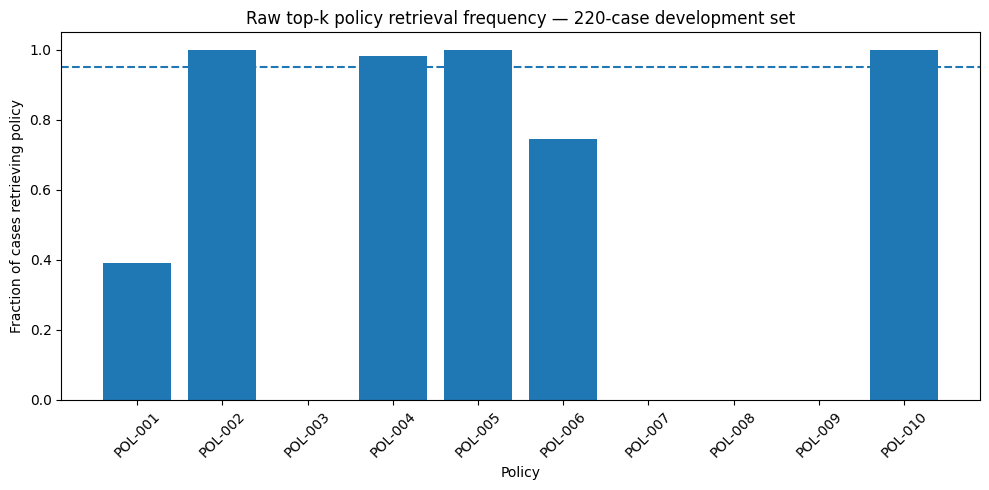

In [179]:
plot_df = raw_frequency.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["policy"], plot_df["rate"])
plt.axhline(0.95, linestyle="--")
plt.ylabel("Fraction of cases retrieving policy")
plt.xlabel("Policy")
plt.title("Raw top-k policy retrieval frequency — 220-case development set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Inspect problematic cases

In [180]:
# Cases with very high irrelevant-context burden.
high_noise = audit_df.sort_values(
    "irrelevant_chunk_fraction_raw",
    ascending=False,
).head(20)

display(
    high_noise[
        [
            "trade_id",
            "scenario_name",
            "case_type",
            "primary_policy",
            "relevant_policies",
            "raw_policy_ids_in_rank_order",
            "accepted_policy_ids_in_rank_order",
            "irrelevant_chunk_fraction_raw",
            "duplicate_policy_chunk_count",
        ]
    ]
)

,trade_id,scenario_name,case_type,primary_policy,relevant_policies,raw_policy_ids_in_rank_order,accepted_policy_ids_in_rank_order,irrelevant_chunk_fraction_raw,duplicate_policy_chunk_count
7,TRADE-7dd756ea,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
20,TRADE-4c2a6d1b,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
14,TRADE-b8381d24,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
13,TRADE-c8381fff,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
67,TRADE-045d17c9,High Risk Advisor,Aligned Recommendation,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
47,TRADE-1716f6f6,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-002-KYC, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS]",1.0,5
59,TRADE-05450f0c,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS]",1.0,4
55,TRADE-d4c2ace3,High Risk Advisor,Aligned Recommendation,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-001-SUITABILITY, POL-005-SENIOR-VULNERABLE-CLIENTS]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-001-SUITABILITY]",1.0,4
36,TRADE-42b2d34c,Aggressive Horizon,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILL

In [181]:
# Beginner + Options cases.
beginner_options_ids = set(
    df.loc[
        (df["investment_experience"] == "Beginner")
        & (df["investment_type"] == "Options"),
        "trade_id",
    ]
)

beginner_options_audit = audit_df[
    audit_df["trade_id"].isin(beginner_options_ids)
]

display(
    beginner_options_audit[
        [
            "trade_id",
            "scenario_name",
            "primary_policy",
            "relevant_policies",
            "raw_policy_ids_in_rank_order",
            "accepted_policy_ids_in_rank_order",
            "primary_policy_raw_rank",
            "primary_policy_retrieved_raw",
            "irrelevant_chunk_fraction_raw",
        ]
    ]
)

,trade_id,scenario_name,primary_policy,relevant_policies,raw_policy_ids_in_rank_order,accepted_policy_ids_in_rank_order,primary_policy_raw_rank,primary_policy_retrieved_raw,irrelevant_chunk_fraction_raw
6,TRADE-246460d1,Compound Violation,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]",1.0,True,0.2
18,TRADE-a480c028,Insufficient Experience,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-001-SUITABILITY]",10.0,True,0.3
30,TRADE-022477d3,Compound Violation,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY, POL-004-CONCENTRATION]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]",1.0,True,0.2
32,TRADE-1f692440,Compound Violation,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY, POL-004-CONCENTRATION]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]",1.0,True,0.2
42,TRADE-dbe6ae38,Retiree Options,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY, POL-004-CONCENTRATION]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]",9.0,True,0.3
45,TRADE-c533fde1,Compound Violation,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY]","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-001-SUITABILITY]",2.0,True,0.0
46,TRADE-bac1d3e5,Insufficient Experience,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-006-HIGH-RISK-PRODUCTS]","[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-001-SUITABILITY

In [182]:
# Primary-policy misses.
primary_misses = audit_df[
    ~audit_df["primary_policy_retrieved_raw"]
].copy()

display(
    primary_misses[
        [
            "trade_id",
            "scenario_name",
            "case_type",
            "primary_policy",
            "relevant_policies",
            "raw_policy_ids_in_rank_order",
            "raw_distances_in_rank_order",
        ]
    ].head(30)
)

print("Primary-policy misses:", len(primary_misses))

,trade_id,scenario_name,case_type,primary_policy,relevant_policies,raw_policy_ids_in_rank_order,raw_distances_in_rank_order
1,TRADE-7d2159b2,Suitability Violation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE]","[POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE]","[0.3643, 0.3742, 0.3858, 0.3936, 0.3969, 0.4038, 0.4086, 0.4227, 0.4259, 0.4289]"
2,TRADE-eb48cfaa,Suitability Violation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE]","[POL-004-CONCENTRATION, POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[0.3827, 0.3957, 0.3963, 0.3985, 0.4012, 0.4035, 0.4036, 0.4405, 0.4456, 0.4462]"
4,TRADE-d7664eb0,Retiree Speculation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]","[POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-002-KYC, POL-002-KYC, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE]","[0.3956, 0.4057, 0.4057, 0.4058, 0.4122, 0.414, 0.4188, 0.4469, 0.4579, 0.4587]"
5,TRADE-cbb34cb9,Aggressive Horizon,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-004-CONCENTRATION, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE]","[0.4005, 0.404, 0.4045, 0.41, 0.415, 0.4214, 0.4242, 0.4425, 0.4532, 0.457]"
7,TRADE-7dd756ea,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]","[0.4433, 0.4442, 0.4449, 0.4458, 0.451, 0.4684, 0.4746, 0.4804, 0.4833, 0.4851]"
13,TRADE-c8381fff,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]","[0.4488, 0.4492, 0.4494, 0.4526, 0.4559, 0.4693, 0.4761, 0.4816, 0.4887, 0.4931]"
14,TRADE-b8381d24,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]","[0.4399, 0.4486, 0.4525, 0.4543, 0.4546, 0.4709, 0.4712, 0.4797, 0.4809, 0.4924]"
16,TRADE-e6777ea7,Suitability Violation,Suitability Violation,POL-001-SUITABILITY,"[POL-001-SUITABILITY, POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE]","[POL-002-KYC, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE]","[0.3905, 0.3913, 0.4075, 0.409, 0.4101, 0.4122, 0.4261, 0.4432, 0.4551, 0.4555]"
20,TRADE-4c2a6d1b,Aligned Recommendation,Aligned Recommendation,nan,[],"[POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-O

Primary-policy misses: 83


# 12. Offline Retrieval Configuration Experiments

## 12.1 Query-builder variants

In [183]:
def build_baseline_query(trade: Trade) -> str:
    return f"""
    Client age: {trade.client_age}
    Client income: {trade.client_income}

    Risk tolerance: {trade.risk_tolerance}
    Investment experience: {trade.investment_experience}
    Investment objective: {trade.investment_objective}
    Investment horizon: {trade.investment_time_horizon}

    Investment product: {trade.investment_type}
    Investment amount: {trade.investment_amount}
    Investment amount as percentage of income: X%
    Potential concentration or overexposure if amount is large relative to income.

    Advisor history risk: {trade.advisor_history_risk}

    KYC status: {trade.kyc_completeness}
    """.strip()

In [184]:
def build_neutral_query(trade: Trade) -> str:
    amount_income_ratio = (trade.investment_amount / trade.client_income * 100)

    return f"""
    Client age: {trade.client_age}
    Client annual income: {trade.client_income}

    Risk tolerance: {trade.risk_tolerance}
    Investment experience: {trade.investment_experience}
    Investment objective: {trade.investment_objective}
    Investment horizon: {trade.investment_time_horizon}

    Investment product: {trade.investment_type}
    Investment amount: {trade.investment_amount}
    Investment amount relative to annual income: {amount_income_ratio:.1f}%

    Advisor history risk: {trade.advisor_history_risk}
    KYC completeness: {trade.kyc_completeness}
    """.strip()

In [185]:
def build_conditional_query(trade: Trade) -> str:
    amount_income_ratio = (trade.investment_amount / trade.client_income * 100)

    lines = [
        f"Client age: {trade.client_age}",
        f"Client annual income: {trade.client_income}",
        f"Risk tolerance: {trade.risk_tolerance}",
        (
            "Investment experience: "
            f"{trade.investment_experience}"
        ),
        (
            "Investment objective: "
            f"{trade.investment_objective}"
        ),
        (
            "Investment horizon: "
            f"{trade.investment_time_horizon}"
        ),
        (
            "Investment product: "
            f"{trade.investment_type}"
        ),
        (
            "Investment amount: "
            f"{trade.investment_amount}"
        ),
        (
            "Investment amount relative to annual income: "
            f"{amount_income_ratio:.1f}%"
        ),
        (
            "Advisor history risk: "
            f"{trade.advisor_history_risk}"
        ),
        (
            "KYC completeness: "
            f"{trade.kyc_completeness}"
        ),
    ]

    # Add factual descriptors only where applicable.

    if trade.kyc_completeness == "Missing":
        lines.append(
            "Required KYC information is missing."
        )

    elif trade.kyc_completeness == "Uncertain":
        lines.append(
            "The completeness or reliability of KYC "
            "information is uncertain."
        )

    if trade.investment_type == "Options":
        lines.append(
            "The proposed investment is an options product "
            "with derivative product complexity."
        )

    if trade.client_age >= 65:
        lines.append(
            "The client is age 65 or older."
        )

    if amount_income_ratio > 30:
        lines.append(
            "The transaction amount exceeds 30% of annual income."
        )

    if not trade.advisor_rationale:
        lines.append(
            "No advisor rationale was provided."
        )

    if trade.advisor_history_risk == "High":
        lines.append(
            "The advisor has a high historical risk classification."
        )

    return "\n".join(lines)

## 12.1a Policy boost rules

In [186]:
from collections import defaultdict
from typing import Any


POLICY_IDS = {
    "suitability": "POL-001-SUITABILITY",
    "kyc": "POL-002-KYC",
    "surveillance": "POL-003-SURVEILLANCE",
    "concentration": "POL-004-CONCENTRATION",
    "senior": "POL-005-SENIOR-VULNERABLE-CLIENTS",
    "high_risk_products": "POL-006-HIGH-RISK-PRODUCTS",
    "documentation": "POL-007-DOCUMENTATION-STANDARDS",
    "exceptions": "POL-008-EXCEPTIONS-AND-OVERRIDES",
    "conflicts": "POL-009-CONFLICTS-OF-INTEREST",
    "objective": "POL-010-CLIENT-OBJECTIVE",
}


def calculate_policy_boosts(trade: Trade) -> dict[str, float]:
    """
    Return policy-level reranking boosts based only on runtime facts.

    Larger values mean stronger policy relevance.
    These are deliberately small and interpretable.
    """
    boosts: dict[str, float] = defaultdict(float)

    amount_income_ratio = (
        trade.investment_amount / trade.client_income
        if trade.client_income
        else 0.0
    )

    # KYC facts
    if trade.kyc_completeness == "Missing":
        boosts[POLICY_IDS["kyc"]] += 0.18
        boosts[POLICY_IDS["surveillance"]] += 0.08
        boosts[POLICY_IDS["suitability"]] += 0.05

    elif trade.kyc_completeness == "Uncertain":
        boosts[POLICY_IDS["kyc"]] += 0.12
        boosts[POLICY_IDS["surveillance"]] += 0.05

    # Product complexity
    if trade.investment_type == "Options":
        boosts[POLICY_IDS["high_risk_products"]] += 0.18
        boosts[POLICY_IDS["suitability"]] += 0.12

    # Senior/vulnerable review context
    if trade.client_age >= 65:
        boosts[POLICY_IDS["senior"]] += 0.12

        if trade.investment_type in {"Stocks", "Options"}:
            boosts[POLICY_IDS["senior"]] += 0.06
            boosts[POLICY_IDS["surveillance"]] += 0.04

    # Exposure/concentration proxy
    if amount_income_ratio > 0.30:
        boosts[POLICY_IDS["concentration"]] += 0.16
        boosts[POLICY_IDS["suitability"]] += 0.05

    # Documentation
    if not trade.advisor_rationale or not str(
        trade.advisor_rationale
    ).strip():
        boosts[POLICY_IDS["documentation"]] += 0.18
        boosts[POLICY_IDS["surveillance"]] += 0.07

    # Advisor conduct history
    if trade.advisor_history_risk == "High":
        boosts[POLICY_IDS["surveillance"]] += 0.18
    elif trade.advisor_history_risk == "Medium":
        boosts[POLICY_IDS["surveillance"]] += 0.05

    # Objective/product relationship
    if (
        trade.investment_objective == "Preservation"
        and trade.investment_type in {"Stocks", "Options"}
    ):
        boosts[POLICY_IDS["objective"]] += 0.14
        boosts[POLICY_IDS["suitability"]] += 0.12

    # Horizon/product relationship
    if (
        trade.investment_time_horizon == "Short"
        and trade.investment_type in {"Stocks", "Options"}
    ):
        boosts[POLICY_IDS["suitability"]] += 0.12

    # Experience/product relationship
    if (
        trade.investment_experience == "Beginner"
        and trade.investment_type == "Options"
    ):
        boosts[POLICY_IDS["high_risk_products"]] += 0.10
        boosts[POLICY_IDS["suitability"]] += 0.10

    return dict(boosts)

## 12.1b Targeted candidate chunk inclusion

In [187]:
POLICY_3_ID = "POL-003-SURVEILLANCE"


def include_targeted_policy_candidates(
    trade: Trade,
    query: str,
    candidate_chunks: list[dict[str, Any]],
    retriever: ComplianceRetriever,
) -> list[dict[str, Any]]:
    """
    Ensure that a Policy 3 candidate is available when advisor-history
    risk indicates surveillance relevance.

    The added candidate is not guaranteed to enter the final context.
    It still competes through the normal policy-aware reranker.
    """
    advisor_history_risk = str(
        trade.advisor_history_risk or ""
    ).strip().lower()

    should_include_policy_3 = (
        advisor_history_risk
        in {
            "high",
            "medium",
        }
    )

    if not should_include_policy_3:
        return candidate_chunks

    # Avoid adding a duplicate when Policy 3 was already retrieved.
    policy_3_already_present = any(
        chunk.get("policy_id") == POLICY_3_ID
        for chunk in candidate_chunks
    )

    if policy_3_already_present:
        return candidate_chunks

    policy_3_candidate = (
        retriever.retrieve_best_chunk_for_policy(
            query=query,
            policy_id=POLICY_3_ID,
        )
    )

    if policy_3_candidate is None:
        return candidate_chunks

    return [
        *candidate_chunks,
        policy_3_candidate,
    ]

## 12.1c Reranker

In [188]:
def rerank_chunks_with_policy_boosts(
    trade: Trade,
    chunks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    policy_boosts = calculate_policy_boosts(
        trade
    )

    reranked = []

    for candidate_order, chunk in enumerate(
        chunks,
        start=1,
    ):
        original_rank = chunk.get(
            "original_rank"
        )

        policy_id = str(
            chunk["policy_id"]
        )

        original_distance = float(
            chunk["similarity_distance"]
        )

        boost = float(
            policy_boosts.get(
                policy_id,
                0.0,
            )
        )

        adjusted_distance = (
            original_distance - boost
        )

        reranked.append(
            {
                **chunk,
                "candidate_order":
                    candidate_order,
                "original_rank":
                    original_rank,
                "original_distance":
                    original_distance,
                "policy_boost":
                    boost,
                "adjusted_distance":
                    adjusted_distance,
            }
        )

    return sorted(
        reranked,
        key=lambda item: (
            item["adjusted_distance"],
            item["candidate_order"],
        ),
    )

## 12.2 Context-selection strategies

In [189]:
def select_raw_top_k(
    chunks: list[dict],
    limit: int = 10,
) -> list[dict]:
    return chunks[:limit]


def select_first_per_policy(
    chunks: list[dict],
    total_limit: int | None = None,
    max_distance: float | None = None,
) -> list[dict]:
    selected = []
    seen_policies = set()

    for chunk in chunks:
        if (
            max_distance is not None
            and chunk["similarity_distance"] > max_distance
        ):
            continue

        policy_id = chunk["policy_id"]

        if policy_id in seen_policies:
            continue

        selected.append(chunk)
        seen_policies.add(policy_id)

        if (
            total_limit is not None
            and len(selected) >= total_limit
        ):
            break

    return selected


# def select_max_chunks_per_policy(
#     chunks: list[dict],
#     max_per_policy: int = 2,
#     total_limit: int | None = None,
#     max_distance: float | None = None,
# ) -> list[dict]:
#     selected = []
#     policy_counts = {}

#     for chunk in chunks:
#         if (
#             max_distance is not None
#             and chunk["similarity_distance"] > max_distance
#         ):
#             continue

#         policy_id = chunk["policy_id"]

#         current_count = policy_counts.get(
#             policy_id,
#             0,
#         )

#         if current_count >= max_per_policy:
#             continue

#         selected.append(chunk)
#         policy_counts[policy_id] = current_count + 1

#         if (
#             total_limit is not None
#             and len(selected) >= total_limit
#         ):
#             break

#     return selected

## 12.3a Setup experiment matrix

In [190]:
QUERY_BUILDERS = {
    "baseline": build_baseline_query,
    "neutral": build_neutral_query,
    "conditional": build_conditional_query,
}


def raw_10(chunks):
    return select_raw_top_k(
        chunks,
        limit=10,
    )


def first_per_policy_4(chunks):
    return select_first_per_policy(
        chunks,
        total_limit=4,
    )


def first_per_policy_5(chunks):
    return select_first_per_policy(
        chunks,
        total_limit=5,
    )


def first_per_policy_6(chunks):
    return select_first_per_policy(
        chunks,
        total_limit=6,
    )

def reranked_first_per_policy_4(
    trade: Trade,
    chunks: list[dict],
) -> list[dict]:
    reranked = rerank_chunks_with_policy_boosts(
        trade,
        chunks,
    )
    return select_first_per_policy(
        reranked,
        total_limit=4,
    )


def reranked_first_per_policy_5(
    trade: Trade,
    chunks: list[dict],
) -> list[dict]:
    reranked = rerank_chunks_with_policy_boosts(
        trade,
        chunks,
    )
    return select_first_per_policy(
        reranked,
        total_limit=5,
    )


def reranked_first_per_policy_6(
    trade: Trade,
    chunks: list[dict],
) -> list[dict]:
    reranked = rerank_chunks_with_policy_boosts(
        trade,
        chunks,
    )
    return select_first_per_policy(
        reranked,
        total_limit=6,
    )

# def max_two_per_policy_4(chunks):
#     return select_max_chunks_per_policy(
#         chunks,
#         max_per_policy=2,
#         total_limit=4,
#     )


# def max_two_per_policy_5(chunks):
#     return select_max_chunks_per_policy(
#         chunks,
#         max_per_policy=2,
#         total_limit=5,
#     )


# def max_two_per_policy_6(chunks):
#     return select_max_chunks_per_policy(
#         chunks,
#         max_per_policy=2,
#         total_limit=6,
#     )


STANDARD_SELECTION_STRATEGIES = {
    "raw_top_10": raw_10,
    "first_per_policy_4": first_per_policy_4,
    "first_per_policy_5": first_per_policy_5,
    "first_per_policy_6": first_per_policy_6,
    # "max_two_per_policy_4": max_two_per_policy_4,
    # "max_two_per_policy_5": max_two_per_policy_5,
    # "max_two_per_policy_6": max_two_per_policy_6,
}

RERANKED_SELECTION_STRATEGIES = {
    "reranked_first_per_policy_4":
        reranked_first_per_policy_4,

    "reranked_first_per_policy_5":
        reranked_first_per_policy_5,

    "reranked_first_per_policy_6":
        reranked_first_per_policy_6,
}

## 12.3b Run experiments

In [191]:
experiment_rows = []

trade_fields = set(Trade.model_fields.keys())

for query_name, query_builder in QUERY_BUILDERS.items():

    print("Running query variant:", query_name)

    for _, row in df.iterrows():
        row_dict = row.to_dict()

        trade_payload = {
            key: (None if pd.isna(value) else value)
            for key, value in row_dict.items()
            if key in trade_fields
        }

        trade = Trade(**trade_payload)

        query = query_builder(trade)

        raw_chunks = retriever.retrieve_policy_evidence(
            query,
            top_k=20,
        )

        raw_rank_by_chunk_id = {
            chunk["chunk_id"]: rank
            for rank, chunk in enumerate(
                raw_chunks,
                start=1,
            )
        }

        # Add the true global semantic rank to the original
        # top-20 candidates.
        raw_chunks = [
            {
                **chunk,
                "original_rank":
                    raw_rank_by_chunk_id[chunk["chunk_id"]],
            }
            for chunk in raw_chunks
        ]

        candidate_chunks = include_targeted_policy_candidates(
            trade=trade,
            query=query,
            candidate_chunks=raw_chunks,
            retriever=retriever,
        )

        relevant_policies = parse_list_value(
            row_dict.get("relevant_policies")
        )

        primary_policy = row_dict.get(
            "primary_policy"
        )

        if (
            primary_policy is not None
            and str(primary_policy).strip()
        ):
            primary_policy = str(primary_policy)
        else:
            primary_policy = None

        relevant_set = set(relevant_policies)

        selection_results = {}

        for strategy_name, selector in (
            STANDARD_SELECTION_STRATEGIES.items()
        ):
            selection_results[strategy_name] = selector(
                raw_chunks
            )

        for strategy_name, selector in (
            RERANKED_SELECTION_STRATEGIES.items()
        ):
            selection_results[strategy_name] = selector(
                trade,
                candidate_chunks,
            )

        for strategy_name, selected_chunks in (
            selection_results.items()
        ):
            selected_policy_ids = [
                chunk["policy_id"]
                for chunk in selected_chunks
            ]

            selected_unique_policy_ids = unique_in_order(
                selected_policy_ids
            )

            precision, recall = precision_recall(
                selected_unique_policy_ids,
                relevant_policies,
            )

            irrelevant_chunks = sum(
                policy_id not in relevant_set
                for policy_id in selected_policy_ids
            )

            irrelevant_fraction = (
                irrelevant_chunks / len(selected_chunks)
                if selected_chunks
                else 0.0
            )

            duplicate_count = (
                len(selected_policy_ids)
                - len(selected_unique_policy_ids)
            )

            experiment_rows.append(
                {
                    "query_variant": query_name,
                    "selection_strategy": strategy_name,
                    "trade_id": trade.trade_id,
                    "scenario_name": row_dict.get(
                        "scenario_name"
                    ),
                    "case_type": row_dict.get(
                        "case_type"
                    ),
                    "relevant_policies": relevant_policies,
                    "primary_policy": primary_policy,
                    "selected_chunk_count":
                        len(selected_chunks),
                    "selected_policy_ids":
                        selected_policy_ids,
                    "selected_unique_policy_ids":
                        selected_unique_policy_ids,

                    "candidate_chunk_count":
                        len(candidate_chunks),

                    "policy_3_in_raw_candidates": any(
                        chunk.get("policy_id") == POLICY_3_ID
                        for chunk in raw_chunks
                    ),

                    "policy_3_targeted_candidate_added": (
                        any(
                            chunk.get("policy_id") == POLICY_3_ID
                            for chunk in candidate_chunks
                        )
                        and not any(
                            chunk.get("policy_id") == POLICY_3_ID
                            for chunk in raw_chunks
                        )
                    ),

                    "policy_3_selected": (
                        POLICY_3_ID
                        in selected_unique_policy_ids
                    ),

                    "targeted_candidate_policy_ids": [
                        chunk["policy_id"]
                        for chunk in candidate_chunks
                        if chunk["chunk_id"]
                        not in {
                            raw_chunk["chunk_id"]
                            for raw_chunk in raw_chunks
                        }
                    ],

                    "selected_chunk_ids": [
                        chunk["chunk_id"]
                        for chunk in selected_chunks
                    ],

                    "selected_original_ranks": [
                        chunk.get("original_rank")
                        for chunk in selected_chunks
                    ],
                    # "selected_original_ranks": [
                    #     chunk.get(
                    #         "original_rank",
                    #         raw_rank_by_chunk_id.get(
                    #             chunk["chunk_id"]
                    #         ),
                    #     )
                    #     for chunk in selected_chunks
                    # ],

                    "selected_original_distances": [
                        chunk.get(
                            "original_distance",
                            chunk["similarity_distance"],
                        )
                        for chunk in selected_chunks
                    ],

                    "selected_policy_boosts": [
                        chunk.get("policy_boost", 0.0)
                        for chunk in selected_chunks
                    ],

                    "selected_adjusted_distances": [
                        chunk.get(
                            "adjusted_distance",
                            chunk["similarity_distance"],
                        )
                        for chunk in selected_chunks
                    ],

                    "precision": precision,
                    "recall": recall,
                    "has_expected_relevant_policy":
                        len(relevant_policies) > 0,
                    "has_expected_primary_policy": (
                        len(relevant_policies) > 0
                        and primary_policy is not None
                        and str(primary_policy).strip() != ""
                    ),
                    "primary_policy_retrieved": (
                        primary_policy
                        in selected_unique_policy_ids
                    )
                    if primary_policy
                    else False,
                    "any_relevant_policy_retrieved":
                        bool(
                            relevant_set
                            & set(selected_unique_policy_ids)
                        ),
                    "irrelevant_chunk_fraction":
                        irrelevant_fraction,
                    "duplicate_policy_chunk_count":
                        duplicate_count,
                    "policy_1_retrieved":
                        (
                            "POL-001-SUITABILITY"
                            in selected_unique_policy_ids
                        ),

                    "policy_3_retrieved":
                        (
                            "POL-003-SURVEILLANCE"
                            in selected_unique_policy_ids
                        ),

                    "policy_6_retrieved":
                        (
                            "POL-006-HIGH-RISK-PRODUCTS"
                            in selected_unique_policy_ids
                        ),

                    "policy_7_retrieved":
                        (
                            "POL-007-DOCUMENTATION-STANDARDS"
                            in selected_unique_policy_ids
                        ),
                }
            )

experiments_df = pd.DataFrame(
    experiment_rows
)

experiments_df.to_pickle(
    HISTORY_RETRIEVAL_DETAIL_DIR / "retrieval_experiment_details_220.pkl"
)

diagnostic_list_columns = [
    "relevant_policies",
    "selected_policy_ids",
    "selected_unique_policy_ids",
    "selected_chunk_ids",
    "selected_original_ranks",
    "selected_original_distances",
    "selected_policy_boosts",
    "selected_adjusted_distances",
]

experiments_export_df = experiments_df.copy()

for column in diagnostic_list_columns:
    experiments_export_df[column] = (
        experiments_export_df[column].apply(
            json.dumps
        )
    )

experiments_export_df.to_csv(
    HISTORY_RETRIEVAL_DETAIL_DIR / "retrieval_experiment_details_220.csv",
    index=False,
)

print(
    "Experiment rows:",
    len(experiments_df),
)

Running query variant: baseline
Running query variant: neutral
Running query variant: conditional
Experiment rows: 4620


## 12.4 Aggregate configuration comparison

In [192]:
configuration_rows = []

for (
    query_variant,
    selection_strategy,
), group in experiments_df.groupby(
    [
        "query_variant",
        "selection_strategy",
    ]
):

    recall_cases = group[
        group["has_expected_relevant_policy"]
    ]

    primary_cases = group[
        group["has_expected_primary_policy"]
    ]

    configuration_rows.append(
        {
            "query_variant":
                query_variant,

            "selection_strategy":
                selection_strategy,

            "mean_precision":
                group["precision"].mean(),

            "mean_recall":
                recall_cases["recall"].mean(),

            "primary_policy_recall":
                primary_cases[
                    "primary_policy_retrieved"
                ].mean(),

            "any_relevant_policy_recall":
                recall_cases[
                    "any_relevant_policy_retrieved"
                ].mean(),

            "mean_selected_chunks":
                group[
                    "selected_chunk_count"
                ].mean(),

            "mean_irrelevant_chunk_fraction":
                group[
                    "irrelevant_chunk_fraction"
                ].mean(),

            "cases_with_duplicate_chunks_rate":
                (
                    group[
                        "duplicate_policy_chunk_count"
                    ] > 0
                ).mean(),
        }
    )

configuration_summary_df = (
    pd.DataFrame(configuration_rows)
    .sort_values(
        [
            "primary_policy_recall",
            "mean_recall",
            "mean_irrelevant_chunk_fraction",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
)

display(configuration_summary_df)

configuration_summary_df.to_csv(
    RETRIEVAL_ARTIFACTS_DIR / "retrieval_configuration_comparison_220.csv",
    index=False,
)

,query_variant,selection_strategy,mean_precision,mean_recall,primary_policy_recall,any_relevant_policy_recall,mean_selected_chunks,mean_irrelevant_chunk_fraction,cases_with_duplicate_chunks_rate
13,conditional,reranked_first_per_policy_6,0.401515,0.878266,1.000000,1.000000,6.0,0.598485,0.0
12,conditional,reranked_first_per_policy_5,0.460909,0.857473,1.000000,1.000000,5.0,0.539091,0.0
20,neutral,reranked_first_per_policy_6,0.388636,0.853993,1.000000,1.000000,6.0,0.611364,0.0
6,baseline,reranked_first_per_policy_6,0.386364,0.850147,1.000000,1.000000,6.0,0.613636,0.0
19,neutral,reranked_first_per_policy_5,0.445455,0.829951,1.000000,1.000000,5.0,0.554545,0.0
5,baseline,reranked_first_per_policy_5,0.446364,0.832686,0.989744,1.000000,5.0,0.553636,0.0
11,conditional,reranked_first_per_policy_4,0.529545,0.812063,0.979487,1.000000,4.0,0.470455,0.0
18,neutral,reranked_first_per_policy_4,0.518182,0.794542,0.969231,1.000000,4.0,0.481818,0.0
4,baseline,reranked_first_per_policy_4,0.515909,0.791551,0.953846,1.000000,4.0,0.484091,0.0
2,baseline,first_per_policy_6,0.337121,0.710659,0.938462,0.938462,6.0,0.662879,0.0


## 12.5 Policy-specific recall

In [193]:
TARGET_POLICIES = [
    "POL-001-SUITABILITY",
    "POL-003-SURVEILLANCE",
    "POL-006-HIGH-RISK-PRODUCTS",
    "POL-007-DOCUMENTATION-STANDARDS",
]


def policy_specific_recall(
    group: pd.DataFrame,
    policy_id: str,
) -> float:
    relevant = group[
        group["relevant_policies"].apply(
            lambda policies:
                policy_id in policies
        )
    ]

    if relevant.empty:
        return np.nan

    return relevant[
        "selected_unique_policy_ids"
    ].apply(
        lambda retrieved:
            policy_id in retrieved
    ).mean()


policy_recall_rows = []

for (
    query_variant,
    selection_strategy,
), group in experiments_df.groupby(
    [
        "query_variant",
        "selection_strategy",
    ]
):
    row = {
        "query_variant": query_variant,
        "selection_strategy":
            selection_strategy,
    }

    for policy_id in TARGET_POLICIES:
        short_id = policy_id.split("-")[1]

        row[
            f"recall_POL_{short_id}"
        ] = policy_specific_recall(
            group,
            policy_id,
        )

    policy_recall_rows.append(row)

policy_recall_df = pd.DataFrame(
    policy_recall_rows
)

display(policy_recall_df)

policy_recall_df.to_csv(
    RETRIEVAL_ARTIFACTS_DIR / "retrieval_policy_specific_comparison_220.csv", index=False,
)

,query_variant,selection_strategy,recall_POL_001,recall_POL_003,recall_POL_006,recall_POL_007
0,baseline,first_per_policy_4,0.123967,0.000000,0.228571,0.00
1,baseline,first_per_policy_5,0.355372,0.000000,0.285714,0.00
2,baseline,first_per_policy_6,1.000000,0.000000,1.000000,0.00
3,baseline,raw_top_10,0.413223,0.000000,0.342857,0.00
4,baseline,reranked_first_per_policy_4,0.925620,0.224490,1.000000,0.55
5,baseline,reranked_first_per_policy_5,1.000000,0.272109,1.000000,0.55
6,baseline,reranked_first_per_policy_6,1.000000,0.380952,1.000000,0.55
7,conditional,first_per_policy_4,0.148760,0.000000,1.000000,0.00
8,conditional,first_per_policy_5,0.528926,0.000000,1.000000,0.10
9,conditional,first_per_policy_6,0.958678,0.000000,1.000000,0.10


## 12.6 Scenario-specific comparison

In [194]:
scenario_comparison_rows = []

for (
    query_variant,
    selection_strategy,
    scenario_name,
), group in experiments_df.groupby(
    [
        "query_variant",
        "selection_strategy",
        "scenario_name",
    ],
    dropna=False,
):

    recall_cases = group[
        group["has_expected_relevant_policy"]
    ]

    primary_cases = group[
        group["has_expected_primary_policy"]
    ]

    scenario_comparison_rows.append(
        {
            "query_variant": query_variant,
            "selection_strategy": selection_strategy,
            "scenario_name": scenario_name,

            "cases": len(group),

            "cases_with_expected_policies":
                len(recall_cases),

            "cases_with_expected_primary_policy":
                len(primary_cases),

            "mean_precision":
                group["precision"].mean(),

            "mean_recall":
                (
                    recall_cases["recall"].mean()
                    if not recall_cases.empty
                    else np.nan
                ),

            "primary_policy_recall":
                (
                    primary_cases[
                        "primary_policy_retrieved"
                    ].mean()
                    if not primary_cases.empty
                    else np.nan
                ),

            "any_relevant_policy_recall":
                (
                    recall_cases[
                        "any_relevant_policy_retrieved"
                    ].mean()
                    if not recall_cases.empty
                    else np.nan
                ),

            "mean_selected_chunks":
                group["selected_chunk_count"].mean(),

            "mean_irrelevant_chunk_fraction":
                group[
                    "irrelevant_chunk_fraction"
                ].mean(),

            "cases_with_duplicate_chunks_rate":
                (
                    group[
                        "duplicate_policy_chunk_count"
                    ] > 0
                ).mean(),
        }
    )


scenario_comparison_df = pd.DataFrame(
    scenario_comparison_rows
).sort_values(
    [
        "scenario_name",
        "primary_policy_recall",
        "mean_recall",
        "mean_irrelevant_chunk_fraction",
    ],
    ascending=[
        True,
        False,
        False,
        True,
    ],
)

display(scenario_comparison_df)

scenario_comparison_df.to_csv(
    RETRIEVAL_ARTIFACTS_DIR / "retrieval_scenario_specific_comparison_220.csv",
    index=False,
)

,query_variant,selection_strategy,scenario_name,cases,cases_with_expected_policies,cases_with_expected_primary_policy,mean_precision,mean_recall,primary_policy_recall,any_relevant_policy_recall,mean_selected_chunks,mean_irrelevant_chunk_fraction,cases_with_duplicate_chunks_rate
56,baseline,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
154,conditional,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
252,neutral,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
70,baseline,reranked_first_per_policy_5,Aggressive Horizon,10,10,10,0.380000,0.775000,1.00,1.0,5.0,0.6200,0.0
168,conditional,reranked_first_per_policy_5,Aggressive Horizon,10,10,10,0.380000,0.775000,1.00,1.0,5.0,0.6200,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,baseline,raw_top_10,Suitability Violation,20,20,20,0.306667,0.434167,0.25,1.0,10.0,0.5250,1.0
13,baseline,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0
111,conditional,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0
209,neutral,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0


## 12.7 Convenience pivots and summary views

In [195]:
scenario_primary_recall_pivot = (
    scenario_comparison_df.pivot_table(
        index=[
            "query_variant",
            "selection_strategy",
        ],
        columns="scenario_name",
        values="primary_policy_recall",
    )
)

display(scenario_primary_recall_pivot)

scenario_primary_recall_pivot.to_csv(
    RETRIEVAL_ARTIFACTS_DIR / "retrieval_primary_recall_by_scenario_220.csv"
)

scenario_name                              Aggressive Horizon  \
query_variant selection_strategy                                
baseline      first_per_policy_4                          0.0   
              first_per_policy_5                          0.0   
              first_per_policy_6                          1.0   
              raw_top_10                                  0.0   
              reranked_first_per_policy_4                 1.0   
              reranked_first_per_policy_5                 1.0   
              reranked_first_per_policy_6                 1.0   
conditional   first_per_policy_4                          0.0   
              first_per_policy_5                          0.2   
              first_per_policy_6                          1.0   
              raw_top_10                                  0.2   
              reranked_first_per_policy_4                 1.0   
              reranked_first_per_policy_5                 1.0   
              reranked_first_per_policy_6                 1.0   
neutral       first_per_policy_4                          0.0   
              first_per_policy_5                          0.2   
              first_per_policy_6                          1.0   
              raw_top_10                                  0.2   
              reranked_first_per_policy_4                 1.0   
              reranked_first_per_policy_5                 1.0   
              reranked_first_per_policy_6                 1.0   

scenario_name                              Aggressive Objective  \
query_variant selection_strategy                                  
baseline      first_per_policy_4                            0.0   
              first_per_policy_5                            0.2   
              first_per_policy_6                            1.0   
              raw_top_10                                    0.5   
              reranked_first_per_policy_4                   1.0   
              reranked_first_per_policy_5                   1.0   
              reranked_first_per_policy_6                   1.0   
conditional   first_per_policy_4                            0.1   
              first_per_policy_5                            0.6   
              first_per_policy_6                            1.0   
              raw_top_10                                    0.7   
              reranked_first_per_policy_4                   1.0   
              reranked_first_per_policy_5                   1.0   
              reranked_first_per_policy_6                   1.0   
neutral       first_per_policy_4                            0.1   
              first_per_policy_5                            0.7   
              first_per_policy_6                            1.0   
              raw_top_10                                    0.7   
              reranked_first_per_policy_4                   1.0   
              reranked_first_per_policy_5                   1.0   
              reranked_first_per_policy_6                   1.0   

scenario_name                              Aligned Recommendation  \
query_variant selection_strategy                                    
baseline      first_per_policy_4                             0.64   
              first_per_policy_5                             0.64   
              first_per_policy_6                             0.80   
              raw_top_10                                     0.64   
              reranked_first_per_policy_4                    1.00   
              reranked_first_per_policy_5                    1.00   
              reranked_first_per_policy_6                    1.00   
conditional   first_per_policy_4                             0.64   
              first_per_policy_5                             0.68   
              first_per_policy_6                             0.80   
              raw_top_10                                     0.76   
              reranked_first_per_policy_4                    1.00

In [196]:
scenario_noise_pivot = (
    scenario_comparison_df.pivot_table(
        index=[
            "query_variant",
            "selection_strategy",
        ],
        columns="scenario_name",
        values="mean_irrelevant_chunk_fraction",
    )
)

display(scenario_noise_pivot)

scenario_noise_pivot.to_csv(
    RETRIEVAL_ARTIFACTS_DIR / "retrieval_noise_by_scenario_220.csv"
)

scenario_name                              Aggressive Horizon  \
query_variant selection_strategy                                
baseline      first_per_policy_4                     0.800000   
              first_per_policy_5                     0.840000   
              first_per_policy_6                     0.700000   
              raw_top_10                             0.760000   
              reranked_first_per_policy_4            0.525000   
              reranked_first_per_policy_5            0.620000   
              reranked_first_per_policy_6            0.683333   
conditional   first_per_policy_4                     0.800000   
              first_per_policy_5                     0.800000   
              first_per_policy_6                     0.700000   
              raw_top_10                             0.740000   
              reranked_first_per_policy_4            0.525000   
              reranked_first_per_policy_5            0.620000   
              reranked_first_per_policy_6            0.683333   
neutral       first_per_policy_4                     0.800000   
              first_per_policy_5                     0.800000   
              first_per_policy_6                     0.700000   
              raw_top_10                             0.740000   
              reranked_first_per_policy_4            0.525000   
              reranked_first_per_policy_5            0.620000   
              reranked_first_per_policy_6            0.683333   

scenario_name                              Aggressive Objective  \
query_variant selection_strategy                                  
baseline      first_per_policy_4                       0.725000   
              first_per_policy_5                       0.740000   
              first_per_policy_6                       0.650000   
              raw_top_10                               0.570000   
              reranked_first_per_policy_4              0.450000   
              reranked_first_per_policy_5              0.560000   
              reranked_first_per_policy_6              0.633333   
conditional   first_per_policy_4                       0.700000   
              first_per_policy_5                       0.660000   
              first_per_policy_6                       0.650000   
              raw_top_10                               0.530000   
              reranked_first_per_policy_4              0.450000   
              reranked_first_per_policy_5              0.560000   
              reranked_first_per_policy_6              0.633333   
neutral       first_per_policy_4                       0.700000   
              first_per_policy_5                       0.640000   
              first_per_policy_6                       0.650000   
              raw_top_10                               0.520000   
              reranked_first_per_policy_4              0.450000   
              reranked_first_per_policy_5              0.560000   
              reranked_first_per_policy_6              0.633333   

scenario_name                              Aligned Recommendation  \
query_variant selection_strategy                                    
baseline      first_per_policy_4                         0.910000   
              first_per_policy_5                         0.928000   
              first_per_policy_6                         0.926667   
              raw_top_10                                 0.930000   
              reranked_first_per_policy_4                0.865000   
              reranked_first_per_policy_5                0.892000   
              reranked_first_per_policy_6                0.910000   
conditional   first_per_policy_4                         0.920000   
              first_per_policy_5                         0.924000   
              first_per_policy_6                         0.926667   
              raw_top_10                                 0.872000   
              reranked_first_per_policy_4                0.865000

In [197]:
FOCUS_SCENARIOS = [
    "Aligned Recommendation",
    "Suitability Violation",
    "Insufficient Experience",
    "Aggressive Horizon",
    "Aggressive Objective",
    "High Risk Advisor",
    "KYC Missing",
]

focused_scenario_comparison = (
    scenario_comparison_df[
        scenario_comparison_df[
            "scenario_name"
        ].isin(FOCUS_SCENARIOS)
    ]
    .sort_values(
        [
            "scenario_name",
            "primary_policy_recall",
            "mean_irrelevant_chunk_fraction",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
)

display(focused_scenario_comparison)

,query_variant,selection_strategy,scenario_name,cases,cases_with_expected_policies,cases_with_expected_primary_policy,mean_precision,mean_recall,primary_policy_recall,any_relevant_policy_recall,mean_selected_chunks,mean_irrelevant_chunk_fraction,cases_with_duplicate_chunks_rate
56,baseline,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
154,conditional,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
252,neutral,reranked_first_per_policy_4,Aggressive Horizon,10,10,10,0.475000,0.775000,1.00,1.0,4.0,0.5250,0.0
70,baseline,reranked_first_per_policy_5,Aggressive Horizon,10,10,10,0.380000,0.775000,1.00,1.0,5.0,0.6200,0.0
168,conditional,reranked_first_per_policy_5,Aggressive Horizon,10,10,10,0.380000,0.775000,1.00,1.0,5.0,0.6200,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,baseline,raw_top_10,Suitability Violation,20,20,20,0.306667,0.434167,0.25,1.0,10.0,0.5250,1.0
13,baseline,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0
111,conditional,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0
209,neutral,first_per_policy_4,Suitability Violation,20,20,20,0.362500,0.405000,0.15,1.0,4.0,0.6375,0.0


# 13. Generate sentinel evaluation set

## 13.1 Load and filter experiment details

In [198]:
import ast
import json
import pandas as pd


EXPERIMENT_DETAILS_PATH = (
    HISTORY_RETRIEVAL_DETAIL_DIR / "retrieval_experiment_details_220.csv"
)

details_df = pd.read_csv(
    EXPERIMENT_DETAILS_PATH
)


def parse_json_or_list(value):
    if isinstance(value, list):
        return value

    if value is None or (
        isinstance(value, float)
        and pd.isna(value)
    ):
        return []

    text = str(value).strip()

    if not text:
        return []

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return ast.literal_eval(text)


list_columns = [
    "relevant_policies",
    "selected_policy_ids",
    "selected_unique_policy_ids",
    "selected_chunk_ids",
    "selected_original_ranks",
    "selected_original_distances",
    "selected_policy_boosts",
    "selected_adjusted_distances",
    "targeted_candidate_policy_ids",
]

for column in list_columns:
    if column in details_df.columns:
        details_df[column] = (
            details_df[column].apply(
                parse_json_or_list
            )
        )


target_config_df = details_df[
    (
        details_df["query_variant"]
        == "conditional"
    )
    & (
        details_df["selection_strategy"]
        == "reranked_first_per_policy_5"
    )
].copy()

print(
    "Target configuration rows:",
    len(target_config_df),
)

Target configuration rows: 220


## 13.2 Add sentinel-selection flags

In [199]:
POLICY_3_ID = "POL-003-SURVEILLANCE"


target_config_df[
    "policy_3_ground_truth_relevant"
] = target_config_df[
    "relevant_policies"
].apply(
    lambda policies:
        POLICY_3_ID in policies
)


target_config_df[
    "injected_and_selected"
] = (
    target_config_df[
        "policy_3_targeted_candidate_added"
    ].astype(bool)
    & target_config_df[
        "policy_3_selected"
    ].astype(bool)
)


target_config_df[
    "injected_not_selected"
] = (
    target_config_df[
        "policy_3_targeted_candidate_added"
    ].astype(bool)
    & ~target_config_df[
        "policy_3_selected"
    ].astype(bool)
)


target_config_df[
    "policy_3_relevant_not_injected"
] = (
    target_config_df[
        "policy_3_ground_truth_relevant"
    ]
    & ~target_config_df[
        "policy_3_targeted_candidate_added"
    ].astype(bool)
)


target_config_df[
    "policy_3_negative_control"
] = (
    ~target_config_df[
        "policy_3_ground_truth_relevant"
    ]
)

## 13.3 Merge source trade fields

In [200]:
trade_metadata_columns = [
    column
    for column in df.columns
    if column not in target_config_df.columns
    or column == "trade_id"
]

sentinel_pool_df = target_config_df.merge(
    df[trade_metadata_columns],
    on="trade_id",
    how="left",
    suffixes=("", "_source"),
)

print(
    "Sentinel pool cases:",
    len(sentinel_pool_df),
)

Sentinel pool cases: 220


## 13.4 Deterministic sampling helper

In [201]:
RANDOM_STATE = 42


def sample_up_to(
    dataframe: pd.DataFrame,
    count: int,
) -> pd.DataFrame:
    if len(dataframe) <= count:
        return dataframe.copy()

    return dataframe.sample(
        n=count,
        random_state=RANDOM_STATE,
    )

## 13.5 Select all High Risk Advisor cases

In [202]:
high_risk_advisor_cases = (
    sentinel_pool_df[
        sentinel_pool_df["scenario_name"]
        == "High Risk Advisor"
    ]
    .drop_duplicates("trade_id")
    .copy()
)

print(
    "High Risk Advisor cases:",
    len(high_risk_advisor_cases),
)

High Risk Advisor cases: 10


## 13.6 Select six other injected-and-selected cases

In [203]:
def exclude_trade_ids(
    dataframe: pd.DataFrame,
    selected_ids: set[str],
) -> pd.DataFrame:
    return dataframe[
        ~dataframe["trade_id"].isin(
            selected_ids
        )
    ].copy()

selected_ids = set(
    high_risk_advisor_cases["trade_id"]
)

other_injected_selected_pool = (
    sentinel_pool_df[
        sentinel_pool_df[
            "injected_and_selected"
        ]
        & (
            sentinel_pool_df["scenario_name"]
            != "High Risk Advisor"
        )
    ]
    .drop_duplicates("trade_id")
    .copy()
)

other_injected_selected_pool = (
    exclude_trade_ids(
        other_injected_selected_pool,
        selected_ids,
    )
)

other_injected_selected = (
    other_injected_selected_pool
    .sort_values(
        ["scenario_name", "trade_id"]
    )
    .groupby(
        "scenario_name",
        group_keys=False,
    )
    .head(1)
    .head(6)
)

if len(other_injected_selected) < 6:
    remaining_pool = exclude_trade_ids(
        other_injected_selected_pool,
        set(
            other_injected_selected[
                "trade_id"
            ]
        ),
    )

    additional = sample_up_to(
        remaining_pool,
        6 - len(
            other_injected_selected
        ),
    )

    other_injected_selected = pd.concat(
        [
            other_injected_selected,
            additional,
        ],
        ignore_index=True,
    )

selected_ids.update(
    other_injected_selected["trade_id"]
)

## 13.7 Select four injected-but-not-selected cases

In [204]:
injected_not_selected_pool = (
    sentinel_pool_df[
        sentinel_pool_df[
            "injected_not_selected"
        ]
    ]
    .drop_duplicates("trade_id")
    .copy()
)

injected_not_selected_pool = (
    exclude_trade_ids(
        injected_not_selected_pool,
        selected_ids,
    )
)

injected_not_selected_cases = (
    sample_up_to(
        injected_not_selected_pool,
        4,
    )
)

selected_ids.update(
    injected_not_selected_cases[
        "trade_id"
    ]
)

## 13.8 Select five Policy 3-relevant but non-injected cases

In [205]:
relevant_not_injected_pool = (
    sentinel_pool_df[
        sentinel_pool_df[
            "policy_3_relevant_not_injected"
        ]
    ]
    .drop_duplicates("trade_id")
    .copy()
)

relevant_not_injected_pool = (
    exclude_trade_ids(
        relevant_not_injected_pool,
        selected_ids,
    )
)

relevant_not_injected_cases = (
    relevant_not_injected_pool
    .sort_values(
        ["scenario_name", "trade_id"]
    )
    .groupby(
        "scenario_name",
        group_keys=False,
    )
    .head(1)
    .head(5)
)

if len(relevant_not_injected_cases) < 5:
    remaining_pool = exclude_trade_ids(
        relevant_not_injected_pool,
        set(
            relevant_not_injected_cases[
                "trade_id"
            ]
        ),
    )

    additional = sample_up_to(
        remaining_pool,
        5 - len(
            relevant_not_injected_cases
        ),
    )

    relevant_not_injected_cases = (
        pd.concat(
            [
                relevant_not_injected_cases,
                additional,
            ],
            ignore_index=True,
        )
    )

selected_ids.update(
    relevant_not_injected_cases[
        "trade_id"
    ]
)

## 13.9 Select five true negative controls

In [206]:
# For a clean negative-control group, require not only that Policy 3 is absent from ground truth, but also that it was not injected or selected

negative_control_pool = (
    sentinel_pool_df[
        sentinel_pool_df[
            "policy_3_negative_control"
        ]
        & ~sentinel_pool_df[
            "policy_3_targeted_candidate_added"
        ].astype(bool)
        & ~sentinel_pool_df[
            "policy_3_selected"
        ].astype(bool)
    ]
    .drop_duplicates("trade_id")
    .copy()
)

negative_control_pool = (
    exclude_trade_ids(
        negative_control_pool,
        selected_ids,
    )
)

negative_controls = (
    negative_control_pool
    .sort_values(
        ["scenario_name", "trade_id"]
    )
    .groupby(
        "scenario_name",
        group_keys=False,
    )
    .head(1)
    .head(5)
)

if len(negative_controls) < 5:
    remaining_pool = exclude_trade_ids(
        negative_control_pool,
        set(
            negative_controls[
                "trade_id"
            ]
        ),
    )

    additional = sample_up_to(
        remaining_pool,
        5 - len(negative_controls),
    )

    negative_controls = pd.concat(
        [
            negative_controls,
            additional,
        ],
        ignore_index=True,
    )

## 13.10 Combine and deduplicate

In [207]:
sentinel_df = pd.concat(
    [
        high_risk_advisor_cases,
        other_injected_selected,
        injected_not_selected_cases,
        relevant_not_injected_cases,
        negative_controls,
    ],
    ignore_index=True,
)

sentinel_df = (
    sentinel_df
    .drop_duplicates("trade_id")
    .copy()
)

## 13.11 Assign selection categories and check quantities

In [208]:
def assign_sentinel_category(
    row,
) -> str:
    if (
        row["scenario_name"]
        == "High Risk Advisor"
    ):
        return "high_risk_advisor"

    if row["injected_and_selected"]:
        return "injected_and_selected"

    if row["injected_not_selected"]:
        return "injected_not_selected"

    if row[
        "policy_3_relevant_not_injected"
    ]:
        return "policy_3_relevant_not_injected"

    return "policy_3_negative_control"


sentinel_df["sentinel_category"] = (
    sentinel_df.apply(
        assign_sentinel_category,
        axis=1,
    )
)

assert sentinel_df["trade_id"].is_unique
assert len(sentinel_df) == 30

expected_category_counts = {
    "high_risk_advisor": 10,
    "injected_and_selected": 6,
    "injected_not_selected": 4,
    "policy_3_relevant_not_injected": 5,
    "policy_3_negative_control": 5,
}

actual_category_counts = (
    sentinel_df[
        "sentinel_category"
    ]
    .value_counts()
    .to_dict()
)

assert (
    actual_category_counts
    == expected_category_counts
), (
    "Unexpected sentinel composition: "
    f"{actual_category_counts}"
)

## 13.12 Check composition

In [209]:
print(
    "Total sentinel cases:",
    len(sentinel_df),
)

display(
    sentinel_df[
        [
            "trade_id",
            "scenario_name",
            "case_type",
            "sentinel_category",
            "primary_policy",
            "relevant_policies",
            "policy_3_targeted_candidate_added",
            "policy_3_selected",
        ]
    ].sort_values(
        [
            "sentinel_category",
            "scenario_name",
            "trade_id",
        ]
    )
)

display(
    sentinel_df[
        "sentinel_category"
    ].value_counts()
)

Total sentinel cases: 30


,trade_id,scenario_name,case_type,sentinel_category,primary_policy,relevant_policies,policy_3_targeted_candidate_added,policy_3_selected
6,TRADE-022813a3,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
1,TRADE-045d17c9,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
9,TRADE-25601c85,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-005-SENIOR-VULNERABLE-CLIENTS,"[POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS]",True,True
7,TRADE-34fad3bc,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
3,TRADE-6626c8ec,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
8,TRADE-abc6a4bb,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
5,TRADE-bc1a75c8,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
0,TRADE-d4c2ace3,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-003-SURVEILLANCE,[POL-003-SURVEILLANCE],True,True
2,TRADE-ded2c3c6,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-005-SENIOR-VULNERABLE-CLIENTS,"[POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS]",True,True
4,TRADE-e81f8330,High Risk Advisor,Aligned Recommendation,high_risk_advisor,POL-005-SENIOR-VULNERABLE-CLIENTS,"[POL-003-SURVEILLANCE, POL-005-SENIOR-VULNERABLE-CLIENTS]",True,True


sentinel_category
high_risk_advisor                 10
injected_and_selected              6
policy_3_relevant_not_injected     5
policy_3_negative_control          5
injected_not_selected              4
Name: count, dtype: int64

## 13.13 Save sentinel set

In [210]:
sentinel_df.to_pickle(
    HISTORY_RETRIEVAL_DETAIL_DIR / "policy_3_injection_sentinel_set.pkl"
)

sentinel_df.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "policy_3_injection_sentinel_set.csv", index=False,
)

# 14. Paired Gemini execution

## 14.1 Context construction helpers

In [211]:
def build_control_context(
    trade: Trade,
    query: str,
) -> list[dict[str, Any]]:
    raw_chunks = (
        retriever.retrieve_policy_evidence(
            query,
            top_k=20,
        )
    )

    raw_chunks = [
        {
            **chunk,
            "original_rank": rank,
        }
        for rank, chunk in enumerate(
            raw_chunks,
            start=1,
        )
    ]

    return (
        reranked_first_per_policy_5(
            trade,
            raw_chunks,
        )
    )


def build_treatment_context(
    trade: Trade,
    query: str,
) -> list[dict[str, Any]]:
    raw_chunks = (
        retriever.retrieve_policy_evidence(
            query,
            top_k=20,
        )
    )

    raw_chunks = [
        {
            **chunk,
            "original_rank": rank,
        }
        for rank, chunk in enumerate(
            raw_chunks,
            start=1,
        )
    ]

    candidate_chunks = (
        include_targeted_policy_candidates(
            trade=trade,
            query=query,
            candidate_chunks=raw_chunks,
            retriever=retriever,
        )
    )

    return (
        reranked_first_per_policy_5(
            trade,
            candidate_chunks,
        )
    )

## 14.2 Confirm paired context differences before calling Gemini

In [212]:
paired_context_rows = []

for _, row in sentinel_df.iterrows():
    row_dict = row.to_dict()

    trade_payload = {
        key: (
            None
            if pd.isna(value)
            else value
        )
        for key, value in row_dict.items()
        if key in trade_fields
    }

    trade = Trade(**trade_payload)
    query = build_conditional_query(
        trade
    )

    control_chunks = (
        build_control_context(
            trade,
            query,
        )
    )

    treatment_chunks = (
        build_treatment_context(
            trade,
            query,
        )
    )

    control_ids = [
        chunk["chunk_id"]
        for chunk in control_chunks
    ]

    treatment_ids = [
        chunk["chunk_id"]
        for chunk in treatment_chunks
    ]

    paired_context_rows.append(
        {
            "trade_id": trade.trade_id,
            "scenario_name":
                row_dict.get(
                    "scenario_name"
                ),
            "sentinel_category":
                row_dict.get(
                    "sentinel_category"
                ),
            "control_chunk_ids":
                control_ids,
            "treatment_chunk_ids":
                treatment_ids,
            "contexts_differ":
                control_ids
                != treatment_ids,
            "control_policy_ids": [
                chunk["policy_id"]
                for chunk
                in control_chunks
            ],
            "treatment_policy_ids": [
                chunk["policy_id"]
                for chunk
                in treatment_chunks
            ],
        }
    )


paired_context_df = pd.DataFrame(
    paired_context_rows
)

display(
    paired_context_df
)

print(
    "Cases where contexts differ:",
    paired_context_df[
        "contexts_differ"
    ].sum(),
)

,trade_id,scenario_name,sentinel_category,control_chunk_ids,treatment_chunk_ids,contexts_differ,control_policy_ids,treatment_policy_ids
0,TRADE-d4c2ace3,High Risk Advisor,high_risk_advisor,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_002, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-004-CONCENTRATION_CH_007]","[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_002, POL-003-SURVEILLANCE_CH_005, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005]",True,"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-003-SURVEILLANCE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS]"
1,TRADE-045d17c9,High Risk Advisor,high_risk_advisor,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-001-SUITABILITY_CH_001]","[POL-003-SURVEILLANCE_CH_005, POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005]",True,"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY]","[POL-003-SURVEILLANCE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS]"
2,TRADE-ded2c3c6,High Risk Advisor,high_risk_advisor,"[POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-004-CONCENTRATION_CH_007]","[POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-003-SURVEILLANCE_CH_005, POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004]",True,"[POL-005-SENIOR-VULNERABLE-CLIENTS, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-004-CONCENTRATION]","[POL-005-SENIOR-VULNERABLE-CLIENTS, POL-003-SURVEILLANCE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS]"
3,TRADE-6626c8ec,High Risk Advisor,high_risk_advisor,"[POL-010-CLIENT-OBJECTIVE_CH_002, POL-002-KYC_CH_005, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-004-CONCENTRATION_CH_007]","[POL-003-SURVEILLANCE_CH_005, POL-010-CLIENT-OBJECTIVE_CH_002, POL-002-KYC_CH_005, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005]",True,"[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION]","[POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS]"
4,TRADE-e81f8330,High Risk Advisor,high_risk_advisor,"[POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-002-KYC_CH_002, POL-004-CONCENTRATION_CH_007, POL-001-SUITABILITY_CH_001]","[POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-003-SURVEILLANCE_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-002-KYC_CH_002, POL-004-CONCENTRATION_CH_007]",True,"[POL-005-SENIOR-VULNERABLE-CLIENTS, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-001-SUITABILITY]","[POL-005-SENIOR-VULNERABLE-CLIENTS, POL-003-SURVEILLANCE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION]"
5,TRADE-bc1a75c8,High Risk Advisor,high_risk_advisor,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-004-CONCENTRATION_CH_007]","[POL-003-SURVEILLANCE_CH_005, POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_006, POL-006-HIGH-RISK-PRODUCTS_CH_004]",True,"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS, POL-004-CONCENTRATION]","[POL-003-SURVEILLANCE, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-006-HIGH-RISK-PRODUCTS]"
6,TRADE-022813a3,High Risk Advisor,high_risk_advisor,"[POL-002-K

Cases where contexts differ: 16


## 14.3 Context-integrity assertions

In [213]:
assert len(paired_context_df) == len(
    sentinel_df
)

assert paired_context_df[
    "trade_id"
].is_unique

assert paired_context_df.apply(
    lambda row:
        len(row["control_policy_ids"])
        == len(
            set(row["control_policy_ids"])
        ),
    axis=1,
).all()

assert paired_context_df.apply(
    lambda row:
        len(row["treatment_policy_ids"])
        == len(
            set(row["treatment_policy_ids"])
        ),
    axis=1,
).all()

assert paired_context_df.apply(
    lambda row:
        len(row["control_chunk_ids"]) == 5
        and len(
            row["treatment_chunk_ids"]
        ) == 5,
    axis=1,
).all()

expected_differ_categories = {
    "high_risk_advisor",
    "injected_and_selected",
}

actual_differ_categories = set(
    paired_context_df.loc[
        paired_context_df[
            "contexts_differ"
        ],
        "sentinel_category",
    ]
)

assert (
    actual_differ_categories
    == expected_differ_categories
)

## 14.3a Save paired-context diagnostics

In [214]:
paired_context_df.to_pickle(
    HISTORY_RETRIEVAL_DETAIL_DIR / "policy_3_injection_paired_contexts.pkl"
)

paired_context_df.to_csv(
    HISTORY_RETRIEVAL_BENCHMARK_DIR / "policy_3_injection_paired_contexts.csv",
    index=False,
)

print(
    "Saved paired-context diagnostics:",
    HISTORY_RETRIEVAL_DETAIL_DIR / "policy_3_injection_paired_contexts.pkl",
)

Saved paired-context diagnostics: c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\details\policy_3_injection_paired_contexts.pkl


**Sections 14.4 onward use private archived baseline logs stored under `project_history/`. These files are excluded from the public repository; the notebook is committed with clean outputs from the completed local run.**

## 14.4 Clean-run validation and artifact isolation

This v2 downstream evaluation starts from the clean sentinel and paired-context work above and writes detailed local experiment outputs under `project_history/retrieval_benchmark_archive/policy_3_sentinel_llm_pairs_v2/`. These raw outputs are excluded from the public repository; the summarized conclusions are retained in this notebook.

Implementation approach before executable calls:

- Reuse the notebook's conditional query, targeted Policy 3 candidate inclusion, policy-aware reranker, and final five unique-policy context builders.
- Rebuild full experimental contexts from the Section 14 helpers rather than from `policy_3_injection_paired_contexts.csv/pkl`, because those diagnostics contain ordered IDs but not full policy text.
- Reuse production post-retrieval constituent functions from `src.orchestration.review_pipeline`: `build_llm_chunks`, `gemini_engine.evaluate_with_llm`, `normalize_evidence_with_structured_facts`, `compute_compliance_probability`, and `evaluate_evidence`.
- Do not call `build_review_case()` or `build_retrieval_context()` for experimental conditions.
- Join the isolated production logs by unique `trade_id`; use `run_id` and `pipeline_version` only as provenance because this baseline run has null values for those fields.
- Preserve production timestamps separately: `log_ai_decision()` writes `trade.trade_timestamp`, while `log_retrieval_context()` writes current UTC retrieval log time.


In [215]:
import ast
from collections import Counter
from datetime import datetime, timezone
import hashlib
import importlib
import inspect
import math
import sys
import uuid

from src.decisioning.schema import ComplianceEvidenceSchema
from src.decisioning.llm_engine import SYSTEM_PROMPT

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

V2_OUTPUT_DIR = HISTORY_POLICY3_EXPERIMENT_DIR
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_ID = "policy_3_sentinel_llm_pairs_v2"
BASELINE_CONDITION = "production_baseline_logged"
CONTROL_CONDITION = "experimental_control_no_injection"
TREATMENT_CONDITION = "experimental_treatment_policy_3_injection"

VALID_BASELINE_CONTEXT_MODES = {
    "fixed_production",
    "legacy_raw_top_k_proxy",
}

BASELINE_CONTEXT_MODE = os.getenv(
    "BASELINE_CONTEXT_MODE",
    "fixed_production",
).strip()

if BASELINE_CONTEXT_MODE not in VALID_BASELINE_CONTEXT_MODES:
    raise ValueError(
        f"Invalid BASELINE_CONTEXT_MODE={BASELINE_CONTEXT_MODE!r}. "
        f"Expected one of {sorted(VALID_BASELINE_CONTEXT_MODES)}."
    )


def choose_baseline_context_chunks(retrieval: dict) -> tuple[list[dict], dict]:
    """
    Select the baseline context used for downstream comparison.

    fixed_production:
        Uses selected_chunks when present, falling back to raw_chunks for older logs.
        This represents the current fixed production pipeline.

    legacy_raw_top_k_proxy:
        Uses raw_chunks even when selected_chunks exists.
        This approximates the older raw-top-k production context shape, but if the
        paired decision log was generated after the retrieval-context fix, downstream
        decision outputs are not strictly aligned to this proxy context.
    """
    raw_chunks = retrieval.get("raw_chunks") or []
    selected_chunks = retrieval.get("selected_chunks") or []
    has_selected_schema = "selected_chunks" in retrieval

    if BASELINE_CONTEXT_MODE == "fixed_production":
        source_field = "selected_chunks" if has_selected_schema else "raw_chunks"
        chunks = selected_chunks if has_selected_schema else raw_chunks
        alignment = "decision_log_context_aligned"

    elif BASELINE_CONTEXT_MODE == "legacy_raw_top_k_proxy":
        source_field = "raw_chunks"
        chunks = raw_chunks
        alignment = (
            "decision_log_context_aligned"
            if not has_selected_schema
            else "context_proxy_only_if_decision_log_was_generated_from_selected_chunks"
        )

    else:
        raise ValueError(f"Unknown BASELINE_CONTEXT_MODE: {BASELINE_CONTEXT_MODE}")

    metadata = {
        "baseline_context_mode": BASELINE_CONTEXT_MODE,
        "baseline_context_source_field": source_field,
        "uses_selected_context_schema": has_selected_schema,
        "baseline_decision_context_alignment": alignment,
        "raw_chunk_count": len(raw_chunks),
        "selected_chunk_count": len(selected_chunks),
        "effective_context_chunk_count": len(chunks),
    }

    return chunks, metadata

EXPERIMENTAL_JSONL_PATH = V2_OUTPUT_DIR / "experimental_llm_results.jsonl"
VALIDATION_REPORT_PATH = V2_OUTPUT_DIR / "validation_report.json"
POLICY_3_LITERAL_PATTERNS = ("POL-003", "POL-003-SURVEILLANCE")


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def is_missing(value: Any) -> bool:
    return value is None or (isinstance(value, float) and pd.isna(value))


def json_safe(value: Any) -> Any:
    if value is None:
        return None
    if isinstance(value, (str, int, bool)):
        return value
    if isinstance(value, float):
        return None if math.isnan(value) else value
    if isinstance(value, np.generic):
        return json_safe(value.item())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if hasattr(value, "model_dump"):
        return json_safe(value.model_dump(mode="json"))
    if hasattr(value, "value"):
        return json_safe(value.value)
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(v) for v in value]
    return str(value)


def canonical_json(value: Any) -> str:
    return json.dumps(
        json_safe(value),
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def sha256_json(value: Any) -> str:
    return sha256_text(canonical_json(value))


def read_jsonl(path: Path) -> tuple[list[dict], list[dict]]:
    records, errors = [], []
    if not path.exists():
        return records, [{"line": None, "error": f"missing file: {path}"}]
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except Exception as exc:
                errors.append({"line": line_number, "error": str(exc)})
    return records, errors


def append_jsonl(path: Path, record: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(json_safe(record), ensure_ascii=False))
        handle.write("\n")


def parse_maybe_list(value: Any) -> list:
    if isinstance(value, list):
        return value
    if is_missing(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        return json.loads(text)
    except Exception:
        return ast.literal_eval(text)


def enum_strings(value: Any) -> list[str]:
    if is_missing(value):
        return []
    if not isinstance(value, list):
        value = [value]
    return [str(getattr(item, "value", item)) for item in value]


def to_trade_payload(row_dict: dict) -> dict:
    return {
        key: (None if is_missing(value) else value)
        for key, value in row_dict.items()
        if key in trade_fields
    }


def make_trade(row_dict: dict) -> Trade:
    return Trade(**to_trade_payload(row_dict))


def dataframe_to_csv_with_json(df: pd.DataFrame, path: Path) -> None:
    export_df = df.copy()
    for column in export_df.columns:
        if export_df[column].map(
            lambda value: isinstance(value, (dict, list, tuple, set))
        ).any():
            export_df[column] = export_df[column].apply(
                lambda value: json.dumps(json_safe(value), ensure_ascii=False)
            )
    export_df.to_csv(path, index=False)


def write_dataframe_artifacts(df: pd.DataFrame, basename: str) -> None:
    df.to_pickle(V2_OUTPUT_DIR / f"{basename}.pkl")
    dataframe_to_csv_with_json(df, V2_OUTPUT_DIR / f"{basename}.csv")


def write_json(path: Path, payload: dict) -> None:
    path.write_text(
        json.dumps(json_safe(payload), indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


def normalize_routing(value: Any) -> Any:
    if is_missing(value):
        return None
    lookup = {
        "Auto_pass": "none",
        "auto_pass": "none",
        "None": "none",
        "Queue": "queue",
        "Priority": "priority",
        "Urgent": "urgent",
    }
    text = str(value).strip()
    return lookup.get(text, text.lower())


def explicit_policy_3_reference(text: Any) -> bool:
    haystack = str(text or "")
    return any(pattern in haystack for pattern in POLICY_3_LITERAL_PATTERNS)


def set_diff(left: Any, right: Any) -> tuple[list[str], list[str]]:
    left_set = set(enum_strings(left))
    right_set = set(enum_strings(right))
    return sorted(right_set - left_set), sorted(left_set - right_set)


def preview_text(text: str, limit: int = 220) -> str:
    clean = " ".join(str(text or "").split())
    return clean if len(clean) <= limit else clean[:limit] + "..."


validation_report: dict[str, Any] = {
    "experiment_id": EXPERIMENT_ID,
    "created_at": utc_now_iso(),
    "source_notebook": "Retrieval_benchmark.ipynb",
    "output_dir": str(V2_OUTPUT_DIR),
}

print("V2 output directory:", V2_OUTPUT_DIR)


V2 output directory: c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\policy_3_sentinel_llm_pairs_v2


### Baseline-context mode

This notebook supports two baseline-context interpretations.

`fixed_production` uses `selected_chunks` when available and falls back to `raw_chunks` for older logs. This represents the current fixed production pipeline and is the default mode used for current conclusions.

`legacy_raw_top_k_proxy` uses `raw_chunks` even when `selected_chunks` exists. This approximates the older raw-top-k context shape from the original retrieval investigation. If paired decision logs were generated after the retrieval-context fix, this mode should be interpreted as a context proxy rather than an exact historical downstream rerun.

## 14.5 Full production-baseline log validation


In [216]:
if "sentinel_df" not in globals():
    sentinel_df = pd.read_pickle(HISTORY_RETRIEVAL_DETAIL_DIR / "policy_3_injection_sentinel_set.pkl")

if "paired_context_df" not in globals():
    paired_context_df = pd.read_pickle(HISTORY_RETRIEVAL_DETAIL_DIR / "policy_3_injection_paired_contexts.pkl")

source_df = pd.read_csv(DATASET_PATH)
source_df["relevant_policies"] = source_df["relevant_policies"].apply(parse_maybe_list)

BASELINE_220_DECISION_LOG_PATH = (HISTORY_EVALUATION_LOG_DIR / "ai_decisions_220_retrievalbugsfixed.jsonl")
BASELINE_220_RETRIEVAL_LOG_PATH = (HISTORY_EVALUATION_LOG_DIR / "retrieval_contexts_220_retrievalbugsfixed.jsonl")

decision_records, decision_errors = read_jsonl(BASELINE_220_DECISION_LOG_PATH)
retrieval_records, retrieval_errors = read_jsonl(BASELINE_220_RETRIEVAL_LOG_PATH)

print("Decision log:", BASELINE_220_DECISION_LOG_PATH)
print("Retrieval log:", BASELINE_220_RETRIEVAL_LOG_PATH)
print("Decision records:", len(decision_records))
print("Retrieval records:", len(retrieval_records))

decision_trade_ids = [record.get("trade_id") for record in decision_records]
retrieval_trade_ids = [record.get("trade_id") for record in retrieval_records]
source_trade_ids = source_df["trade_id"].astype(str).tolist()
sentinel_trade_ids = sentinel_df["trade_id"].astype(str).tolist()

expected_sentinel_distribution = {
    "high_risk_advisor": 10,
    "injected_and_selected": 6,
    "injected_not_selected": 4,
    "policy_3_relevant_not_injected": 5,
    "policy_3_negative_control": 5,
}
sentinel_distribution = sentinel_df["sentinel_category"].value_counts().to_dict()

log_validation = {
    "decision_valid_json_objects": len(decision_records),
    "retrieval_valid_json_objects": len(retrieval_records),
    "decision_json_errors": decision_errors,
    "retrieval_json_errors": retrieval_errors,
    "decision_unique_trade_ids": len(set(decision_trade_ids)),
    "retrieval_unique_trade_ids": len(set(retrieval_trade_ids)),
    "decision_duplicate_trade_ids": [
        trade_id for trade_id, count in Counter(decision_trade_ids).items() if count > 1
    ],
    "retrieval_duplicate_trade_ids": [
        trade_id for trade_id, count in Counter(retrieval_trade_ids).items() if count > 1
    ],
    "full_trade_id_sets_equal": set(decision_trade_ids) == set(retrieval_trade_ids),
    "full_trade_ids_same_order": decision_trade_ids == retrieval_trade_ids,
    "source_rows": len(source_df),
    "source_unique_trade_ids": source_df["trade_id"].nunique(),
    "each_log_trade_id_matches_one_source_row": (
        set(decision_trade_ids) <= set(source_trade_ids)
        and set(retrieval_trade_ids) <= set(source_trade_ids)
        and source_df["trade_id"].is_unique
    ),
    "all_sentinel_ids_in_decision_log": set(sentinel_trade_ids) <= set(decision_trade_ids),
    "all_sentinel_ids_in_retrieval_log": set(sentinel_trade_ids) <= set(retrieval_trade_ids),
    "sentinel_rows": len(sentinel_df),
    "sentinel_unique_trade_ids": sentinel_df["trade_id"].nunique(),
    "sentinel_distribution": sentinel_distribution,
}

assert len(decision_records) == 220
assert len(retrieval_records) == 220
assert not decision_errors
assert not retrieval_errors
assert len(set(decision_trade_ids)) == 220
assert len(set(retrieval_trade_ids)) == 220
assert set(decision_trade_ids) == set(retrieval_trade_ids)
assert source_df["trade_id"].is_unique
assert set(decision_trade_ids) <= set(source_trade_ids)
assert len(sentinel_df) == 30
assert sentinel_df["trade_id"].nunique() == 30
assert sentinel_distribution == expected_sentinel_distribution
assert set(sentinel_trade_ids) <= set(decision_trade_ids)
assert set(sentinel_trade_ids) <= set(retrieval_trade_ids)

validation_report["full_log_validation"] = log_validation
write_json(VALIDATION_REPORT_PATH, validation_report)
display(pd.DataFrame([log_validation]))
print("Production log validation passed.")


Decision log: c:\Users\jason\Projects\ai-compliance-copilot\project_history\evaluation_logs_archive\ai_decisions_220_retrievalbugsfixed.jsonl
Retrieval log: c:\Users\jason\Projects\ai-compliance-copilot\project_history\evaluation_logs_archive\retrieval_contexts_220_retrievalbugsfixed.jsonl
Decision records: 220
Retrieval records: 220


,decision_valid_json_objects,retrieval_valid_json_objects,decision_json_errors,retrieval_json_errors,decision_unique_trade_ids,retrieval_unique_trade_ids,decision_duplicate_trade_ids,retrieval_duplicate_trade_ids,full_trade_id_sets_equal,full_trade_ids_same_order,source_rows,source_unique_trade_ids,each_log_trade_id_matches_one_source_row,all_sentinel_ids_in_decision_log,all_sentinel_ids_in_retrieval_log,sentinel_rows,sentinel_unique_trade_ids,sentinel_distribution
0,220,220,[],[],220,220,[],[],True,True,220,220,True,True,True,30,30,"{'high_risk_advisor': 10, 'injected_and_selected': 6, 'policy_3_relevant_not_injected': 5, 'policy_3_negative_control': 5, 'injected_not_selected': 4}"


Production log validation passed.


## 14.6 Production decision/retrieval joining


In [217]:
def validate_retrieval_record(
    record: dict,
) -> dict:
    raw_chunks = (
        record.get("raw_chunks")
        or []
    )

    selected_chunks = (
        record.get("selected_chunks")
        or []
    )

    llm_context = (
        record.get("llm_context")
        or []
    )

    query_context = (
        record.get("query_context")
        or ""
    )

    # Historical logs did not have selected_chunks.
    # In those records, the raw top-k context was
    # also the exact LLM context.
    uses_selected_context_schema = (
        "selected_chunks" in record
    )

    effective_llm_chunks = (
        selected_chunks
        if uses_selected_context_schema
        else raw_chunks
    )

    raw_policy_ids = [
        chunk.get("policy_id")
        for chunk in raw_chunks
    ]

    effective_policy_ids = [
        chunk.get("policy_id")
        for chunk
        in effective_llm_chunks
    ]

    checks = {
        "trade_id": (
            record.get("trade_id")
        ),

        # Raw semantic candidate checks.
        "raw_chunk_count_is_10": (
            len(raw_chunks) == 10
        ),
        "raw_chunk_count_field_matches": (
            record.get(
                "raw_chunk_count"
            )
            == len(raw_chunks)
        ),
        "raw_chunk_ids_present": all(
            chunk.get("chunk_id")
            for chunk in raw_chunks
        ),
        "raw_policy_ids_present": all(
            chunk.get("policy_id")
            for chunk in raw_chunks
        ),
        "raw_chunk_text_present": all(
            str(
                chunk.get("text")
                or ""
            ).strip()
            for chunk in raw_chunks
        ),
        "raw_similarity_distance_present": all(
            chunk.get(
                "similarity_distance"
            )
            is not None
            for chunk in raw_chunks
        ),
        "raw_ranks_sequential": [
            chunk.get("rank")
            for chunk in raw_chunks
        ] == list(
            range(
                1,
                len(raw_chunks) + 1,
            )
        ),
        "raw_policy_order_preserved": (
            record.get(
                "raw_policy_ids_in_rank_order"
            )
            == raw_policy_ids
        ),

        # Exact Gemini-context checks.
        "llm_context_equals_effective_text": (
            llm_context
            == [
                chunk.get("text")
                for chunk
                in effective_llm_chunks
            ]
        ),
        "logged_policies_equal_effective_policies": (
            list(
                record.get(
                    "logged_retrieved_policies"
                )
                or []
            )
            == effective_policy_ids
        ),

        "query_hash_valid": True,
        "raw_chunk_text_hashes_valid": True,
        "selected_chunk_text_hashes_valid": True,
        "llm_context_hash_valid": True,
    }

    if uses_selected_context_schema:
        checks.update(
            {
                "selected_chunk_count_field_matches": (
                    record.get(
                        "selected_chunk_count"
                    )
                    == len(
                        selected_chunks
                    )
                ),
                "selected_chunk_ids_present": all(
                    chunk.get(
                        "chunk_id"
                    )
                    for chunk
                    in selected_chunks
                ),
                "selected_policy_ids_present": all(
                    chunk.get(
                        "policy_id"
                    )
                    for chunk
                    in selected_chunks
                ),
                "selected_chunk_text_present": all(
                    str(
                        chunk.get("text")
                        or ""
                    ).strip()
                    for chunk
                    in selected_chunks
                ),
                "selected_policy_ids_unique": (
                    len(
                        effective_policy_ids
                    )
                    == len(
                        set(
                            effective_policy_ids
                        )
                    )
                ),
                "selected_chunk_count_at_most_5": (
                    len(
                        selected_chunks
                    )
                    <= 5
                ),
                "selected_chunk_ids_order_preserved": (
                    record.get(
                        "selected_chunk_ids_in_order"
                    )
                    == [
                        chunk.get(
                            "chunk_id"
                        )
                        for chunk
                        in selected_chunks
                    ]
                ),
                "selected_policy_ids_order_preserved": (
                    record.get(
                        "selected_policy_ids_in_order"
                    )
                    == effective_policy_ids
                ),
            }
        )

    if record.get("query_sha256"):
        checks["query_hash_valid"] = (
            record["query_sha256"]
            == sha256_text(
                query_context
            )
        )

    raw_chunk_hash_checks = []

    for chunk in raw_chunks:
        if chunk.get("text_sha256"):
            raw_chunk_hash_checks.append(
                chunk["text_sha256"]
                == sha256_text(
                    chunk.get("text")
                    or ""
                )
            )

    checks[
        "raw_chunk_text_hashes_valid"
    ] = all(
        raw_chunk_hash_checks
    )

    selected_chunk_hash_checks = []

    for chunk in selected_chunks:
        if chunk.get("text_sha256"):
            selected_chunk_hash_checks.append(
                chunk["text_sha256"]
                == sha256_text(
                    chunk.get("text")
                    or ""
                )
            )

    checks[
        "selected_chunk_text_hashes_valid"
    ] = all(
        selected_chunk_hash_checks
    )

    if record.get(
        "llm_context_sha256"
    ):
        checks[
            "llm_context_hash_valid"
        ] = (
            record[
                "llm_context_sha256"
            ]
            == hashlib.sha256(
                json.dumps(
                    llm_context,
                    ensure_ascii=False,
                    separators=(
                        ",",
                        ":",
                    ),
                ).encode("utf-8")
            ).hexdigest()
        )

    checks[
        "raw_duplicate_policy_count"
    ] = (
        len(raw_policy_ids)
        - len(
            set(raw_policy_ids)
        )
    )

    checks[
        "selected_duplicate_policy_count"
    ] = (
        len(effective_policy_ids)
        - len(
            set(
                effective_policy_ids
            )
        )
    )

    checks[
        "uses_selected_context_schema"
    ] = (
        uses_selected_context_schema
    )

    return checks


decision_by_trade_id = {record["trade_id"]: record for record in decision_records}
retrieval_by_trade_id = {record["trade_id"]: record for record in retrieval_records}
assert len(decision_by_trade_id) == len(decision_records)
assert len(retrieval_by_trade_id) == len(retrieval_records)

retrieval_fidelity_df = pd.DataFrame([validate_retrieval_record(record) for record in retrieval_records])
non_boolean_fidelity_columns = {
    "trade_id",
    "raw_duplicate_policy_count",
    "selected_duplicate_policy_count",
    "uses_selected_context_schema",
}

fidelity_bool_columns = [column for column in retrieval_fidelity_df.columns if column not in non_boolean_fidelity_columns]
assert retrieval_fidelity_df[fidelity_bool_columns].all().all()

joined_baseline_records = []
for trade_id in sentinel_trade_ids:
    decision_record = decision_by_trade_id[trade_id]
    retrieval_record = retrieval_by_trade_id[trade_id]
    assert decision_record["trade_id"] == retrieval_record["trade_id"]
    assert decision_record.get("retrieved_policies") == retrieval_record.get("logged_retrieved_policies")
    joined_baseline_records.append({"trade_id": trade_id, "decision": decision_record, "retrieval": retrieval_record})

assert len(joined_baseline_records) == 30

validation_report["retrieval_context_fidelity"] = {
    "all_full_log_records_passed": True,
    "records_checked": len(retrieval_fidelity_df),
    "decision_retrieved_policies_equals_logged_retrieved_policies": True,
}
validation_report["baseline_join"] = {
    "join_key": "trade_id",
    "run_id_used_as_required_join_key": False,
    "reason_run_id_not_required": "The isolated baseline logs contain one unique record per trade; run_id/pipeline_version are null provenance fields in this run.",
    "timestamp_semantics": {
        "baseline_decision_or_trade_timestamp": "AI-decision logger writes trade.trade_timestamp.isoformat().",
        "baseline_retrieval_logged_at": "Retrieval-context logger writes datetime.now(timezone.utc).isoformat().",
    },
    "timestamp_proximity_used_for_join": False,
}
write_json(VALIDATION_REPORT_PATH, validation_report)

display(pd.DataFrame([{
    "trade_id": joined_baseline_records[0]["trade_id"],
    "decision_timestamp": joined_baseline_records[0]["decision"].get("timestamp"),
    "retrieval_logged_at": joined_baseline_records[0]["retrieval"].get("timestamp"),
    "raw_chunk_count": joined_baseline_records[0]["retrieval"].get("raw_chunk_count"),
    "decision_audit_policies": joined_baseline_records[0]["decision"].get("retrieved_policies"),
    "raw_policy_ids_in_rank_order": joined_baseline_records[0]["retrieval"].get("raw_policy_ids_in_rank_order"),
}]))
print("Production decision/retrieval join passed for sentinel trades.")


,trade_id,decision_timestamp,retrieval_logged_at,raw_chunk_count,decision_audit_policies,raw_policy_ids_in_rank_order
0,TRADE-d4c2ace3,2026-05-24T14:44:37.823860,2026-07-06T06:28:51.918097+00:00,10,"[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-001-SUITABILITY]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTIVE, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-001-SUITABILITY, POL-005-SENIOR-VULNERABLE-CLIENTS]"


Production decision/retrieval join passed for sentinel trades.


In [218]:
def source_row_by_trade_id(trade_id: str) -> dict:
    trade_id = str(trade_id)
    match = source_df.loc[source_df["trade_id"].astype(str) == trade_id]

    if len(match) != 1:
        raise ValueError(
            f"Expected exactly one source row for trade_id={trade_id!r}, "
            f"found {len(match)}."
        )

    row = match.iloc[0].to_dict()
    row["relevant_policies"] = parse_maybe_list(row.get("relevant_policies"))
    return row

def sentinel_row_by_trade_id(trade_id: str) -> dict:
    trade_id = str(trade_id)
    match = sentinel_df.loc[sentinel_df["trade_id"].astype(str) == trade_id]

    if len(match) != 1:
        raise ValueError(
            f"Expected exactly one sentinel row for trade_id={trade_id!r}, "
            f"found {len(match)}."
        )

    row = match.iloc[0].to_dict()
    row["relevant_policies"] = parse_maybe_list(row.get("relevant_policies"))
    return row

def chunk_field_list(chunks: list[dict], field: str) -> list:
    return [chunk.get(field) for chunk in chunks]


def retrieval_metrics(policy_ids: list[str], relevant_policies: list[str], primary_policy: str | None) -> dict:
    policy_ids = [str(policy_id) for policy_id in policy_ids if policy_id]
    unique_policy_ids = list(dict.fromkeys(policy_ids))
    relevant_set = set(str(policy) for policy in relevant_policies)
    retrieved_set = set(unique_policy_ids)
    relevant_found = sorted(retrieved_set & relevant_set)
    context_size = len(policy_ids)
    duplicate_policy_count = context_size - len(unique_policy_ids)
    return {
        "context_size": context_size,
        "duplicate_policy_count": duplicate_policy_count,
        "duplicate_policy_rate": duplicate_policy_count / context_size if context_size else 0.0,
        "primary_policy_present": str(primary_policy) in retrieved_set if primary_policy and str(primary_policy).strip() else None,
        "any_relevant_policy_recall": bool(relevant_found) if relevant_set else None,
        "mean_relevant_policy_recall": len(relevant_found) / len(relevant_set) if relevant_set else None,
        "context_precision": sum(policy_id in relevant_set for policy_id in policy_ids) / context_size if context_size and relevant_set else None,
        "irrelevant_context_fraction": sum(policy_id not in relevant_set for policy_id in policy_ids) / context_size if context_size and relevant_set else None,
        "relevant_policies_retrieved": relevant_found,
    }


def normalize_baseline_record(joined_record: dict) -> dict:
    trade_id = joined_record["trade_id"]
    decision = joined_record["decision"]
    retrieval = joined_record["retrieval"]

    raw_chunks = retrieval.get("raw_chunks") or []
    selected_chunks = retrieval.get("selected_chunks") or []

    effective_llm_chunks, baseline_context_metadata = choose_baseline_context_chunks(
        retrieval
    )
    effective_policy_ids = chunk_field_list(effective_llm_chunks, "policy_id")
    effective_llm_texts = chunk_field_list(effective_llm_chunks, "text")

    source_row = source_row_by_trade_id(trade_id)
    sentinel_row = sentinel_row_by_trade_id(trade_id)
    evidence = decision.get("evidence") or {}

    metrics = retrieval_metrics(
        effective_policy_ids,
        source_row.get("relevant_policies"),
        source_row.get("primary_policy"),
    )

    return {
        "trade_id": trade_id,
        "scenario_name": source_row.get("scenario_name"),
        "case_type": source_row.get("case_type"),
        "sentinel_category": sentinel_row.get("sentinel_category"),
        "condition": BASELINE_CONDITION,
        "status": "success",
        "error_message": None,
        "contexts_differ": sentinel_row.get("contexts_differ"),
        "query_text": retrieval.get("query_context"),
        "model_name": None,
        "temperature": None,
        "execution_timestamp": decision.get("timestamp"),
        "baseline_decision_or_trade_timestamp": decision.get("timestamp"),
        "baseline_retrieval_logged_at": retrieval.get("timestamp"),
        "baseline_run_id": retrieval.get("run_id"),
        "baseline_pipeline_version": retrieval.get("pipeline_version"),
        "retrieval_configuration": retrieval.get("retrieval_configuration"),

        # Effective context used for this comparison mode.
        "final_chunk_ids": chunk_field_list(effective_llm_chunks, "chunk_id"),
        "final_policy_ids": effective_policy_ids,
        "final_chunk_text": effective_llm_texts,
        "llm_context_text_array": effective_llm_texts,
        "formatted_policy_context": "\n\n".join(
            f"--- RETRIEVED POLICY SEGMENT ---\n{text}"
            for text in effective_llm_texts
        ),
        "original_ranks": chunk_field_list(effective_llm_chunks, "rank"),
        "original_distances": chunk_field_list(
            effective_llm_chunks,
            "similarity_distance",
        ),
        "policy_3_present": POLICY_3_ID in effective_policy_ids,

        # Preserve raw and selected contexts separately for diagnostics.
        "raw_chunks": raw_chunks,
        "selected_chunks": selected_chunks,
        "logged_llm_context_text_array": retrieval.get("llm_context"),
        **baseline_context_metadata,

        "policy_boosts": None,
        "adjusted_distances": None,
        "policy_3_separately_targeted_or_injected": False,
        "added_chunks_relative_to_control": None,
        "displaced_chunks_relative_to_control": None,
        "retrieved_policies_audit_field": decision.get("retrieved_policies"),
        "violations": evidence.get("violations", []),
        "concern_signals": evidence.get("concern_signals", []),
        "mitigating_factors": evidence.get("mitigating_factors", []),
        "evidence_quality": evidence.get("evidence_quality", []),
        "audit_reasoning": evidence.get("audit_reasoning"),
        "parsed_evidence": evidence,
        "raw_response_text": None,
        "raw_response_text_available": False,
        "compliance_probability": decision.get("compliance_probability"),
        "compliance_label": decision.get("compliance_label"),
        "risk_score": decision.get("risk_score"),
        "confidence_score": decision.get("assessment_reliability"),
        "assessment_reliability": decision.get("assessment_reliability"),
        "confidence_breakdown": None,
        "escalation_level": decision.get("workflow_routing"),
        "workflow_routing": decision.get("workflow_routing"),
        "priority_score": decision.get("priority_score"),
        "structured_fact_normalization_effects": None,
        "true_compliance": source_row.get("true_compliance"),
        "primary_policy": source_row.get("primary_policy"),
        "relevant_policies": source_row.get("relevant_policies"),
        "expected_workflow_bucket": source_row.get("expected_workflow_bucket"),
        "expected_routing_normalized": normalize_routing(
            source_row.get("expected_workflow_bucket")
        ),
        "comparison_attribution_strength": None,
        **metrics,
    }


production_baseline_sentinel_normalized_df = pd.DataFrame([normalize_baseline_record(record) for record in joined_baseline_records])
assert len(production_baseline_sentinel_normalized_df) == 30
assert production_baseline_sentinel_normalized_df["trade_id"].is_unique
write_dataframe_artifacts(production_baseline_sentinel_normalized_df, "production_baseline_sentinel_normalized")
display(production_baseline_sentinel_normalized_df.head(3))
print("Baseline normalized artifacts written.")


trade_id      scenario_name               case_type  \
0  TRADE-d4c2ace3  High Risk Advisor  Aligned Recommendation   
1  TRADE-045d17c9  High Risk Advisor  Aligned Recommendation   
2  TRADE-ded2c3c6  High Risk Advisor  Aligned Recommendation   

   sentinel_category                   condition   status error_message  \
0  high_risk_advisor  production_baseline_logged  success          None   
1  high_risk_advisor  production_baseline_logged  success          None   
2  high_risk_advisor  production_baseline_logged  success          None   

  contexts_differ  \
0            None   
1            None   
2            None   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                  query_text  \
0    \n    Client age: 24\n    Client income: 65392\n\n    Risk tolerance: Medium\n    Investment experience: Beginner\n    Investment objective: Growth\n    Investment horizon: Medium\n\n    Investment product: Mutual Funds\n    Investment amount: 10347.41\n    Investment amount as percentage of income: X%\n    Potential concentration or overexposure if amount is large relative to income.\n\n    Advisor history risk: High\n\n    KYC status: Complete\n       
1             \n    Client age: 32\n    Client income: 82125\n\n    Risk tolerance: High\n    Investment experience: Intermediate\n    Investment objective: Growth\n    Investment horizon: Long\n\n    Investment product: ETFs\n    Investment amount: 9515.88\n    Investment amount as percentage of income: X%\n    Potential concentration or overexposure if amount is large relative to income.\n\n    Advisor history risk: High\n\n    KYC status: Complete\n       
2  \n    Client age: 84\n    Client income: 89925\n\n    Risk tolerance: Low\n    Investment experience: Intermediate\n    Investment objective: Preservation\n    Investment horizon: Medium\n\n    Investment product: T-Bills\n    Investment amount: 18305.77\n    Investment amount as percentage of income: X%\n    Potential concentration or overexposure if amount is large relative to income.\n\n    Advisor history risk: High\n\n    KYC status: Complete\n       

  model_name temperature         execution_timestamp  \
0       None        None  2026-05-24T14:44:37.823860   
1       None        None  2026-05-29T14:33:54.178846   
2       None        None  2026-05-29T19:14:31.173211   

  baseline_decision_or_trade_timestamp      baseline_retrieval_logged_at  \
0           2026-05-24T14:44:37.823860  2026-07-06T06:28:51.918097+00:00   
1           2026-05-29T14:33:54.178846  2026-07-06T06:31:33.588988+00:00   
2           2026-05-29T19:14:31.173211  2026-07-06T06:40:07.014325+00:00   

  baseline_run_id baseline_pipeline_version  \
0            None                      None   
1            None                      None   
2            None                      None   

                                                                                                                                                      retrieval_configuration  \
0  {'semantic_top_k': 10, 'max_distance': 0.55, 'deduplication_unit': 'policy_id', 'deduplication_strategy': 'highest_ranked_eligible_chunk_per_policy', 'max_llm_chunks': 5}   
1  {'semantic_top_k': 10, 'max_distance': 0.55, 'deduplication_unit': 'policy_id', 'deduplication_strategy': 'highest_ranked_eligible_chunk_per_policy', 'max_llm_chunks': 5}   
2  {'semantic_top_k': 10, 'max_distance': 0.55, 'deduplication_unit': 'policy_id', 'deduplication_strategy': 'highest_ranked_eligible_chunk_per_policy', 'max_llm_chunks': 5}   

                                                                                 

Baseline normalized artifacts written.


## 14.7 Experiment configuration and provenance


In [219]:
try:
    review_pipeline = importlib.import_module("src.orchestration.review_pipeline")
except Exception as exc:
    review_pipeline = None
    review_pipeline_import_error = str(exc)
else:
    review_pipeline_import_error = None

actual_gemini_engine = getattr(review_pipeline, "gemini_engine", None) if review_pipeline is not None else None
actual_model_name = getattr(actual_gemini_engine, "model_name", "gemini-3.1-flash-lite")
actual_temperature = 0.0
system_prompt_hash = sha256_text(SYSTEM_PROMPT)
schema_hash = sha256_json(ComplianceEvidenceSchema.model_json_schema())
retrieval_configuration_identifier = {
    "query_variant": "conditional",
    "semantic_top_k": 20,
    "control_targeted_policy_3_inclusion": False,
    "treatment_targeted_policy_3_inclusion": True,
    "reranker": "deterministic_policy_aware_boosts",
    "selection_strategy": "reranked_first_per_policy_5",
    "unique_policy_count": 5,
}
retrieval_configuration_hash = sha256_json(retrieval_configuration_identifier)

production_function_sources = {}
if review_pipeline is not None:
    for function_name in ["build_llm_chunks", "normalize_evidence_with_structured_facts", "build_reasoning_output"]:
        function_object = getattr(review_pipeline, function_name, None)
        if function_object is not None:
            production_function_sources[function_name] = sha256_text(inspect.getsource(function_object))

experiment_configuration_base = {
    "experiment_id": EXPERIMENT_ID,
    "model_name": actual_model_name,
    "system_prompt_sha256": system_prompt_hash,
    "schema_sha256": schema_hash,
    "temperature": actual_temperature,
    "response_mime_type": "application/json",
    "response_schema": "ComplianceEvidenceSchema",
    "baseline_context_mode": BASELINE_CONTEXT_MODE,
    "retrieval_configuration_identifier": retrieval_configuration_identifier,
    "retrieval_configuration_sha256": retrieval_configuration_hash,
    "production_function_source_hashes": production_function_sources,
}
experiment_configuration_fingerprint = sha256_json(experiment_configuration_base)

# The production decision log does not record model/prompt/schema/scoring hashes,
# so baseline comparisons are conservatively classified as historical.
comparison_attribution_strength = "historical_end_to_end_system_comparison"
experiment_metadata = {
    **experiment_configuration_base,
    "experiment_configuration_fingerprint": experiment_configuration_fingerprint,
    "review_pipeline_import_error": review_pipeline_import_error,
    "gemini_engine_available": actual_gemini_engine is not None,
    "comparison_attribution_strength": comparison_attribution_strength,
    "compatibility_notes": [
        "Retrieval-context logs validate baseline context fidelity; fixed-schema logs use selected_chunks as the current production LLM context, while raw_chunks can be used as a legacy raw-top-k proxy.",
        "Decision logs do not contain enough model/prompt/schema fingerprints to prove full downstream compatibility.",
        "Experimental execution reuses current production post-retrieval constituent functions.",
    ],
    "canonical_execution_record": str(EXPERIMENTAL_JSONL_PATH),
}
write_json(V2_OUTPUT_DIR / "experiment_metadata.json", experiment_metadata)
validation_report["experiment_configuration"] = experiment_metadata
write_json(VALIDATION_REPORT_PATH, validation_report)
display(pd.DataFrame([experiment_metadata]))
print("Experiment fingerprint:", experiment_configuration_fingerprint)


,experiment_id,model_name,system_prompt_sha256,schema_sha256,temperature,response_mime_type,response_schema,baseline_context_mode,retrieval_configuration_identifier,retrieval_configuration_sha256,production_function_source_hashes,experiment_configuration_fingerprint,review_pipeline_import_error,gemini_engine_available,comparison_attribution_strength,compatibility_notes,canonical_execution_record
0,policy_3_sentinel_llm_pairs_v2,gemini-3.1-flash-lite,e63473847d791d0600373c0027f096746e93309923425e127a8108fb3356f1b2,90beac83e6ba3480ce6b60724d7c076e3a6b3677fff94ccda088af9371052620,0.0,application/json,ComplianceEvidenceSchema,fixed_production,"{'query_variant': 'conditional', 'semantic_top_k': 20, 'control_targeted_policy_3_inclusion': False, 'treatment_targeted_policy_3_inclusion': True, 'reranker': 'deterministic_policy_aware_boosts', 'selection_strategy': 'reranked_first_per_policy_5', 'unique_policy_count': 5}",d69747d6f488290204bc53318994321e31eb1c8504aadba794fe2dc3bc3cc86f,"{'build_llm_chunks': '95f0240913aa44232d58a982a0b5575725534f0dc488c63fdee9e79089949d42', 'normalize_evidence_with_structured_facts': '8e9842a72422bbb8d8ab34f5000d5e27a3f0815d37acb8ea17c8f019e0e1823e', 'build_reasoning_output': '33b00a547bc7fb53736fa2213f7ecb70126576aa6e2e8f94e43dda68cc5442c0'}",a342234ecaf59571cb6fc366a8d9b044e333689502ef1358b717ab4f8eab3ef7,None,True,historical_end_to_end_system_comparison,"[Retrieval-context logs validate baseline context fidelity; fixed-schema logs use selected_chunks as the current production LLM context, while raw_chunks can be used as a legacy raw-top-k proxy., Decision logs do not contain enough model/prompt/schema fingerprints to prove full downstream compatibility., Experimental execution reuses current production post-retrieval constituent functions.]",c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\policy_3_sentinel_llm_pairs_v2\experimental_llm_results.jsonl


Experiment fingerprint: a342234ecaf59571cb6fc366a8d9b044e333689502ef1358b717ab4f8eab3ef7


## 14.8 Experimental policy-text integrity dry run

This section rebuilds full control/treatment chunk dictionaries from the existing Section 14 helpers and checks the actual text that will be passed to Gemini. Do not run the paired Gemini execution until this passes and the previews are acceptable.


In [220]:
def experimental_context_for_trade(row: pd.Series) -> dict:
    row_dict = row.to_dict()
    trade = make_trade(row_dict)
    query = build_conditional_query(trade)
    control_chunks = build_control_context(trade, query)
    treatment_chunks = build_treatment_context(trade, query)
    control_ids = [chunk["chunk_id"] for chunk in control_chunks]
    treatment_ids = [chunk["chunk_id"] for chunk in treatment_chunks]
    return {
        "trade_id": trade.trade_id,
        "query_text": query,
        "control_chunks": control_chunks,
        "treatment_chunks": treatment_chunks,
        "control_chunk_ids": control_ids,
        "treatment_chunk_ids": treatment_ids,
        "control_policy_ids": [chunk["policy_id"] for chunk in control_chunks],
        "treatment_policy_ids": [chunk["policy_id"] for chunk in treatment_chunks],
        "contexts_differ": control_ids != treatment_ids,
    }


def assert_final_chunk_integrity(chunks: list[dict], condition: str, trade_id: str) -> None:
    assert len(chunks) == 5, (trade_id, condition, len(chunks))
    policy_ids = [chunk.get("policy_id") for chunk in chunks]
    assert len(set(policy_ids)) == 5, (trade_id, condition, policy_ids)
    for chunk in chunks:
        assert chunk.get("chunk_id"), (trade_id, condition, chunk)
        assert chunk.get("policy_id"), (trade_id, condition, chunk)
        assert str(chunk.get("text") or "").strip(), (trade_id, condition, chunk.get("chunk_id"))
    llm_chunks = review_pipeline.build_llm_chunks(chunks)
    assert llm_chunks == [chunk["text"] for chunk in chunks]
    assert "".join(llm_chunks).strip()


def format_policy_context_for_preview(llm_chunks: list[str]) -> str:
    if not llm_chunks:
        return "No relevant compliance policies found in vector storage."
    return "\n\n".join(f"--- RETRIEVED POLICY SEGMENT ---\n{chunk}" for chunk in llm_chunks)


if review_pipeline is None or not hasattr(review_pipeline, "build_llm_chunks"):
    raise RuntimeError("review_pipeline.build_llm_chunks is required for production-equivalent formatting.")

experimental_context_records = [experimental_context_for_trade(row) for _, row in sentinel_df.iterrows()]
for record in experimental_context_records:
    assert_final_chunk_integrity(record["control_chunks"], CONTROL_CONDITION, record["trade_id"])
    assert_final_chunk_integrity(record["treatment_chunks"], TREATMENT_CONDITION, record["trade_id"])

experimental_context_df = pd.DataFrame([
    {
        "trade_id": record["trade_id"],
        "query_text": record["query_text"],
        "control_chunk_ids": record["control_chunk_ids"],
        "treatment_chunk_ids": record["treatment_chunk_ids"],
        "control_policy_ids": record["control_policy_ids"],
        "treatment_policy_ids": record["treatment_policy_ids"],
        "contexts_differ": record["contexts_differ"],
        "control_text_lengths": [len(chunk["text"]) for chunk in record["control_chunks"]],
        "treatment_text_lengths": [len(chunk["text"]) for chunk in record["treatment_chunks"]],
    }
    for record in experimental_context_records
])

paired_check_df = paired_context_df.merge(experimental_context_df, on="trade_id", suffixes=("_saved", "_rebuilt"))
assert (paired_check_df["control_chunk_ids_saved"].map(tuple) == paired_check_df["control_chunk_ids_rebuilt"].map(tuple)).all()
assert (paired_check_df["treatment_chunk_ids_saved"].map(tuple) == paired_check_df["treatment_chunk_ids_rebuilt"].map(tuple)).all()
assert (paired_check_df["contexts_differ_saved"] == paired_check_df["contexts_differ_rebuilt"]).all()

context_by_trade_id = {record["trade_id"]: record for record in experimental_context_records}
assert len(context_by_trade_id) == 30
assert int(experimental_context_df["contexts_differ"].sum()) == 16

validation_report["experimental_context_integrity"] = {
    "sentinel_contexts_checked": len(experimental_context_records),
    "all_contexts_have_five_chunks": True,
    "all_contexts_have_unique_policy_ids": True,
    "all_experimental_chunk_text_non_empty": True,
    "rebuilt_ids_match_saved_paired_diagnostics": True,
    "contexts_differ_count": int(experimental_context_df["contexts_differ"].sum()),
}
write_json(VALIDATION_REPORT_PATH, validation_report)

preview_records = []
for want_changed in [True, False]:
    preview_source = next(record for record in experimental_context_records if record["contexts_differ"] is want_changed)
    for condition, chunk_key in [(CONTROL_CONDITION, "control_chunks"), (TREATMENT_CONDITION, "treatment_chunks")]:
        chunks = preview_source[chunk_key]
        llm_chunks = review_pipeline.build_llm_chunks(chunks)
        preview_records.append({
            "trade_id": preview_source["trade_id"],
            "preview_type": "changed_context" if want_changed else "unchanged_context",
            "condition": condition,
            "chunk_ids": [chunk["chunk_id"] for chunk in chunks],
            "policy_ids": [chunk["policy_id"] for chunk in chunks],
            "chunk_text_previews": [preview_text(chunk["text"]) for chunk in chunks],
            "exact_ordered_text_array": llm_chunks,
            "formatted_policy_context": format_policy_context_for_preview(llm_chunks),
        })

policy_text_preview_df = pd.DataFrame(preview_records)
display(policy_text_preview_df)
print("Experimental policy-text integrity dry run passed.")


,trade_id,preview_type,condition,chunk_ids,policy_ids,chunk_text_previews,exact_ordered_text_array,formatted_policy_context
0,TRADE-d4c2ace3,changed_context,experimental_control_no_injection,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_002, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-004-CONCENTRATION_CH_007]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-006-HIGH-RISK-PRODUCTS, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION]","[[POL-002-KYC > 5. Investment Knowledge Classification] Investment knowledge assessments should reflect: * prior investment activity, * demonstrated understanding, * educational background, * and product familiarity. Know..., [POL-010-CLIENT-OBJECTIVE > 2. General Principles] Investment objectives should reflect the client's intended outcomes. Common objectives include: * capital preservation, * income generation, * balanced growth, * long-te..., [POL-006-HIGH-RISK-PRODUCTS > 3. Client Knowledge Requirements] Product complexity should align with client investment knowledge and experience. Additional review may be required where limited investment experience is co..., [POL-005-SENIOR-VULNERABLE-CLIENTS > 4. Liquidity Requirements] Recommendations involving the following require additional scrutiny for senior or vulnerable clients: * illiquid investments, * long lock-up periods, * defe..., [POL-004-CONCENTRATION > 5. Concentration and Client Objectives] Concentration risk should be evaluated in the context of client objectives. Additional scrutiny may be required where concentrated positions exist alongsid...]","[[POL-002-KYC > 5. Investment Knowledge Classification]\nInvestment knowledge assessments should reflect:\n\n* prior investment activity,\n* demonstrated understanding,\n* educational background,\n* and product familiarity.\n\nKnowledge classifications should not be inflated to facilitate product approvals.\n\n---, [POL-010-CLIENT-OBJECTIVE > 2. General Principles]\nInvestment objectives should reflect the client's intended outcomes.\n\nCommon objectives include:\n\n* capital preservation,\n* income generation,\n* balanced growth,\n* long-term growth,\n* and speculative growth.\n\nRecommendations should be evaluated within the context of the client's stated objectives.\n\nNo objective should be considered in isolation from other suitability factors.\n\n---, [POL-006-HIGH-RISK-PRODUCTS > 3. Client Knowledge Requirements]\nProduct complexity should align with client investment knowledge and experience.\n\nAdditional review may be required where limited investment experience is combined with product complexity or elevated product risk, including where:\n\n* product structure is complex,\n* leverage is involved,\n* inverse exposure is involved,\n* liquidity is limited,\n* speculative exposure is material,\n* or significant volatility is expected.\n\nLimited investment experience alone should not cause a conventional diversified product to be treated as high-risk or complex.\n\n---, [POL-005-SENIOR-VULNERABLE-CLIENTS > 4. Liquidity Requirements]\nRecommendations involving the following require additional scrutiny for senior or vulnerable clients:\n\n* illiquid investments,\n* long lock-up periods,\n* deferred redemption schedules,\n* private placements,\n* speculative products,\n* or highly volatile securities.\n\nSupervisors should evaluate whether the client may reasonably require access to invested funds.\n\n---, [POL-004-CONCENTRATION > 5. Concentration and Client Objectives]\nConcentration risk should be evaluated in the context of client objectives.\n\nAdditional scrutiny may be required where concentrated positions exist alongside:\n\n* capital preservation objectives,\n* income-focused objectives,\n* retirement income dependency,\n* limited investment experience,\n* low risk tolerance,\n* or short investment horizons.\n\nConcentrated speculative investments may be inconsistent with these profiles absent compelling documented rationale.\n\n---]"

Experimental policy-text integrity dry run passed.


## 14.9 Paired Gemini execution

By default this notebook does not start the 60 hosted-model calls. After Section 14.8 passes, set `RUN_EXPERIMENTAL_GEMINI_CALLS = True` in the cell below, or set environment variable `RUN_POLICY3_SENTINEL_GEMINI=1`, then run Sections 14.9-14.17.


In [221]:
RUN_EXPERIMENTAL_GEMINI_CALLS = globals().get("RUN_EXPERIMENTAL_GEMINI_CALLS", False) or os.getenv("RUN_POLICY3_SENTINEL_GEMINI") == "1"
#RUN_EXPERIMENTAL_GEMINI_CALLS = True

SAFE_GEMINI_SLEEP_SECONDS = float(
    os.getenv("POLICY3_GEMINI_SAFE_SLEEP_SECONDS", "12.1")
)

RATE_LIMIT_SLEEP_SECONDS = float(
    os.getenv("POLICY3_GEMINI_RATE_LIMIT_SLEEP_SECONDS", "65.0")
)

# 0 means retry indefinitely on 429/RESOURCE_EXHAUSTED, matching enrich_dataset.py behavior.
MAX_RATE_LIMIT_RETRIES = int(
    os.getenv("POLICY3_GEMINI_MAX_RATE_LIMIT_RETRIES", "0")
)

# Keep failed non-429 diagnostics out of the canonical success JSONL.
EXPERIMENTAL_ERROR_JSONL_PATH = (
    V2_OUTPUT_DIR / "experimental_llm_errors.jsonl"
)


def is_rate_limit_error(exc: BaseException) -> bool:
    message = f"{type(exc).__name__}: {exc}"
    return (
        "429" in message
        or "RESOURCE_EXHAUSTED" in message
        or "rate limit" in message.lower()
    )

def normalization_effects(before: ComplianceEvidenceSchema, after: ComplianceEvidenceSchema) -> dict:
    result = {}
    for field in ["violations", "concern_signals", "mitigating_factors", "evidence_quality"]:
        added, removed = set_diff(getattr(before, field), getattr(after, field))
        result[f"{field}_added_by_normalization"] = added
        result[f"{field}_removed_by_normalization"] = removed
    result["audit_reasoning_changed"] = before.audit_reasoning != after.audit_reasoning
    return result


def run_production_equivalent_assessment(trade: Trade, retrieved_policies: list[str], retrieved_chunks: list[dict]) -> tuple[ComplianceEvidenceSchema, dict, ComplianceEvidenceSchema, dict]:
    llm_chunks = review_pipeline.build_llm_chunks(retrieved_chunks)
    assert llm_chunks == [chunk["text"] for chunk in retrieved_chunks]
    evidence_dict = review_pipeline.gemini_engine.evaluate_with_llm(trade, llm_chunks)
    pre_evidence = ComplianceEvidenceSchema(**evidence_dict)
    evidence = review_pipeline.normalize_evidence_with_structured_facts(trade, pre_evidence.model_copy(deep=True))
    compliance_prediction = review_pipeline.compute_compliance_probability(evidence)
    evaluated_prediction = review_pipeline.evaluate_evidence(trade, compliance_prediction, evidence)
    output = {
        **compliance_prediction,
        **evaluated_prediction,
        "evidence": evidence.model_dump(mode="json"),
        "flag_reasons": evidence.audit_reasoning,
        "retrieved_policies": retrieved_policies,
        "retrieved_chunks": retrieved_chunks,
    }
    return evidence, output, pre_evidence, evidence_dict


def experiment_fingerprint(trade_id: str, condition: str) -> str:
    return sha256_json({**experiment_configuration_base, "trade_id": trade_id, "condition": condition})


def load_experimental_jsonl_records() -> list[dict]:
    records, errors = read_jsonl(EXPERIMENTAL_JSONL_PATH)
    if errors:
        if all(error.get("line") is None and "missing file" in error.get("error", "") for error in errors):
            return []
        raise RuntimeError(errors)
    return records


def successful_existing_keys(records: list[dict]) -> set[tuple[str, str, str]]:
    return {
        (record.get("trade_id"), record.get("condition"), record.get("experiment_fingerprint"))
        for record in records
        if record.get("status") == "success"
    }


def context_payload_for_condition(context_record: dict, condition: str) -> dict:
    if condition == CONTROL_CONDITION:
        chunks = context_record["control_chunks"]
        added_chunks, displaced_chunks, targeted_helper_used = [], [], False
    elif condition == TREATMENT_CONDITION:
        chunks = context_record["treatment_chunks"]
        added_chunks = sorted(set(context_record["treatment_chunk_ids"]) - set(context_record["control_chunk_ids"]))
        displaced_chunks = sorted(set(context_record["control_chunk_ids"]) - set(context_record["treatment_chunk_ids"]))
        targeted_helper_used = True
    else:
        raise ValueError(condition)
    llm_chunks = review_pipeline.build_llm_chunks(chunks)
    return {
        "chunks": chunks,
        "final_chunk_ids": [chunk.get("chunk_id") for chunk in chunks],
        "final_policy_ids": [chunk.get("policy_id") for chunk in chunks],
        "original_ranks": [chunk.get("original_rank") for chunk in chunks],
        "original_distances": [chunk.get("original_distance") for chunk in chunks],
        "similarity_distances": [chunk.get("similarity_distance") for chunk in chunks],
        "policy_boosts": [chunk.get("policy_boost") for chunk in chunks],
        "adjusted_distances": [chunk.get("adjusted_distance") for chunk in chunks],
        "final_chunk_text": [chunk.get("text") for chunk in chunks],
        "llm_context_text_array": llm_chunks,
        "formatted_policy_context": format_policy_context_for_preview(llm_chunks),
        "policy_3_present": any(chunk.get("policy_id") == POLICY_3_ID for chunk in chunks),
        "policy_3_separately_targeted_or_injected": any(chunk.get("policy_id") == POLICY_3_ID and chunk.get("original_rank") is None for chunk in chunks),
        "targeted_policy_3_helper_used": targeted_helper_used,
        "added_chunks_relative_to_control": added_chunks,
        "displaced_chunks_relative_to_control": displaced_chunks,
    }


def build_experimental_record(row: pd.Series, condition: str, pair_order: str, execution_position: int) -> dict:
    row_dict = row.to_dict()
    trade = make_trade(row_dict)
    context_record = context_by_trade_id[trade.trade_id]
    context_payload = context_payload_for_condition(context_record, condition)
    base_record = {
        "experiment_id": EXPERIMENT_ID,
        "record_id": str(uuid.uuid4()),
        "trade_id": trade.trade_id,
        "scenario_name": row_dict.get("scenario_name"),
        "case_type": row_dict.get("case_type"),
        "sentinel_category": row_dict.get("sentinel_category"),
        "condition": condition,
        "contexts_differ": context_record["contexts_differ"],
        "query_text": context_record["query_text"],
        "model_name": actual_model_name,
        "temperature": actual_temperature,
        "generation_config": {"response_mime_type": "application/json", "response_schema": "ComplianceEvidenceSchema", "temperature": actual_temperature},
        "execution_started_at": utc_now_iso(),
        "execution_order": pair_order,
        "pair_order": pair_order,
        "execution_position": execution_position,
        "experiment_configuration_fingerprint": experiment_configuration_fingerprint,
        "experiment_fingerprint": experiment_fingerprint(trade.trade_id, condition),
        "system_prompt_sha256": system_prompt_hash,
        "schema_sha256": schema_hash,
        "retrieval_configuration_sha256": retrieval_configuration_hash,
        "retrieval_context": context_payload,
        "true_compliance": row_dict.get("true_compliance"),
        "primary_policy": row_dict.get("primary_policy"),
        "relevant_policies": parse_maybe_list(row_dict.get("relevant_policies")),
        "expected_workflow_bucket": row_dict.get("expected_workflow_bucket"),
        "expected_routing_normalized": normalize_routing(row_dict.get("expected_workflow_bucket")),
        "raw_response_text_available": False,
        "raw_response_text_unavailable_reason": "GeminiComplianceEngine.evaluate_with_llm returns parsed evidence dict, not the raw SDK response object.",
    }
    try:
        evidence, output, pre_evidence, raw_evidence_dict = run_production_equivalent_assessment(
            trade=trade,
            retrieved_policies=context_payload["final_policy_ids"],
            retrieved_chunks=context_payload["chunks"],
        )
        ComplianceEvidenceSchema(**evidence.model_dump(mode="json"))
        base_record.update({
            "status": "success",
            "error_type": None,
            "error_message": None,
            "execution_completed_at": utc_now_iso(),
            "structured_gemini_evidence": evidence.model_dump(mode="json"),
            "pre_normalization_evidence": pre_evidence.model_dump(mode="json"),
            "raw_evidence_dict": raw_evidence_dict,
            "normalization_effects": normalization_effects(pre_evidence, evidence),
            "deterministic_outputs": {
                "compliance_probability": output.get("compliance_probability"),
                "compliance_label": output.get("compliance_label"),
                "risk_score": output.get("risk_score"),
                "confidence_score": output.get("confidence_score"),
                "assessment_reliability": output.get("confidence_score"),
                "confidence_breakdown": output.get("confidence_breakdown"),
                "escalation_level": output.get("escalation_level"),
                "workflow_routing": output.get("escalation_level"),
                "priority_score": output.get("priority_score"),
                "flag_reasons": output.get("flag_reasons"),
            },
        })
    except Exception as exc:
        # Let the outer execution loop handle Gemini quota/rate-limit cooldowns.
        # These should not be written as canonical failed experiment records.
        if is_rate_limit_error(exc):
            raise

        # Non-rate-limit errors are captured for diagnostics, but the caller will
        # write them to a separate error JSONL rather than the canonical results JSONL.
        base_record.update({
            "status": "error",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "execution_completed_at": utc_now_iso(),
            "structured_gemini_evidence": None,
            "pre_normalization_evidence": None,
            "raw_evidence_dict": None,
            "normalization_effects": None,
            "deterministic_outputs": None,
        })
    return base_record


existing_records = load_experimental_jsonl_records()
existing_successes = successful_existing_keys(existing_records)

if RUN_EXPERIMENTAL_GEMINI_CALLS:
    if review_pipeline is None:
        raise RuntimeError(review_pipeline_import_error)

    if getattr(review_pipeline, "gemini_engine", None) is None:
        raise RuntimeError(
            "review_pipeline.gemini_engine is not available; check GEMINI_API_KEY."
        )

    for sentinel_position, row in sentinel_df.reset_index(drop=True).iterrows():
        trade_id = row["trade_id"]

        if sentinel_position % 2 == 0:
            ordered_conditions, pair_order = (
                [CONTROL_CONDITION, TREATMENT_CONDITION],
                "control_first",
            )
        else:
            ordered_conditions, pair_order = (
                [TREATMENT_CONDITION, CONTROL_CONDITION],
                "treatment_first",
            )

        for execution_position, condition in enumerate(ordered_conditions, start=1):
            fp = experiment_fingerprint(trade_id, condition)

            if (trade_id, condition, fp) in existing_successes:
                print("Skipping existing success", trade_id, condition)
                continue

            rate_limit_retry_count = 0

            while True:
                try:
                    record = build_experimental_record(
                        row,
                        condition,
                        pair_order,
                        execution_position,
                    )
                    break

                except Exception as exc:
                    if not is_rate_limit_error(exc):
                        raise

                    rate_limit_retry_count += 1

                    if (
                        MAX_RATE_LIMIT_RETRIES > 0
                        and rate_limit_retry_count > MAX_RATE_LIMIT_RETRIES
                    ):
                        raise RuntimeError(
                            f"Exceeded MAX_RATE_LIMIT_RETRIES={MAX_RATE_LIMIT_RETRIES} "
                            f"for {trade_id} {condition}."
                        ) from exc

                    print(
                        f"rate-limit retry {rate_limit_retry_count} "
                        f"{trade_id} {condition}: {exc}"
                    )
                    print(
                        f"Sleeping {RATE_LIMIT_SLEEP_SECONDS:.1f} seconds before retry..."
                    )
                    time.sleep(RATE_LIMIT_SLEEP_SECONDS)

            if record["status"] == "success":
                append_jsonl(EXPERIMENTAL_JSONL_PATH, record)
                existing_successes.add((trade_id, condition, fp))
                print("success", trade_id, condition)

                # Normal pacing after successful hosted-model calls.
                print(
                    f"Sleeping {SAFE_GEMINI_SLEEP_SECONDS:.1f} seconds "
                    "to respect free-tier pacing..."
                )
                time.sleep(SAFE_GEMINI_SLEEP_SECONDS)

            else:
                # Keep the canonical JSONL success-only. Preserve diagnostics separately.
                append_jsonl(EXPERIMENTAL_ERROR_JSONL_PATH, record)
                print(
                    "non-rate-limit error",
                    trade_id,
                    condition,
                    "-> wrote diagnostics to",
                    EXPERIMENTAL_ERROR_JSONL_PATH,
                )

else:
    print(
        "Gemini calls not started. "
        "Set RUN_EXPERIMENTAL_GEMINI_CALLS = True after dry-run validation."
    )

success TRADE-d4c2ace3 experimental_control_no_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-d4c2ace3 experimental_treatment_policy_3_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-045d17c9 experimental_treatment_policy_3_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-045d17c9 experimental_control_no_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-ded2c3c6 experimental_control_no_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-ded2c3c6 experimental_treatment_policy_3_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-6626c8ec experimental_treatment_policy_3_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-6626c8ec experimental_control_no_injection
Sleeping 12.1 seconds to respect free-tier pacing...
success TRADE-e81f8330 experimental_control_no_injection
Sleeping 12.1 seconds to respec

## 14.10 Resume and persistence logic


In [222]:
experimental_llm_records = load_experimental_jsonl_records()
experimental_llm_results_df = pd.DataFrame(experimental_llm_records)

if experimental_llm_results_df.empty:
    experimental_llm_results_df = pd.DataFrame(
        columns=[
            "trade_id",
            "condition",
            "status",
            "experiment_fingerprint",
        ]
    )

expected_experimental_trade_ids = set(sentinel_df["trade_id"].astype(str))
expected_experimental_conditions = {CONTROL_CONDITION, TREATMENT_CONDITION}

def is_current_success_record(record: dict) -> bool:
    trade_id = record.get("trade_id")
    condition = record.get("condition")

    return (
        record.get("status") == "success"
        and trade_id is not None
        and str(trade_id) in expected_experimental_trade_ids
        and condition in expected_experimental_conditions
    )

current_success_experimental_records = [
    record
    for record in experimental_llm_records
    if is_current_success_record(record)
]

success_records_df = pd.DataFrame(current_success_experimental_records)

if success_records_df.empty:
    success_records_df = pd.DataFrame(
        columns=[
            "trade_id",
            "condition",
            "status",
            "experiment_fingerprint",
        ]
    )

if not success_records_df.empty:
    duplicate_success_keys = success_records_df.duplicated(
        ["trade_id", "condition", "experiment_fingerprint"],
        keep=False,
    )
    assert not duplicate_success_keys.any()

completed_key_count = (
    success_records_df[["trade_id", "condition"]]
    .drop_duplicates()
    .shape[0]
    if not success_records_df.empty
    else 0
)

excluded_success_records = [
    {
        "trade_id": record.get("trade_id"),
        "condition": record.get("condition"),
        "status": record.get("status"),
        "in_current_sentinel_set": str(record.get("trade_id")) in expected_experimental_trade_ids,
        "valid_condition": record.get("condition") in expected_experimental_conditions,
        "experiment_fingerprint": record.get("experiment_fingerprint"),
    }
    for record in experimental_llm_records
    if record.get("status") == "success"
    and not is_current_success_record(record)
]

if excluded_success_records:
    print(
        f"Excluded {len(excluded_success_records)} stale or non-current successful experimental records."
    )
    display(pd.DataFrame(excluded_success_records).head(20))

if RUN_EXPERIMENTAL_GEMINI_CALLS:
    assert completed_key_count == 60, (
        f"Expected 60 current successful trade-condition records, got {completed_key_count}."
    )
    assert set(success_records_df["condition"]) == {
        CONTROL_CONDITION,
        TREATMENT_CONDITION,
    }
    assert success_records_df["trade_id"].nunique() == 30

write_dataframe_artifacts(experimental_llm_results_df, "experimental_llm_results")

validation_report["experimental_execution"] = {
    "run_flag": RUN_EXPERIMENTAL_GEMINI_CALLS,
    "jsonl_path": str(EXPERIMENTAL_JSONL_PATH),
    "record_count": len(experimental_llm_results_df),
    "status_counts": experimental_llm_results_df["status"].value_counts(dropna=False).to_dict(),
    "current_successful_trade_condition_count": completed_key_count,
    "excluded_success_record_count": len(excluded_success_records),
    "complete_success_count_expected_after_full_run": 60,
}

write_json(VALIDATION_REPORT_PATH, validation_report)

display(pd.DataFrame([validation_report["experimental_execution"]]))
print("Canonical JSONL synchronized to pickle and CSV exports.")

,run_flag,jsonl_path,record_count,status_counts,current_successful_trade_condition_count,excluded_success_record_count,complete_success_count_expected_after_full_run
0,True,c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\policy_3_sentinel_llm_pairs_v2\experimental_llm_results.jsonl,60,{'success': 60},60,0,60


Canonical JSONL synchronized to pickle and CSV exports.


## 14.11 Normalize three-condition results


In [223]:
def normalize_experimental_record(record: dict) -> dict:
    trade_id = record.get("trade_id")
    source_row = source_row_by_trade_id(trade_id)
    sentinel_row = sentinel_row_by_trade_id(trade_id)
    retrieval_context = record.get("retrieval_context") or {}
    outputs = record.get("deterministic_outputs") or {}
    evidence = record.get("structured_gemini_evidence") or {}
    policy_ids = retrieval_context.get("final_policy_ids") or []
    metrics = retrieval_metrics(policy_ids, source_row.get("relevant_policies"), source_row.get("primary_policy"))
    return {
        "trade_id": trade_id,
        "scenario_name": source_row.get("scenario_name"),
        "case_type": source_row.get("case_type"),
        "sentinel_category": sentinel_row.get("sentinel_category"),
        "condition": record.get("condition"),
        "status": record.get("status"),
        "error_message": record.get("error_message"),
        "contexts_differ": record.get("contexts_differ"),
        "query_text": record.get("query_text"),
        "model_name": record.get("model_name"),
        "temperature": record.get("temperature"),
        "execution_timestamp": record.get("execution_completed_at"),
        "execution_order": record.get("execution_order"),
        "pair_order": record.get("pair_order"),
        "execution_position": record.get("execution_position"),
        "experiment_fingerprint": record.get("experiment_fingerprint"),
        "retrieval_configuration": retrieval_configuration_identifier,
        "final_chunk_ids": retrieval_context.get("final_chunk_ids"),
        "final_policy_ids": policy_ids,
        "raw_chunks": retrieval_context.get("chunks"),
        "final_chunk_text": retrieval_context.get("final_chunk_text"),
        "llm_context_text_array": retrieval_context.get("llm_context_text_array"),
        "formatted_policy_context": retrieval_context.get("formatted_policy_context"),
        "original_ranks": retrieval_context.get("original_ranks"),
        "original_distances": retrieval_context.get("original_distances"),
        "policy_boosts": retrieval_context.get("policy_boosts"),
        "adjusted_distances": retrieval_context.get("adjusted_distances"),
        "policy_3_present": retrieval_context.get("policy_3_present"),
        "policy_3_separately_targeted_or_injected": retrieval_context.get("policy_3_separately_targeted_or_injected"),
        "added_chunks_relative_to_control": retrieval_context.get("added_chunks_relative_to_control"),
        "displaced_chunks_relative_to_control": retrieval_context.get("displaced_chunks_relative_to_control"),
        "retrieved_policies_audit_field": None,
        "violations": evidence.get("violations", []),
        "concern_signals": evidence.get("concern_signals", []),
        "mitigating_factors": evidence.get("mitigating_factors", []),
        "evidence_quality": evidence.get("evidence_quality", []),
        "audit_reasoning": evidence.get("audit_reasoning"),
        "parsed_evidence": evidence,
        "raw_response_text": None,
        "raw_response_text_available": record.get("raw_response_text_available"),
        "compliance_probability": outputs.get("compliance_probability"),
        "compliance_label": outputs.get("compliance_label"),
        "risk_score": outputs.get("risk_score"),
        "confidence_score": outputs.get("confidence_score"),
        "assessment_reliability": outputs.get("assessment_reliability"),
        "confidence_breakdown": outputs.get("confidence_breakdown"),
        "escalation_level": outputs.get("escalation_level"),
        "workflow_routing": outputs.get("workflow_routing"),
        "priority_score": outputs.get("priority_score"),
        "structured_fact_normalization_effects": record.get("normalization_effects"),
        "true_compliance": source_row.get("true_compliance"),
        "primary_policy": source_row.get("primary_policy"),
        "relevant_policies": source_row.get("relevant_policies"),
        "expected_workflow_bucket": source_row.get("expected_workflow_bucket"),
        "expected_routing_normalized": normalize_routing(source_row.get("expected_workflow_bucket")),
        "comparison_attribution_strength": comparison_attribution_strength,
        **metrics,
    }

experimental_normalized_df = pd.DataFrame([
    normalize_experimental_record(record)
    for record in current_success_experimental_records
])

three_condition_results_df = pd.concat([production_baseline_sentinel_normalized_df, experimental_normalized_df], ignore_index=True, sort=False)
three_condition_results_df["comparison_attribution_strength"] = comparison_attribution_strength

if RUN_EXPERIMENTAL_GEMINI_CALLS:
    assert len(three_condition_results_df) == 90

write_dataframe_artifacts(three_condition_results_df, "three_condition_results")
display(three_condition_results_df.groupby("condition")["trade_id"].nunique())
print("Three-condition normalized artifacts written.")


condition
experimental_control_no_injection            30
experimental_treatment_policy_3_injection    30
production_baseline_logged                   30
Name: trade_id, dtype: int64

Three-condition normalized artifacts written.


## 14.12 Baseline-versus-control comparison


In [230]:
def condition_row_map(condition: str) -> dict[str, dict]:
    subset = three_condition_results_df.loc[three_condition_results_df["condition"] == condition]
    return {row["trade_id"]: row.to_dict() for _, row in subset.iterrows()}


def correctness(value: Any, truth: Any) -> Any:
    if is_missing(value) or is_missing(truth):
        return None
    return bool(value) == bool(truth)


def routing_correctness(value: Any, expected: Any) -> Any:
    if is_missing(value) or is_missing(expected):
        return None
    return normalize_routing(value) == normalize_routing(expected)


def improvement_label(left_correct: Any, right_correct: Any) -> str:
    if left_correct is None or right_correct is None:
        return "not_applicable"
    if left_correct == right_correct:
        return "stayed_same"
    return "improved" if right_correct and not left_correct else "worsened"


def prefixed(row: dict, prefix: str, fields: list[str]) -> dict:
    return {f"{prefix}_{field}": row.get(field) for field in fields}


def build_pairwise_comparison(left_condition: str, right_condition: str, comparison_label: str, comparison_question: str) -> pd.DataFrame:
    left_map = condition_row_map(left_condition)
    right_map = condition_row_map(right_condition)
    fields = [
        "condition", "status", "error_message", "query_text", "final_chunk_ids",
        "final_policy_ids", "llm_context_text_array", "formatted_policy_context",
        "context_size", "duplicate_policy_count", "primary_policy_present",
        "any_relevant_policy_recall", "mean_relevant_policy_recall",
        "context_precision", "irrelevant_context_fraction", "violations",
        "concern_signals", "mitigating_factors", "evidence_quality",
        "audit_reasoning", "compliance_probability", "compliance_label",
        "risk_score", "confidence_score", "assessment_reliability",
        "workflow_routing", "priority_score", "policy_3_present",
        "policy_3_separately_targeted_or_injected",
    ]
    rows = []
    for trade_id in sorted(set(left_map) & set(right_map)):
        left, right = left_map[trade_id], right_map[trade_id]
        violations_added, violations_removed = set_diff(left.get("violations"), right.get("violations"))
        concerns_added, concerns_removed = set_diff(left.get("concern_signals"), right.get("concern_signals"))
        mitigating_added, mitigating_removed = set_diff(left.get("mitigating_factors"), right.get("mitigating_factors"))
        quality_added, quality_removed = set_diff(left.get("evidence_quality"), right.get("evidence_quality"))
        left_label_correct = correctness(left.get("compliance_label"), left.get("true_compliance"))
        right_label_correct = correctness(right.get("compliance_label"), right.get("true_compliance"))
        left_routing_correct = routing_correctness(left.get("workflow_routing"), left.get("expected_routing_normalized"))
        right_routing_correct = routing_correctness(right.get("workflow_routing"), right.get("expected_routing_normalized"))
        left_chunk_sequence = enum_strings(left.get("final_chunk_ids"))
        right_chunk_sequence = enum_strings(right.get("final_chunk_ids"))
        left_chunks = set(left_chunk_sequence)
        right_chunks = set(right_chunk_sequence)
        left_policies = set(enum_strings(left.get("final_policy_ids")))
        right_policies = set(enum_strings(right.get("final_policy_ids")))
        contexts_differ = left_chunk_sequence != right_chunk_sequence
        row = {
            "comparison_label": comparison_label,
            "comparison_question": comparison_question,
            "comparison_attribution_strength": comparison_attribution_strength,
            "trade_id": trade_id,
            "scenario_name": left.get("scenario_name"),
            "case_type": left.get("case_type"),
            "sentinel_category": left.get("sentinel_category"),
            "contexts_differ": contexts_differ,
            "true_compliance": left.get("true_compliance"),
            "primary_policy": left.get("primary_policy"),
            "relevant_policies": left.get("relevant_policies"),
            "expected_workflow_bucket": left.get("expected_workflow_bucket"),
            "added_policies": sorted(right_policies - left_policies),
            "removed_policies": sorted(left_policies - right_policies),
            "added_chunks": sorted(right_chunks - left_chunks),
            "removed_chunks": sorted(left_chunks - right_chunks),
            "violations_added": violations_added,
            "violations_removed": violations_removed,
            "concern_signals_added": concerns_added,
            "concern_signals_removed": concerns_removed,
            "mitigating_factors_added": mitigating_added,
            "mitigating_factors_removed": mitigating_removed,
            "evidence_quality_added": quality_added,
            "evidence_quality_removed": quality_removed,
            "high_risk_advisor_added": "HIGH_RISK_ADVISOR" in concerns_added,
            "high_risk_advisor_removed": "HIGH_RISK_ADVISOR" in concerns_removed,
            "compliance_label_changed": left.get("compliance_label") != right.get("compliance_label"),
            "left_compliance_correct": left_label_correct,
            "right_compliance_correct": right_label_correct,
            "compliance_correctness_change": improvement_label(left_label_correct, right_label_correct),
            "compliance_probability_delta": right.get("compliance_probability") - left.get("compliance_probability") if not is_missing(right.get("compliance_probability")) and not is_missing(left.get("compliance_probability")) else None,
            "risk_score_delta": right.get("risk_score") - left.get("risk_score") if not is_missing(right.get("risk_score")) and not is_missing(left.get("risk_score")) else None,
            "confidence_delta": right.get("confidence_score") - left.get("confidence_score") if not is_missing(right.get("confidence_score")) and not is_missing(left.get("confidence_score")) else None,
            "routing_changed": normalize_routing(left.get("workflow_routing")) != normalize_routing(right.get("workflow_routing")),
            "left_routing_correct": left_routing_correct,
            "right_routing_correct": right_routing_correct,
            "routing_correctness_change": improvement_label(left_routing_correct, right_routing_correct),
            "priority_delta": right.get("priority_score") - left.get("priority_score") if not is_missing(right.get("priority_score")) and not is_missing(left.get("priority_score")) else None,
            "left_explicit_policy_3_reference": explicit_policy_3_reference(left.get("audit_reasoning")),
            "right_explicit_policy_3_reference": explicit_policy_3_reference(right.get("audit_reasoning")),
            "error_status": left.get("status") != "success" or right.get("status") != "success",
        }
        row.update(prefixed(left, "left", fields))
        row.update(prefixed(right, "right", fields))
        rows.append(row)
    return pd.DataFrame(rows)


baseline_vs_control_df = build_pairwise_comparison(
    BASELINE_CONDITION,
    CONTROL_CONDITION,
    "baseline_vs_control",
    "Combined effect of query reformulation, top-20 retrieval, reranking, unique-policy selection, final-five context, and no targeted Policy 3 inclusion.",
)
write_dataframe_artifacts(baseline_vs_control_df, "baseline_vs_control")
display(baseline_vs_control_df.head())
print("baseline_vs_control rows:", len(baseline_vs_control_df))


,comparison_label,comparison_question,comparison_attribution_strength,trade_id,scenario_name,case_type,sentinel_category,contexts_differ,true_compliance,primary_policy,relevant_policies,expected_workflow_bucket,added_policies,removed_policies,added_chunks,removed_chunks,violations_added,violations_removed,concern_signals_added,concern_signals_removed,mitigating_factors_added,mitigating_factors_removed,evidence_quality_added,evidence_quality_removed,high_risk_advisor_added,high_risk_advisor_removed,compliance_label_changed,left_compliance_correct,right_compliance_correct,compliance_correctness_change,compliance_probability_delta,risk_score_delta,confidence_delta,routing_changed,left_routing_correct,right_routing_correct,routing_correctness_change,priority_delta,left_explicit_policy_3_reference,right_explicit_policy_3_reference,error_status,left_condition,left_status,left_error_message,left_query_text,left_final_chunk_ids,left_final_policy_ids,left_llm_context_text_array,left_formatted_policy_context,left_context_size,left_duplicate_policy_count,left_primary_policy_present,left_any_relevant_policy_recall,left_mean_relevant_policy_recall,left_context_precision,left_irrelevant_context_fraction,left_violations,left_concern_signals,left_mitigating_factors,left_evidence_quality,left_audit_reasoning,left_compliance_probability,left_compliance_label,left_risk_score,left_confidence_score,left_assessment_reliability,left_workflow_routing,left_priority_score,left_policy_3_present,left_policy_3_separately_targeted_or_injected,right_condition,right_status,right_error_message,right_query_text,right_final_chunk_ids,right_final_policy_ids,right_llm_context_text_array,right_formatted_policy_context,right_context_size,right_duplicate_policy_count,right_primary_policy_present,right_any_relevant_policy_recall,right_mean_relevant_policy_recall,right_context_precision,right_irrelevant_context_fraction,right_violations,right_concern_signals,right_mitigating_factors,right_evidence_quality,right_audit_reasoning,right_compliance_probability,right_compliance_label,right_risk_score,right_confidence_score,right_assessment_reliability,right_workflow_routing,right_priority_score,right_policy_3_present,right_policy_3_separately_targeted_or_injected
0,baseline_vs_control,"Combined effect of query reformulation, top-20 retrieval, reranking, unique-policy selection, final-five context, and no targeted Policy 3 inclusion.",historical_end_to_end_system_comparison,TRADE-022477d3,Compound Violation,KYC Missing,injected_and_selected,True,False,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]",Urgent,[POL-006-HIGH-RISK-PRODUCTS],[POL-005-SENIOR-VULNERABLE-CLIENTS],[POL-006-HIGH-RISK-PRODUCTS_CH_004],[POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005],[],[],[],[],[],[],[],[],False,False,False,True,True,stayed_same,0.0,0,0.000,False,True,True,stayed_same,0.0,False,False,False,production_baseline_logged,success,None,\n Client age: 29\n Client income: 76370\n\n Risk tolerance: Low\n Investment experience: Beginner\n Investment objective: Preservation\n Investment horizon: Long\n\n Investment product: Options\n Investment amount: 53459.0\n Investment amount as percentage of income: X%\n Potential concentration or overexposure if amount is large relative to income.\n\n Advisor history risk: High\n\n KYC status: Missing\n,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-001-SUITABILITY_CH_001, POL-004-CONCENTRATION_CH_007]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]","[[POL-002-KYC > 5. Investment Knowledge Classification]\nInvestment knowledge assessments should reflect:\n\n* prior investment activity,\n* demonstrated understanding,\n* educational background,\n* and product familiarity.\n\nKnowledge classifications should not be inflated to facilitate product 

baseline_vs_control rows: 30


## 14.13 Control-versus-treatment comparison


In [231]:
control_vs_treatment_df = build_pairwise_comparison(
    CONTROL_CONDITION,
    TREATMENT_CONDITION,
    "control_vs_treatment",
    "Incremental association with targeted Policy 3 candidate inclusion.",
)
write_dataframe_artifacts(control_vs_treatment_df, "control_vs_treatment")
display(control_vs_treatment_df.head())
print("control_vs_treatment rows:", len(control_vs_treatment_df))


,comparison_label,comparison_question,comparison_attribution_strength,trade_id,scenario_name,case_type,sentinel_category,contexts_differ,true_compliance,primary_policy,relevant_policies,expected_workflow_bucket,added_policies,removed_policies,added_chunks,removed_chunks,violations_added,violations_removed,concern_signals_added,concern_signals_removed,mitigating_factors_added,mitigating_factors_removed,evidence_quality_added,evidence_quality_removed,high_risk_advisor_added,high_risk_advisor_removed,compliance_label_changed,left_compliance_correct,right_compliance_correct,compliance_correctness_change,compliance_probability_delta,risk_score_delta,confidence_delta,routing_changed,left_routing_correct,right_routing_correct,routing_correctness_change,priority_delta,left_explicit_policy_3_reference,right_explicit_policy_3_reference,error_status,left_condition,left_status,left_error_message,left_query_text,left_final_chunk_ids,left_final_policy_ids,left_llm_context_text_array,left_formatted_policy_context,left_context_size,left_duplicate_policy_count,left_primary_policy_present,left_any_relevant_policy_recall,left_mean_relevant_policy_recall,left_context_precision,left_irrelevant_context_fraction,left_violations,left_concern_signals,left_mitigating_factors,left_evidence_quality,left_audit_reasoning,left_compliance_probability,left_compliance_label,left_risk_score,left_confidence_score,left_assessment_reliability,left_workflow_routing,left_priority_score,left_policy_3_present,left_policy_3_separately_targeted_or_injected,right_condition,right_status,right_error_message,right_query_text,right_final_chunk_ids,right_final_policy_ids,right_llm_context_text_array,right_formatted_policy_context,right_context_size,right_duplicate_policy_count,right_primary_policy_present,right_any_relevant_policy_recall,right_mean_relevant_policy_recall,right_context_precision,right_irrelevant_context_fraction,right_violations,right_concern_signals,right_mitigating_factors,right_evidence_quality,right_audit_reasoning,right_compliance_probability,right_compliance_label,right_risk_score,right_confidence_score,right_assessment_reliability,right_workflow_routing,right_priority_score,right_policy_3_present,right_policy_3_separately_targeted_or_injected
0,control_vs_treatment,Incremental association with targeted Policy 3 candidate inclusion.,historical_end_to_end_system_comparison,TRADE-022477d3,Compound Violation,KYC Missing,injected_and_selected,True,False,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]",Urgent,[POL-003-SURVEILLANCE],[POL-004-CONCENTRATION],[POL-003-SURVEILLANCE_CH_005],[POL-004-CONCENTRATION_CH_007],[],[],[],[],[],[],[],[KYC_UNCERTAIN],False,False,False,True,True,stayed_same,0.0,0,0.080,False,True,True,stayed_same,-2.4,False,False,False,experimental_control_no_injection,success,None,Client age: 29\nClient annual income: 76370\nRisk tolerance: Low\nInvestment experience: Beginner\nInvestment objective: Preservation\nInvestment horizon: Long\nInvestment product: Options\nInvestment amount: 53459.0\nInvestment amount relative to annual income: 70.0%\nAdvisor history risk: High\nKYC completeness: Missing\nRequired KYC information is missing.\nThe proposed investment is an options product with derivative product complexity.\nThe transaction amount exceeds 30% of annual income.\nThe advisor has a high historical risk classification.,"[POL-001-SUITABILITY_CH_001, POL-006-HIGH-RISK-PRODUCTS_CH_004, POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-004-CONCENTRATION_CH_007]","[POL-001-SUITABILITY, POL-006-HIGH-RISK-PRODUCTS, POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-004-CONCENTRATION]","[[POL-001-SUITABILITY > 1. Purpose]\nThis policy establishes supervisory expectations for determining whether an investment recommendation is suitable for a specific client.\n\nSuitability assessments must evaluate alignment between:\n\n* investment objectives,\n* 

control_vs_treatment rows: 30


## 14.14 Baseline-versus-treatment comparison


In [232]:
baseline_vs_treatment_df = build_pairwise_comparison(
    BASELINE_CONDITION,
    TREATMENT_CONDITION,
    "baseline_vs_treatment",
    "Total observed change from current production to the complete hardened experimental retrieval path.",
)
write_dataframe_artifacts(baseline_vs_treatment_df, "baseline_vs_treatment")
display(baseline_vs_treatment_df.head())
print("baseline_vs_treatment rows:", len(baseline_vs_treatment_df))


,comparison_label,comparison_question,comparison_attribution_strength,trade_id,scenario_name,case_type,sentinel_category,contexts_differ,true_compliance,primary_policy,relevant_policies,expected_workflow_bucket,added_policies,removed_policies,added_chunks,removed_chunks,violations_added,violations_removed,concern_signals_added,concern_signals_removed,mitigating_factors_added,mitigating_factors_removed,evidence_quality_added,evidence_quality_removed,high_risk_advisor_added,high_risk_advisor_removed,compliance_label_changed,left_compliance_correct,right_compliance_correct,compliance_correctness_change,compliance_probability_delta,risk_score_delta,confidence_delta,routing_changed,left_routing_correct,right_routing_correct,routing_correctness_change,priority_delta,left_explicit_policy_3_reference,right_explicit_policy_3_reference,error_status,left_condition,left_status,left_error_message,left_query_text,left_final_chunk_ids,left_final_policy_ids,left_llm_context_text_array,left_formatted_policy_context,left_context_size,left_duplicate_policy_count,left_primary_policy_present,left_any_relevant_policy_recall,left_mean_relevant_policy_recall,left_context_precision,left_irrelevant_context_fraction,left_violations,left_concern_signals,left_mitigating_factors,left_evidence_quality,left_audit_reasoning,left_compliance_probability,left_compliance_label,left_risk_score,left_confidence_score,left_assessment_reliability,left_workflow_routing,left_priority_score,left_policy_3_present,left_policy_3_separately_targeted_or_injected,right_condition,right_status,right_error_message,right_query_text,right_final_chunk_ids,right_final_policy_ids,right_llm_context_text_array,right_formatted_policy_context,right_context_size,right_duplicate_policy_count,right_primary_policy_present,right_any_relevant_policy_recall,right_mean_relevant_policy_recall,right_context_precision,right_irrelevant_context_fraction,right_violations,right_concern_signals,right_mitigating_factors,right_evidence_quality,right_audit_reasoning,right_compliance_probability,right_compliance_label,right_risk_score,right_confidence_score,right_assessment_reliability,right_workflow_routing,right_priority_score,right_policy_3_present,right_policy_3_separately_targeted_or_injected
0,baseline_vs_treatment,Total observed change from current production to the complete hardened experimental retrieval path.,historical_end_to_end_system_comparison,TRADE-022477d3,Compound Violation,KYC Missing,injected_and_selected,True,False,POL-002-KYC,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS, POL-010-CLIENT-OBJECTIVE]",Urgent,"[POL-003-SURVEILLANCE, POL-006-HIGH-RISK-PRODUCTS]","[POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS]","[POL-003-SURVEILLANCE_CH_005, POL-006-HIGH-RISK-PRODUCTS_CH_004]","[POL-004-CONCENTRATION_CH_007, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005]",[],[],[],[],[],[],[],[KYC_UNCERTAIN],False,False,False,True,True,stayed_same,0.0,0,0.08,False,True,True,stayed_same,-2.4,False,False,False,production_baseline_logged,success,None,\n Client age: 29\n Client income: 76370\n\n Risk tolerance: Low\n Investment experience: Beginner\n Investment objective: Preservation\n Investment horizon: Long\n\n Investment product: Options\n Investment amount: 53459.0\n Investment amount as percentage of income: X%\n Potential concentration or overexposure if amount is large relative to income.\n\n Advisor history risk: High\n\n KYC status: Missing\n,"[POL-002-KYC_CH_005, POL-010-CLIENT-OBJECTIVE_CH_006, POL-005-SENIOR-VULNERABLE-CLIENTS_CH_005, POL-001-SUITABILITY_CH_001, POL-004-CONCENTRATION_CH_007]","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY, POL-004-CONCENTRATION]","[[POL-002-KYC > 5. Investment Knowledge Classification]\nInvestment knowledge assessments should reflect:\n\n* prior investment activity,\n* demonstrated understanding,\n* educational background,\n* and product familiarity.

baseline_vs_treatment rows: 30


## 14.15 Human-review worksheets

Allowed subjective review values:

- `control_vs_treatment_*`: `treatment_better`, `same`, `treatment_worse`, `not_applicable`
- `baseline_vs_control_*` and `baseline_vs_treatment_*`: `experimental_better`, `same`, `production_baseline_better`, `not_applicable`


In [233]:
def build_human_review_worksheet(comparison_df: pd.DataFrame, comparison_label: str) -> pd.DataFrame:
    if comparison_df.empty:
        worksheet = comparison_df.copy()
    else:
        selected = [
            column for column in [
                "comparison_label", "comparison_attribution_strength", "trade_id",
                "scenario_name", "case_type", "sentinel_category", "true_compliance",
                "primary_policy", "relevant_policies", "expected_workflow_bucket",
                "contexts_differ", "left_query_text", "right_query_text",
                "left_final_chunk_ids", "right_final_chunk_ids",
                "left_final_policy_ids", "right_final_policy_ids",
                "left_formatted_policy_context", "right_formatted_policy_context",
                "left_context_size", "right_context_size",
                "left_duplicate_policy_count", "right_duplicate_policy_count",
                "added_policies", "removed_policies", "added_chunks", "removed_chunks",
                "left_violations", "right_violations", "violations_added",
                "violations_removed", "left_concern_signals", "right_concern_signals",
                "concern_signals_added", "concern_signals_removed",
                "left_mitigating_factors", "right_mitigating_factors",
                "left_evidence_quality", "right_evidence_quality",
                "left_audit_reasoning", "right_audit_reasoning",
                "left_compliance_probability", "right_compliance_probability",
                "left_compliance_label", "right_compliance_label",
                "left_risk_score", "right_risk_score", "left_confidence_score",
                "right_confidence_score", "left_workflow_routing",
                "right_workflow_routing", "left_priority_score",
                "right_priority_score", "compliance_correctness_change",
                "routing_correctness_change", "left_explicit_policy_3_reference",
                "right_explicit_policy_3_reference",
            ] if column in comparison_df.columns
        ]
        worksheet = comparison_df[selected].copy()
    for field in [
        "classification_comparison", "classification_notes",
        "violation_comparison", "violation_notes",
        "concern_signal_comparison", "concern_signal_notes",
        "surveillance_comparison", "surveillance_notes",
        "routing_comparison", "routing_notes",
        "grounding_comparison", "grounding_notes",
        "explanation_relevance_comparison", "explanation_relevance_notes",
        "unsupported_surveillance_comparison", "unsupported_surveillance_notes",
        "overall_result", "overall_notes",
    ]:
        worksheet[f"{comparison_label}_{field}"] = ""
    return worksheet


def write_human_review_artifacts(worksheet: pd.DataFrame, basename: str) -> None:
    dataframe_to_csv_with_json(worksheet, V2_OUTPUT_DIR / f"{basename}.csv")
    try:
        import openpyxl
    except Exception:
        print("openpyxl not installed; skipping Excel export for", basename)
        return
    xlsx_path = V2_OUTPUT_DIR / f"{basename}.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        export_df = worksheet.copy()
        for column in export_df.columns:
            if export_df[column].map(lambda value: isinstance(value, (dict, list, tuple, set))).any():
                export_df[column] = export_df[column].apply(lambda value: json.dumps(json_safe(value), ensure_ascii=False))
        export_df.to_excel(writer, index=False, sheet_name="review")
        ws = writer.book["review"]
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions
        for column_cells in ws.columns:
            header = column_cells[0].value
            if header is None:
                continue
            width = 55 if any(token in str(header) for token in ["context", "reasoning", "notes"]) else 18
            ws.column_dimensions[column_cells[0].column_letter].width = width
            for cell in column_cells:
                cell.alignment = openpyxl.styles.Alignment(wrap_text=True, vertical="top")


baseline_vs_control_human_review_df = build_human_review_worksheet(baseline_vs_control_df, "baseline_vs_control")
control_vs_treatment_human_review_df = build_human_review_worksheet(control_vs_treatment_df, "control_vs_treatment")
baseline_vs_treatment_human_review_df = build_human_review_worksheet(baseline_vs_treatment_df, "baseline_vs_treatment")
write_human_review_artifacts(baseline_vs_control_human_review_df, "baseline_vs_control_human_review")
write_human_review_artifacts(control_vs_treatment_human_review_df, "control_vs_treatment_human_review")
write_human_review_artifacts(baseline_vs_treatment_human_review_df, "baseline_vs_treatment_human_review")
print("Human-review worksheets written.")


Human-review worksheets written.


## 14.16 Objective summaries


In [234]:
def mean_or_none(series: pd.Series) -> Any:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    return None if numeric.empty else float(numeric.mean())


def bool_rate(series: pd.Series) -> Any:
    clean = series.dropna()
    return None if clean.empty else float(clean.astype(bool).mean())


def comparison_summary_rows(comparison_df: pd.DataFrame, comparison_label: str) -> list[dict]:
    if comparison_df.empty:
        return [{"comparison_label": comparison_label, "group": "all_30_sentinel_cases", "n": 0}]
    group_masks = {
        "all_30_sentinel_cases": pd.Series(True, index=comparison_df.index),
        "contexts_differ_true": comparison_df["contexts_differ"] == True,
        "contexts_differ_false": comparison_df["contexts_differ"] == False,
        "high_risk_advisor_cases": comparison_df["sentinel_category"] == "high_risk_advisor",
        "injected_and_selected": comparison_df["sentinel_category"] == "injected_and_selected",
        "injected_not_selected": comparison_df["sentinel_category"] == "injected_not_selected",
        "policy_3_relevant_not_injected": comparison_df["sentinel_category"] == "policy_3_relevant_not_injected",
        "policy_3_negative_control": comparison_df["sentinel_category"] == "policy_3_negative_control",
    }
    rows = []
    for group_name, mask in group_masks.items():
        subset = comparison_df.loc[mask]
        rows.append({
            "comparison_label": comparison_label,
            "group": group_name,
            "n": len(subset),
            "api_errors": int(subset["error_status"].sum()) if len(subset) else 0,
            "left_classification_accuracy": bool_rate(subset["left_compliance_correct"]),
            "right_classification_accuracy": bool_rate(subset["right_compliance_correct"]),
            "left_routing_accuracy": bool_rate(subset["left_routing_correct"]),
            "right_routing_accuracy": bool_rate(subset["right_routing_correct"]),
            "compliance_label_change_rate": bool_rate(subset["compliance_label_changed"]),
            "mean_probability_delta": mean_or_none(subset["compliance_probability_delta"]),
            "mean_risk_delta": mean_or_none(subset["risk_score_delta"]),
            "mean_confidence_delta": mean_or_none(subset["confidence_delta"]),
            "routing_change_rate": bool_rate(subset["routing_changed"]),
            "mean_priority_delta": mean_or_none(subset["priority_delta"]),
            "high_risk_advisor_added_count": int(subset["high_risk_advisor_added"].sum()) if len(subset) else 0,
            "high_risk_advisor_removed_count": int(subset["high_risk_advisor_removed"].sum()) if len(subset) else 0,
            "left_explicit_policy_3_reference_rate": bool_rate(subset["left_explicit_policy_3_reference"]),
            "right_explicit_policy_3_reference_rate": bool_rate(subset["right_explicit_policy_3_reference"]),
            "left_mean_relevant_policy_recall": mean_or_none(subset["left_mean_relevant_policy_recall"]),
            "right_mean_relevant_policy_recall": mean_or_none(subset["right_mean_relevant_policy_recall"]),
            "left_mean_context_precision": mean_or_none(subset["left_context_precision"]),
            "right_mean_context_precision": mean_or_none(subset["right_context_precision"]),
            "left_mean_context_size": mean_or_none(subset["left_context_size"]),
            "right_mean_context_size": mean_or_none(subset["right_context_size"]),
        })
    return rows


objective_summary_df = pd.DataFrame(
    comparison_summary_rows(baseline_vs_control_df, "baseline_vs_control")
    + comparison_summary_rows(control_vs_treatment_df, "control_vs_treatment")
    + comparison_summary_rows(baseline_vs_treatment_df, "baseline_vs_treatment")
)
objective_summary_df.to_csv(V2_OUTPUT_DIR / "objective_summary.csv", index=False)

retrieval_summary_df = (
    three_condition_results_df.groupby(["condition", "sentinel_category", "contexts_differ"], dropna=False)
    .agg(
        n=("trade_id", "nunique"),
        mean_context_size=("context_size", "mean"),
        mean_duplicate_policy_count=("duplicate_policy_count", "mean"),
        mean_relevant_policy_recall=("mean_relevant_policy_recall", "mean"),
        mean_context_precision=("context_precision", "mean"),
        policy_3_present_rate=("policy_3_present", "mean"),
    )
    .reset_index()
)
retrieval_summary_df.to_csv(V2_OUTPUT_DIR / "retrieval_summary.csv", index=False)
display(objective_summary_df)
display(retrieval_summary_df)
print("Objective and retrieval summaries written.")


,comparison_label,group,n,api_errors,left_classification_accuracy,right_classification_accuracy,left_routing_accuracy,right_routing_accuracy,compliance_label_change_rate,mean_probability_delta,mean_risk_delta,mean_confidence_delta,routing_change_rate,mean_priority_delta,high_risk_advisor_added_count,high_risk_advisor_removed_count,left_explicit_policy_3_reference_rate,right_explicit_policy_3_reference_rate,left_mean_relevant_policy_recall,right_mean_relevant_policy_recall,left_mean_context_precision,right_mean_context_precision,left_mean_context_size,right_mean_context_size
0,baseline_vs_control,all_30_sentinel_cases,30,0,1.0,1.0,0.533333,0.500000,0.0,0.0,-0.833333,-0.003500,0.033333,-0.646667,0,0,0.0,0.000000,0.391379,0.550575,0.255172,0.344828,5.0,5.0
1,baseline_vs_control,contexts_differ_true,30,0,1.0,1.0,0.533333,0.500000,0.0,0.0,-0.833333,-0.003500,0.033333,-0.646667,0,0,0.0,0.000000,0.391379,0.550575,0.255172,0.344828,5.0,5.0
2,baseline_vs_control,contexts_differ_false,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline_vs_control,high_risk_advisor_cases,10,0,1.0,1.0,0.100000,0.000000,0.0,0.0,1.000000,-0.004000,0.100000,0.500000,0,0,0.0,0.000000,0.150000,0.150000,0.060000,0.060000,5.0,5.0
4,baseline_vs_control,injected_and_selected,6,0,1.0,1.0,0.500000,0.500000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0,0.0,0.000000,0.433333,0.633333,0.400000,0.566667,5.0,5.0
5,baseline_vs_control,injected_not_selected,4,0,1.0,1.0,0.750000,0.750000,0.0,0.0,-3.750000,0.000000,0.000000,-2.625000,0,0,0.0,0.000000,0.458333,0.750000,0.350000,0.500000,5.0,5.0
6,baseline_vs_control,policy_3_relevant_not_injected,5,0,1.0,1.0,1.000000,1.000000,0.0,0.0,-4.000000,-0.033000,0.000000,-2.780000,0,0,0.0,0.000000,0.583333,0.733333,0.440000,0.560000,5.0,5.0
7,baseline_vs_control,policy_3_negative_control,5,0,1.0,1.0,0.800000,0.800000,0.0,0.0,0.000000,0.020000,0.000000,0.000000,0,0,0.0,0.000000,0.625000,1.000000,0.200000,0.300000,5.0,5.0
8,control_vs_treatment,all_30_sentinel_cases,30,0,1.0,1.0,0.500000,0.533333,0.0,0.0,0.333333,-0.001167,0.033333,-0.206667,0,0,0.0,0.033333,0.550575,0.913793,0.344828,0.448276,5.0,5.0
9,control_vs_treatment,contexts_differ_true,16,0,1.0,1.0,0.187500,0.250000,0.0,0.0,0.625000,-0.002187,0.062500,-0.387500,0,0,0.0,0.062500,0.331250,0.989583,0.250000,0.437500,5.0,5.0


,condition,sentinel_category,contexts_differ,n,mean_context_size,mean_duplicate_policy_count,mean_relevant_policy_recall,mean_context_precision,policy_3_present_rate
0,experimental_control_no_injection,high_risk_advisor,True,10,5.0,0.0,0.150000,0.060000,0.0
1,experimental_control_no_injection,injected_and_selected,True,6,5.0,0.0,0.633333,0.566667,0.0
2,experimental_control_no_injection,injected_not_selected,False,4,5.0,0.0,0.750000,0.500000,0.0
3,experimental_control_no_injection,policy_3_negative_control,False,5,5.0,0.0,1.000000,0.300000,0.0
4,experimental_control_no_injection,policy_3_relevant_not_injected,False,5,5.0,0.0,0.733333,0.560000,0.0
5,experimental_treatment_policy_3_injection,high_risk_advisor,True,10,5.0,0.0,1.000000,0.260000,1.0
6,experimental_treatment_policy_3_injection,injected_and_selected,True,6,5.0,0.0,0.972222,0.733333,1.0
7,experimental_treatment_policy_3_injection,injected_not_selected,False,4,5.0,0.0,0.750000,0.500000,0.0
8,experimental_treatment_policy_3_injection,policy_3_negative_control,False,5,5.0,0.0,1.000000,0.300000,0.0
9,experimental_treatment_policy_3_injection,policy_3_relevant_not_injected,False,5,5.0,0.0,0.733333,0.560000,0.0


Objective and retrieval summaries written.


## 14.17 Validation report and run instructions


In [236]:
artifact_paths = {
    "experiment_metadata": str(V2_OUTPUT_DIR / "experiment_metadata.json"),
    "experimental_llm_results_jsonl": str(EXPERIMENTAL_JSONL_PATH),
    "experimental_llm_results_pkl": str(V2_OUTPUT_DIR / "experimental_llm_results.pkl"),
    "experimental_llm_results_csv": str(V2_OUTPUT_DIR / "experimental_llm_results.csv"),
    "production_baseline_sentinel_normalized_pkl": str(V2_OUTPUT_DIR / "production_baseline_sentinel_normalized.pkl"),
    "production_baseline_sentinel_normalized_csv": str(V2_OUTPUT_DIR / "production_baseline_sentinel_normalized.csv"),
    "three_condition_results_pkl": str(V2_OUTPUT_DIR / "three_condition_results.pkl"),
    "three_condition_results_csv": str(V2_OUTPUT_DIR / "three_condition_results.csv"),
    "baseline_vs_control_pkl": str(V2_OUTPUT_DIR / "baseline_vs_control.pkl"),
    "baseline_vs_control_csv": str(V2_OUTPUT_DIR / "baseline_vs_control.csv"),
    "control_vs_treatment_pkl": str(V2_OUTPUT_DIR / "control_vs_treatment.pkl"),
    "control_vs_treatment_csv": str(V2_OUTPUT_DIR / "control_vs_treatment.csv"),
    "baseline_vs_treatment_pkl": str(V2_OUTPUT_DIR / "baseline_vs_treatment.pkl"),
    "baseline_vs_treatment_csv": str(V2_OUTPUT_DIR / "baseline_vs_treatment.csv"),
    "baseline_vs_control_human_review_csv": str(V2_OUTPUT_DIR / "baseline_vs_control_human_review.csv"),
    "control_vs_treatment_human_review_csv": str(V2_OUTPUT_DIR / "control_vs_treatment_human_review.csv"),
    "baseline_vs_treatment_human_review_csv": str(V2_OUTPUT_DIR / "baseline_vs_treatment_human_review.csv"),
    "objective_summary_csv": str(V2_OUTPUT_DIR / "objective_summary.csv"),
    "retrieval_summary_csv": str(V2_OUTPUT_DIR / "retrieval_summary.csv"),
    "validation_report_json": str(VALIDATION_REPORT_PATH),
}
validation_report["artifacts"] = artifact_paths
validation_report["final_result_counts"] = {
    "baseline_sentinel_rows": len(production_baseline_sentinel_normalized_df),
    "experimental_jsonl_records": len(experimental_llm_results_df),
    "experimental_success_records": len(success_records_df),
    "three_condition_rows": len(three_condition_results_df),
    "baseline_vs_control_rows": len(baseline_vs_control_df),
    "control_vs_treatment_rows": len(control_vs_treatment_df),
    "baseline_vs_treatment_rows": len(baseline_vs_treatment_df),
}
validation_report["canonical_records"] = {
    "experimental_execution": str(EXPERIMENTAL_JSONL_PATH),
    "normalized_analysis": str(V2_OUTPUT_DIR / "three_condition_results.pkl"),
    "csv_nested_values": "Nested lists/dicts are JSON strings in CSV exports and native objects in JSONL/pickle.",
}
validation_report["manual_review_required_for"] = [
    "unsupported surveillance claims",
    "grounding correctness",
    "faithfulness",
    "explanation relevance",
    "subjective better/same/worse judgments",
]
write_json(VALIDATION_REPORT_PATH, validation_report)
display(pd.DataFrame([validation_report["final_result_counts"]]))
print("Validation report written:", VALIDATION_REPORT_PATH)
if not RUN_EXPERIMENTAL_GEMINI_CALLS:
    print("Run instruction: set RUN_EXPERIMENTAL_GEMINI_CALLS = True and rerun Sections 14.9-14.17 after Section 14.8 passes.")


,baseline_sentinel_rows,experimental_jsonl_records,experimental_success_records,three_condition_rows,baseline_vs_control_rows,control_vs_treatment_rows,baseline_vs_treatment_rows
0,30,60,60,90,30,30,30


Validation report written: c:\Users\jason\Projects\ai-compliance-copilot\project_history\retrieval_benchmark_archive\policy_3_sentinel_llm_pairs_v2\validation_report.json


### Final documentation

Production functions reused: `review_pipeline.build_llm_chunks`, `review_pipeline.gemini_engine.evaluate_with_llm`, `ComplianceEvidenceSchema`, `review_pipeline.normalize_evidence_with_structured_facts`, `review_pipeline.compute_compliance_probability`, and `review_pipeline.evaluate_evidence`. Through `evaluate_evidence`, the existing risk scoring, confidence scoring, escalation, routing, and priority logic are reused without changing production modules.

`build_review_case()` is not used for experimental control or treatment because it would call the current production retrieval path, write production logs, and ignore the prepared final contexts. `build_retrieval_context()` is also not used while executing experimental conditions.

Production decision and retrieval logs are joined by unique `trade_id`. This is sufficient for the isolated baseline run because both files contain exactly 220 valid JSON records, 220 unique trade IDs, equal full trade-ID sets, and one matching source row per trade. Null `run_id` and `pipeline_version` do not invalidate the isolated logs; they are absent provenance fields, not join keys.

Timestamp proximity is not used for joining. The AI-decision timestamp is the source trade timestamp written by `log_ai_decision()`, while the retrieval timestamp is the UTC log time written by `log_retrieval_context()`.

The baseline context is selected by `BASELINE_CONTEXT_MODE`. In `fixed_production` mode, the notebook reconstructs the current production LLM context from `selected_chunks` when present, falling back to `raw_chunks` only for older logs that did not include selected-context fields. In `legacy_raw_top_k_proxy` mode, the notebook uses `raw_chunks` to approximate the older raw-top-k production context shape. This legacy mode is useful for explaining the original retrieval investigation, but if the paired decision log was generated after the retrieval-context fix, the raw-top-k context is a context proxy rather than a fully decision-aligned historical baseline. The decision log's `retrieved_policies` field is retained as the filtered audit display field and is not used to reconstruct the full baseline context.

Experimental policy text is validated before Gemini calls by rebuilding full chunk dictionaries from the Section 14 context helpers, asserting five final chunks, five unique policy IDs, non-empty chunk text, and production-equivalent `build_llm_chunks()` formatting. The dry-run preview shows one changed-context case and one unchanged-context case with exact ordered text arrays and formatted policy context.

Execution order is counterbalanced deterministically by sentinel row index: even rows run control first, odd rows run treatment first. The canonical experimental record is `experimental_llm_results.jsonl`, with pickle and CSV generated from that JSONL. Existing successful records are reused only when trade, condition, and compatible fingerprint match.

Production comparisons are classified conservatively as `historical_end_to_end_system_comparison` because the baseline decision log does not contain model, prompt, schema, scoring, and routing fingerprints sufficient to prove full downstream compatibility. Control-versus-treatment rows with unchanged final contexts are model-stability controls and should not be attributed to targeted injection.

Objective metrics include retrieval recall/precision, duplicate-policy rate, context size, classification and routing accuracy where ground truth exists, deterministic output changes, enum additions/removals, `HIGH_RISK_ADVISOR`, explicit Policy 3 references, and unchanged-context instability. Unsupported-surveillance, grounding, faithfulness, relevance, and better/same/worse judgments require human review.

All v2 raw experiment artifacts are saved under `project_history/retrieval_benchmark_archive/policy_3_sentinel_llm_pairs_v2/` for local traceability. These files are excluded from the public repository; the notebook keeps the summarized outputs and interpretation. Nested values remain native in JSONL and pickle; CSV exports serialize nested values as JSON strings.
